# NOTE: 
This is a scoping script built by Claude to test a workflow for decomposing alkalinity sources and 
sinks from MIN3P. Proceed with caution! We still need a person to rebuild and verify this. 


# What coarsening the met forcing actually changes

**The same closed ladder as `CdrDecomposition.ipynb`, run twice and subtracted.**

`MetForcingResolution100cmFront.ipynb` established the result: replacing hourly weather with a
long-term mean **raises** ten-year CDR at seven of the eight sites, and lowers it only at Pullman.
It also established the mechanism in outline — a wetter, less-vented profile traps respired CO₂, and
what that extra acid can attack depends on the soil. What it could not do was say **how much of the
change came from each process**, because it only split CDR into its amended and control legs.

This notebook takes both legs apart into the eight named terms of the CDR ladder and subtracts. The
result is an exact attribution of ΔCDR:

```
ΔCDR (no weather − hourly)
  = Δ(feedstock that never dissolved)
  + Δ(montmorillonite)  + Δ(gibbsite)  + Δ(other silicate)
  + Δ(soil carbonate)   + Δ(dissolved Al)  + Δ(alkalinity still in the profile)
```

The maximum-potential term cancels — the same rock is applied under both forcings — so the ladder of
differences has no ceiling bar and starts at zero.

**Three drivers, and they pull in different directions.**

1. **More feedstock dissolves.** Positive at seven of eight sites and the largest single term at
   five of them, worth up to +1.07 t CO₂/ha at HoustonBlack. Pullman is the exception and it is the
   reason Pullman is the only loser: its amended zone runs *short* of CO₂, so it dissolves
   0.33 t CO₂/ha **less**.
2. **More soil carbonate dissolves in the control.** Negative at every carbonate site, up to
   −0.68 t CO₂/ha at Yolo. This is the front effect of the sibling notebook, now with a number.
3. **Less aluminium escapes.** Positive at the acid sites — +0.39 at Palouse, +0.32 at Cecil — and
   the single largest term at both. Nothing in the sibling notebook saw this.

And one that is invisible in the CDR totals: **Flanagan's +0.44 is almost entirely gibbsite**
(+0.98), offset by more clay and more control carbonate. Same net answer, completely different
cause.

ΔCDR here reproduces `MetForcingResolution100cmFront.ipynb` §10 to two decimals at every site that
notebook publishes.

## 0. Setup

Three knobs: the reporting plane and the two forcings being compared. Everything is rebuilt from raw
MIN3P output exactly as in `CdrDecomposition.ipynb` — the readers, the chemistry and the ladder
arithmetic are the same code, pasted rather than imported so the notebook stands alone.

In [1]:
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

from byte_util.met_transport import calc_specific_discharge
from byte_util.util import states_per_site

# ============================== what to look at ==============================
PLANE = 100              # reporting plane, cm below surface; one of 50, 100, 200, 300
REFERENCE = "hourly"     # the best-resolved forcing -- the reference
COARSE = "longterm"      # the coarsened one; hourly, daily, monthly, longterm
SAVE = False             # write the figures to figures/
# =============================================================================

CASES = [COARSE, REFERENCE]      # panel order: coarse first, as the question is posed
LABEL = {"hourly": "hourly", "daily": "daily", "monthly": "monthly", "longterm": "no weather"}


def _find(name):
    """The derived/raw trees live either beside this notebook or in the download cache."""
    here = Path.cwd()
    for base in (here, here / "tests", here.parent / "tests",
                 Path.home() / ".cache" / "min3p_outputs"):
        if (base / name).is_dir():
            return base / name
    raise FileNotFoundError(f"cannot find {name}/ -- looked beside the notebook and in ~/.cache")


DERIVED, RAW = _find("derived_rxn"), _find("met_forcing_rxn")
VERSION = next(v for v in ("v3", "v2", "v1") if (DERIVED / f"rxn_flux_{v}.parquet").exists())
SITES = sorted(p.name for p in RAW.iterdir() if p.is_dir())

# ------------------------------------------------------------------- palette
# Three colour jobs, kept apart on purpose.
#
# 1. POLARITY, in the ladders: a step either adds CO2 removal or takes it away. That is a diverging
#    encoding, so it gets the diverging pair -- blue for a gain, red for a loss -- and the totals
#    get neutral ink. The step's identity is carried by its axis label, not by its hue.
# 2. IDENTITY OF A SINK, in the synthesis: categorical, so it takes the categorical slots in fixed
#    order, never cycled.
# 3. IDENTITY OF AN ION, in the exchange ledger: categorical again, and deliberately tied to (2) --
#    Al(3+) wears the same magenta as the `dissolved Al` bar and Ca(2+) the same yellow as the
#    `soil carbonate` bar, because which ion comes off the exchanger is what decides which bar the
#    site loses to. That correspondence is the point of the section, so the colour carries it.
#
# `site` keeps the hue it has in the sibling notebooks, and is used only where a site is a series.
GAIN, LOSS = "#2a78d6", "#e34948"
INK, MUTED, RULE = "#1a1a1a", "#5c5c5c", "#b8b7b2"
SINK_COLOR = {                       # categorical slots 1-6, fixed order
    "feedstock undissolved": "#2a78d6",
    "montmorillonite":       "#eb6834",
    "gibbsite":              "#1baf7a",
    "soil carbonate":        "#eda100",
    "dissolved Al":          "#e87ba4",
    "other":                 "#008300",
}
ION_COLOR = {"Mg$^{2+}$": "#2a78d6", "Ca$^{2+}$": "#eda100", "Al$^{3+}$": "#e87ba4",
             "Na$^+$, K$^+$, H$^+$": "#1baf7a"}
SITE_COLOR = {"Yolo": "#e34948", "Pullman": "#4a3aa7", "Palouse": "#008300",
              "HoustonBlack": "#1baf7a", "Kuma": "#eda100", "Flanagan": "#a24fc0",
              "Cecil": "#0d8bb5", "Kalamazoo": "#8a6d3b"}

plt.rcParams.update({
    "figure.dpi": 120, "axes.grid": False,
    "axes.spines.top": False, "axes.spines.right": False, "axes.axisbelow": True,
    "lines.linewidth": 1.8, "legend.frameon": False, "font.size": 9.5,
    "axes.titlesize": 10.5, "figure.titlesize": 12, "axes.edgecolor": "#8a8a85",
    "xtick.color": MUTED, "ytick.color": MUTED, "text.color": INK,
    "axes.labelcolor": INK, "figure.facecolor": "white",
})

assert COARSE != REFERENCE, "the two cases are the same; the difference would be all zeros"

print(f"tables {VERSION} from {DERIVED}")
print(f"raw    from {RAW}")
print(f"{len(SITES)} sites, plane {PLANE} cm, {LABEL[COARSE]} minus {LABEL[REFERENCE]}")
print("  " + ", ".join(f"{s} ({states_per_site[s]})" for s in SITES))

tables v3 from /Users/tylerkukla/Github/min3p-model-bytes/tests/derived_rxn
raw    from /Users/tylerkukla/Github/min3p-model-bytes/tests/met_forcing_rxn
8 sites, plane 100 cm, no weather minus hourly
  Cecil (Northern SC), Flanagan (Central IL), HoustonBlack (Central TX), Kalamazoo (Central MI), Kuma (Eastern CO), Palouse (Eastern WA), Pullman (Northern TX), Yolo (Central CA)


In [2]:
# ------------------------------------------------------------------ spatial files
def read_tecplot(path, header_lines=3):
    """A MIN3P spatial file: `variables = "..."` on line 2, data after the zone line."""
    head = open(path).readlines()[:header_lines]
    names = [n.strip() for n in re.findall(r'"([^"]*)"', head[1])]
    arr = pd.read_csv(path, sep=r"\s+", skiprows=header_lines, header=None).to_numpy()
    return names, arr


def depth_and_dz(arr):
    """Depth below the surface in cm, and the control-volume thickness in m."""
    z = arr[:, 2]
    return (z.max() - z) * 100.0, np.abs(np.gradient(z))


def snapshots(site, case, treat, ext):
    """First and last spatial snapshot of one run, for one file family."""
    folder = RAW / site / f"{case}_{treat}"
    files = sorted(folder.glob(f"{case}_*.{ext}"), key=lambda p: int(p.stem.split("_")[-1]))
    if not files:
        raise FileNotFoundError(f"no .{ext} in {folder}")
    names, first = read_tecplot(files[0])
    _, last = read_tecplot(files[-1])
    return names, first, last


# ------------------------------------------------------------------ transient monitors
# The monitor index does not encode depth -- MIN3P writes the control volume into the zone line,
# and on this 401-cell, 1 cm grid control volume n sits at depth (401 - n) cm. So the depth is read
# out of each file rather than assumed, and only the two files the plane needs are ever loaded.
def _monitor_head(path):
    """Variable names (they wrap), the control volume, and how many lines to skip."""
    head = []
    with open(path, errors="replace") as fh:
        for _ in range(12):
            line = fh.readline()
            if not line:
                break
            head.append(line)
            if line.lstrip().lower().startswith("zone"):
                break
    v0 = next(i for i, ln in enumerate(head) if ln.lstrip().lower().startswith("variables"))
    names = [n.strip() for n in re.findall(r'"([^"]*)"', "".join(head[v0:-1]))]
    return names, int(re.search(r"volume\s*=\s*(\d+)", head[-1]).group(1)), len(head)


def monitor(folder, case, ext, depth):
    """The one `.gb*` monitor of a family that sits at `depth` cm."""
    for path in sorted(Path(folder).glob(f"{case}_*.{ext}")):
        names, volume, skip = _monitor_head(path)
        if 401 - volume == depth:
            return names, pd.read_csv(path, sep=r"\s+", skiprows=skip, header=None).to_numpy()
    raise FileNotFoundError(f"no .{ext} monitor at {depth} cm in {folder}")


def dedupe(t, f):
    """MIN3P writes a duplicate record whenever it lands exactly on a forced output time."""
    keep = np.concatenate([[True], np.diff(t) > 0])
    return t[keep], f[keep]


def cumtrap(t, f):
    """Trapezoidal running integral of an irregularly sampled rate."""
    out = np.zeros_like(f, dtype=float)
    out[1:] = np.cumsum(0.5 * (f[1:] + f[:-1]) * np.diff(t))
    return out


# Every cation the exchange ledger needs, the aluminium the residual turns out to be, and the
# chloride that closes the conservative-ion charge balance of section 3b.
EXPORT_SPECIES = ("al+3", "mg+2", "ca+2", "na+1", "k+1", "cl-1")
# Charge on each conservative ion, for the charge-balance alkalinity
#     ANC = 2[Mg] + 2[Ca] + [Na] + [K] - [Cl]
# which is conserved by every homogeneous reaction and so cannot hide an alkalinity sink.
ANC_CHARGE = {"mg+2": 2, "ca+2": 2, "na+1": 1, "k+1": 1, "cl-1": -1}


def plane_export(site, case, treat, plane):
    """Ten-year cumulative export across a control plane. Downward is positive.

    MIN3P writes no flux at depth, so the specific discharge is rebuilt from the head difference
    across the cell pair straddling the plane, using the deck's van Genuchten parameters and
    MIN3P's own harmonic interface conductivity with upstream relative permeability
    (`byte_util.met_transport`, validated to 0.21% against MIN3P's `.vel` output in
    `MetForcingResolutionTransport.ipynb`). The upstream cell's concentration is carried across
    the interface, matching MIN3P's upstream spatial weighting.
    """
    folder = RAW / site / f"{case}_{treat}"
    pcols, p_up = monitor(folder, case, "gbp", plane)
    _, p_dn = monitor(folder, case, "gbp", plane + 1)
    tcols, t_up = monitor(folder, case, "gbt", plane)
    _, t_dn = monitor(folder, case, "gbt", plane + 1)
    mcols, m_up = monitor(folder, case, "gbm", plane)
    _, m_dn = monitor(folder, case, "gbm", plane + 1)

    q = -calc_specific_discharge(np.stack([p_up.T, p_dn.T]), input_file=str(folder / f"{case}.dat"),
                                 ci_a=0, ci_b=1, elev_a=4.00 - plane / 100,
                                 elev_b=3.99 - plane / 100, gbp_cols=pcols)   # m/d, positive down
    t = p_up[:, pcols.index("time")]
    upstream = p_up[:, pcols.index("h_w")] > p_dn[:, pcols.index("h_w")]

    def carried(names, up, dn, col):
        # `.gbt`/`.gbm` carry a t = 0 row that `.gbp` does not.
        return np.where(upstream, up[1:, names.index(col)], dn[1:, names.index(col)])

    out = {}
    for sp in EXPORT_SPECIES:
        td, rate = dedupe(t, q * carried(tcols, t_up, t_dn, sp) * 1000)    # mol/m2/d
        out[sp] = float(cumtrap(td, rate)[-1])
    td, rate = dedupe(t, q * carried(mcols, m_up, m_dn, "Alk [eq/L]") * 1000)   # eq/m2/d
    out["alk"] = float(cumtrap(td, rate)[-1])
    td, rate = dedupe(t, q)
    out["drain"] = float(cumtrap(td, rate)[-1])                            # m
    return out


# ------------------------------------------------------------------ the exchange complex
# MIN3P's own domain-integrated sorbed inventory, in moles, with the charge each species carries.
# `mg-x(na)` is one mole of Mg on the exchanger at 2 eq; `al-x(na)` one mole of Al at 3 eq. See
# `simulations/databases/sorption.dbs`.
SORBED = {"mg-x(na)": ("mg", 2), "ca-x(na)": ("ca", 2), "na-x(na)": ("na", 1),
          "k-x(na)":  ("k",  1), "h-x(na)":  ("h",  1), "al-x(na)": ("al", 3)}
ION_CHARGE = {ion: z for ion, z in SORBED.values()}


def sorbed_change(site, case, treat):
    """Ten-year change in every sorbed species, mol/m2. Positive = onto the exchanger."""
    path = RAW / site / f"{case}_{treat}" / f"{case}_o.mss"
    head = open(path).readlines()[:3]
    names = [n.strip() for n in re.findall(r'"([^"]*)"', head[1])]
    arr = pd.read_csv(path, sep=r"\s+", skiprows=3, header=None).to_numpy()
    change = dict(zip(names, arr[-1] - arr[0]))
    return {ion: change[k] for k, (ion, _) in SORBED.items()}


print("readers ready")

readers ready


## 1. The ladder, and why its difference is also a ladder

Above the plane, for one column, over the run:

$$\underbrace{\textstyle\sum_m \alpha_m n_m}_{G,\ \text{alkalinity generated}} \;+\; E \;=\; \underbrace{A}_{\text{exported}} \;+\; \underbrace{S}_{\text{stored in solution}}$$

which rearranges — differenced between the amended and unamended columns, with the carbonate
correction of `CdrDecomposition.ipynb` §0b applied to both legs — into the CDR identity:

$$\mathrm{CDR} \;=\; 4 N_{\rm applied} \;-\; 4\,(N_{\rm applied} - n^{\rm forst}) \;+\; 6\,\Delta n^{\rm mont} \;+\; 3\,\Delta n^{\rm gibb} \;+\; 4\,\Delta n^{\rm kfeld} \;+\; 1\cdot\Delta n^{\rm calcite} \;-\; \Delta E \;-\; \Delta S$$

Every term is a measured quantity and the sum is the CDR to machine precision. The derivation, the
carbonate correction, and the evidence that $E$ is dissolved aluminium off the exchange complex are
all in `CdrDecomposition.ipynb` §§0b–3; they are not repeated here.

**Because every term is linear, the ladder of two runs subtracts term by term.** So

$$\Delta\mathrm{CDR} \;=\; \mathrm{CDR}_{\rm coarse} - \mathrm{CDR}_{\rm hourly}$$

is itself a ladder over the same names, with one bar missing: $4N_{\rm applied}$ is the same rock
under both forcings, so the ceiling cancels exactly and the difference starts at zero. That is what
the right-hand panel of every site figure below draws.

In [3]:
EQ_TO_T_CO2_HA = 44.01e-6 * 1e4       # eq/m2 -> t CO2/ha at 1 mol CO2 per eq, and mol CO2/m2 -> t/ha

# Every mineral in these decks: g/mol, g/cm3, and eq of alkalinity generated per mole dissolved.
MINERALS = {
    "forst-ph":    (140.6931, 3.2000, 4.0),
    "calcite-ph":  (100.0894, 2.7100, 2.0),
    "k-feld-d-ph": (278.3315, 2.5700, 4.0),
    "na-montmor":  (367.2200, 2.7410, 6.0),
    "gibbsite-ph": ( 78.0037, 2.3500, 3.0),
    "quartz":      ( 60.0848, 2.6500, 0.0),
    "sio2(a,pt)":  ( 60.0848, 2.6500, 0.0),
}
MOLAR_VOLUME = {m: gfw / rho * 1e-6 for m, (gfw, rho, _) in MINERALS.items()}
ALK_PER_MOL = {m: a for m, (_, _, a) in MINERALS.items()}
CARBON_MINERAL = "calcite-ph"          # the only phase that carries carbon in or out of the solid

# Moles of a cation released per mole of each phase dissolved, from `mineral.dbs`. Aluminium is
# used in section 3 to say what the residual is; magnesium in section 4 to follow the feedstock.
AL_PER_MOL = {"gibbsite-ph": 1.0, "na-montmor": 1.66, "k-feld-d-ph": 1.0}
MG_PER_MOL = {"forst-ph": 2.0, "na-montmor": 0.34}


def run_terms(site, case, treat, plane):
    """Every measured quantity one run contributes to the budget, above the plane, over ten years.

    Moles dissolved are positive, precipitated negative. `E` is the closing residual of the
    alkalinity balance -- generated, minus exported, minus the change in solution storage.
    """
    names, first, last = snapshots(site, case, treat, "gsv")
    depth, dz = depth_and_dz(first)
    band = depth <= plane

    mols = {m: float((((first[:, names.index(m)] - last[:, names.index(m)]) * dz)[band]).sum()
                     / MOLAR_VOLUME[m]) for m in MINERALS}
    applied = float(((first[:, names.index("forst-ph")] * dz)[band]).sum()
                    / MOLAR_VOLUME["forst-ph"])

    # `theta_a` is the volumetric WATER content (MIN3P's naming; `s_w` is water saturation and the
    # `.gsv` porosity is the reactive one, which the flow solver does not use). Checked below.
    tcols, t0, t1 = snapshots(site, case, treat, "gst")
    qcols, q0, q1 = snapshots(site, case, treat, "gsp")
    mcols, m0, m1 = snapshots(site, case, treat, "gsm")
    th0, th1 = q0[:, qcols.index("theta_a")], q1[:, qcols.index("theta_a")]

    def stored(col0, col1):
        """Change in an aqueous inventory above the plane, mol (or eq) per m2."""
        return float((((col1 * th1 - col0 * th0) * dz)[band]).sum() * 1000)

    S = stored(m0[:, mcols.index("Alk [eq/L]")], m1[:, mcols.index("Alk [eq/L]")])
    ex = plane_export(site, case, treat, plane)
    G = sum(ALK_PER_MOL[m] * mols[m] for m in MINERALS)

    row = {"site": site, "case": case, "treat": treat, "applied": applied,
           "alk_generated": G, "alk_exported": ex["alk"], "alk_stored": S,
           "E": G - ex["alk"] - S, "drain": ex["drain"]}
    for sp in EXPORT_SPECIES:
        row[f"exp_{sp}"] = ex[sp]
        row[f"aq_{sp}"] = stored(t0[:, tcols.index(sp)], t1[:, tcols.index(sp)])
    row["al_out"] = row["aq_al+3"] + row["exp_al+3"]
    row["al_from_minerals"] = sum(c * mols[m] for m, c in AL_PER_MOL.items())
    row["al_displaced"] = row["al_out"] - row["al_from_minerals"]
    row["mg_released"] = sum(c * mols[m] for m, c in MG_PER_MOL.items())
    # The charge-balance alkalinity, exported and stored. Section 3b uses it to show what the
    # residual really is; unlike MIN3P's `Alk` it counts no aluminium at all.
    row["anc_exported"] = sum(z * ex[sp] for sp, z in ANC_CHARGE.items())
    row["anc_stored"] = sum(z * row[f"aq_{sp}"] for sp, z in ANC_CHARGE.items())
    # Every mineral's charge-balance contribution: the base-cation charge it releases. This is the
    # `h+1` coefficient less 3 per mole of aluminium, which is the whole difference between the two
    # alkalinities and the reason the residual exists.
    row["anc_generated"] = G - 3.0 * row["al_from_minerals"]

    for ion, mol in sorbed_change(site, case, treat).items():
        row[f"sorb_{ion}"] = mol
        row[f"sorbeq_{ion}"] = mol * ION_CHARGE[ion]
    row.update(mols)
    return row


def build_terms(case, plane):
    """Cached per (case, plane): reading the raw output takes a couple of minutes."""
    cache = DERIVED / f"cdr_budget_{case}_{plane}_{VERSION}.parquet"
    need = {"sorbeq_mg", "sorbeq_al", "exp_ca+2", "aq_mg+2", "exp_cl-1", "anc_exported"}
    if cache.exists():
        df = pd.read_parquet(cache)
        if need <= set(df.columns):
            print(f"terms read from {cache.name}")
            return df.set_index(["site", "case", "treat"])
        print(f"{cache.name} predates the exchange ledger -- rebuilding")
    df = pd.DataFrame([run_terms(s, case, t, plane) for s in SITES for t in ("ctrl", "erw")])
    df.to_parquet(cache, index=False)
    print(f"terms built and cached to {cache.name}")
    return df.set_index(["site", "case", "treat"])


TERMS = pd.concat([build_terms(case, PLANE) for case in CASES])

pd.set_option("display.width", 210)
display(TERMS.xs("erw", level="treat")[
    ["forst-ph", "calcite-ph", "na-montmor", "gibbsite-ph", "alk_generated", "alk_exported",
     "E", "al_displaced"]].sort_index().round(3))

terms read from cdr_budget_longterm_100_v3.parquet
terms read from cdr_budget_hourly_100_v3.parquet


forst-ph  calcite-ph  na-montmor  gibbsite-ph  alk_generated  alk_exported       E  al_displaced
site         case                                                                                                      
Cecil        hourly       6.602       0.000      -1.673       -0.344         15.430         1.804  13.595         6.951
             longterm     6.715       0.000      -1.677       -0.316         15.951         2.921  12.947         6.717
Flanagan     hourly       6.625       6.855      -1.508       -3.932         19.404        19.519  -0.057         6.451
             longterm     6.739       7.127      -1.514       -3.187         22.596        22.428   0.084         5.709
HoustonBlack hourly       5.351       1.961      -0.024        0.000         25.203        25.913  -0.124         0.034
             longterm     5.959       2.933      -0.014        0.000         29.648        29.706  -0.043         0.012
Kalamazoo    hourly       6.918       0.000      -1.722       -0.672         15.326         0.859  14.450         7.964
             longterm     6.983       0.000      -1.720       -0.621         15.744         1.266  14.463         7.907
Kuma         hourly       4.047      -1.378      -0.517       -0.036         10.226         8.580   1.601         1.335
             longterm     4.558      -1.919      -0.564       -0.015         10.965         9.487   1.374         1.290
Palouse      hourly       5.997       0.000      -1.479       -0.022         15.059         7.520   7.375         4.532
             longterm     6.163       0.000      -1.497       -0.014         15.638         8.721   6.706         4.322
Pullman      hourly       3.223      -3.141      -0.296       -0.009          4.813         4.760   0.290         0.595
             longterm     3.037      -2.925      -0.285       -0.004          4.579         4.391   0.389         0.560
Yolo         hourly       5.277       2.784      -1.161       -0.022         19.704        14.124   5.472         3.367
             longterm     5.669       2.299      -1.149       -0.012         20.412        15.297   4.941         3.144

In [4]:
# ------------------------------------------------------------------ the same checks as §1 there
flux = pd.read_parquet(DERIVED / f"rxn_flux_{VERSION}.parquet",
                       columns=["site", "case", "treat", "day", f"alk_{PLANE}"])
END = flux["day"].max()
cached = flux[flux.day == END].set_index(["site", "case", "treat"])[f"alk_{PLANE}"]
gap = np.abs(TERMS["alk_exported"].to_numpy() - cached.reindex(TERMS.index).to_numpy()).max()
assert gap < 0.05, f"rebuilt alkalinity export disagrees with rxn_flux_{VERSION} by {gap:.3f} eq/m2"
print(f"alkalinity export matches rxn_flux_{VERSION} to {gap:.4f} eq/m2 in all {len(TERMS)} legs")

charge = sum(TERMS[f"sorbeq_{i}"] for i in ION_CHARGE)
assert charge.abs().max() < 0.1, f"exchanger charge is not conserved ({charge.abs().max():.3f})"
print(f"exchanger charge conserved to {charge.abs().max():.3f} eq/m2")

applied = TERMS.xs("erw", level="treat")["applied"]
assert np.allclose(applied, applied.iloc[0], rtol=1e-9), "the two cases differ in application rate"
N_APPLIED = float(applied.iloc[0])
CEILING = 4.0 * N_APPLIED * EQ_TO_T_CO2_HA
print(f"the ceiling is identical under both forcings ({CEILING:.3f} t CO2/ha), so it cancels "
      f"out of every difference below")

# Drainage holds or falls slightly under the coarser forcing. Less water carries more alkalinity,
# which is the sibling notebook's section 3 point: this is a chemistry story, not a transport one.
drain = TERMS.xs("ctrl", level="treat")["drain"].unstack("case")[CASES]
print(f"\nTen-year drainage past {PLANE} cm in the control (m) -- the water flux, for contrast")
display(drain.assign(**{"change": drain[COARSE] - drain[REFERENCE]}).round(3))

alkalinity export matches rxn_flux_v3 to 0.0108 eq/m2 in all 32 legs
exchanger charge conserved to 0.020 eq/m2
the ceiling is identical under both forcings (12.304 t CO2/ha), so it cancels out of every difference below

Ten-year drainage past 100 cm in the control (m) -- the water flux, for contrast


case,longterm,hourly,change
site,,,
Cecil,5.696,6.402,-0.706
Flanagan,6.466,6.824,-0.357
HoustonBlack,5.449,5.916,-0.467
Kalamazoo,6.257,6.732,-0.475
Kuma,4.894,4.746,0.148
Palouse,7.470,7.500,-0.030
Pullman,4.344,4.630,-0.286
Yolo,7.051,7.569,-0.518


## 2. Two ladders, and their difference

In [5]:
# label -> (mineral, coefficient in mol CO2 per mole dissolved). The calcite coefficient is 2 eq of
# alkalinity minus 1 mol of mineral carbon = 1: the carbonate correction, already applied.
BUDGET_TERMS = [
    ("feedstock (forsterite)", "forst-ph",    4.0),
    ("soil carbonate",         "calcite-ph",  1.0),
    ("montmorillonite",        "na-montmor",  6.0),
    ("gibbsite",               "gibbsite-ph", 3.0),
    ("other silicate",         "k-feld-d-ph", 4.0),
]
LADDER = ["maximum potential", "never dissolved", "montmorillonite", "gibbsite",
          "other silicate", "soil carbonate", "dissolved Al", "not yet exported"]
STEPS = LADDER[1:]                     # the ladder without its anchor -- what a difference keeps


def budget(TERMS, site, case, treat):
    """One column's CO2 export past the plane, as a sum of named terms. t CO2/ha."""
    r = TERMS.loc[(site, case, treat)]
    out = {label: coef * r[mineral] for label, mineral, coef in BUDGET_TERMS}
    out["dissolved Al"] = -r["E"]
    out["not yet exported"] = -r["alk_stored"]
    out = {k: v * EQ_TO_T_CO2_HA for k, v in out.items()}
    out["exported CO2"] = (r["alk_exported"] - r[CARBON_MINERAL]) * EQ_TO_T_CO2_HA
    return out


def ladder(TERMS, site, case):
    """The CDR decomposition. t CO2/ha, and the sum of the steps IS the CDR."""
    e, c = TERMS.loc[(site, case, "erw")], TERMS.loc[(site, case, "ctrl")]
    step = {"maximum potential": 4.0 * e["applied"],
            "never dissolved": -4.0 * (e["applied"] - e["forst-ph"])}
    for label, mineral, coef in BUDGET_TERMS[1:]:
        step[label] = coef * (e[mineral] - c[mineral])
    step["dissolved Al"] = -(e["E"] - c["E"])
    step["not yet exported"] = -(e["alk_stored"] - c["alk_stored"])
    step = {k: v * EQ_TO_T_CO2_HA for k, v in step.items()}
    step["CDR"] = (  (e["alk_exported"] - e[CARBON_MINERAL])
                   - (c["alk_exported"] - c[CARBON_MINERAL])) * EQ_TO_T_CO2_HA
    return step


def ladder_table(TERMS, case):
    """One row per site: the ladder, the CDR, and the closure of the identity."""
    tbl = pd.DataFrame({s: ladder(TERMS, s, case) for s in SITES}).T[LADDER + ["CDR"]]
    tbl["sum of steps"] = tbl[LADDER].sum(axis=1)
    tbl["closure"] = tbl["sum of steps"] - tbl["CDR"]
    return tbl


LAD = {case: ladder_table(TERMS, case) for case in CASES}
for case, tbl in LAD.items():
    assert tbl["closure"].abs().max() < 1e-9, f"the {case} decomposition does not sum to the CDR"

DIFF = (LAD[COARSE][LADDER + ["CDR"]] - LAD[REFERENCE][LADDER + ["CDR"]])
DIFF["sum of steps"] = DIFF[STEPS].sum(axis=1)       # the ceiling term cancels, so STEPS not LADDER
DIFF["closure"] = DIFF["sum of steps"] - DIFF["CDR"]
ORDER = list(DIFF["CDR"].sort_values(ascending=False).index)

assert DIFF["maximum potential"].abs().max() < 1e-12, "the ceiling did not cancel"
assert DIFF["closure"].abs().max() < 1e-9, "the difference does not sum to dCDR"
print(f"Change in the ten-year decomposition past {PLANE} cm, "
      f"{LABEL[COARSE]} minus {LABEL[REFERENCE]}, t CO2/ha\n")
display(DIFF.drop(columns="maximum potential").loc[ORDER].round(3))
print(f"the eight difference ladders sum to their own dCDR to "
      f"{DIFF['closure'].abs().max():.1e} t CO2/ha")
print(f"{int((DIFF['CDR'] > 0).sum())} sites gain, {int((DIFF['CDR'] < 0).sum())} lose\n")

# The headline numbers must be the sibling notebook's.
print("cross-check against MetForcingResolution100cmFront.ipynb 10:")
for s, v in {"Palouse": 0.51, "Yolo": 0.21, "Kuma": 0.19,
             "HoustonBlack": 0.41, "Pullman": -0.63}.items():
    print(f"  {s:14s} here {DIFF.loc[s, 'CDR']:+.3f}   published {v:+.2f}")

print(f"\nThe two ladders themselves, t CO2/ha")
display(pd.concat({LABEL[c]: LAD[c][LADDER + ["CDR"]].loc[ORDER] for c in CASES},
                  axis=0).round(3))

Change in the ten-year decomposition past 100 cm, no weather minus hourly, t CO2/ha



,never dissolved,montmorillonite,gibbsite,other silicate,soil carbonate,dissolved Al,not yet exported,CDR,sum of steps,closure
Palouse,0.292,-0.163,0.010,0.002,0.000,0.385,-0.013,0.513,0.513,0.0
Flanagan,0.200,-0.364,0.976,0.002,-0.352,-0.007,-0.011,0.443,0.443,-0.0
HoustonBlack,1.070,0.000,-0.001,-0.006,-0.625,-0.032,0.004,0.411,0.411,-0.0
Cecil,0.200,-0.131,0.035,0.002,0.000,0.319,-0.015,0.410,0.410,-0.0
Yolo,0.690,-0.097,0.014,0.005,-0.680,0.277,0.002,0.211,0.211,0.0
Kuma,0.900,-0.262,0.022,0.000,-0.564,0.064,0.024,0.185,0.185,-0.0
Kalamazoo,0.114,-0.060,0.063,0.001,0.000,0.018,0.003,0.140,0.140,0.0
Pullman,-0.327,-0.056,-0.004,0.000,-0.166,-0.152,0.072,-0.633,-0.633,-0.0


the eight difference ladders sum to their own dCDR to 2.2e-15 t CO2/ha
7 sites gain, 1 lose

cross-check against MetForcingResolution100cmFront.ipynb 10:
  Palouse        here +0.513   published +0.51
  Yolo           here +0.211   published +0.21
  Kuma           here +0.185   published +0.19
  HoustonBlack   here +0.411   published +0.41
  Pullman        here -0.633   published -0.63

The two ladders themselves, t CO2/ha


maximum potential  never dissolved  montmorillonite  gibbsite  other silicate  soil carbonate  dissolved Al  not yet exported    CDR
no weather Palouse                  12.304           -1.455           -4.840    -0.018          -0.004           0.000        -3.175            -0.094  2.718
           Flanagan                 12.304           -0.441           -5.036    -4.210          -0.022          -1.079        -0.024            -0.048  1.444
           HoustonBlack             12.304           -1.815           -0.115     0.026          -0.097          -5.582         0.120             0.007  4.848
           Cecil                    12.304           -0.482           -4.809    -0.408           0.036           0.000        -5.634            -0.036  0.970
           Yolo                     12.304           -2.324           -3.528    -0.015          -0.014          -1.952        -2.118            -0.076  2.278
           Kuma                     12.304           -4.280           -1.776    -0.017          -0.003          -2.843        -0.545            -0.050  2.790
           Kalamazoo                12.304           -0.012           -4.819    -0.806          -0.003           0.000        -6.239            -0.007  0.419
           Pullman                  12.304           -6.957           -0.932    -0.000          -0.006          -2.971        -0.066             0.088  1.459
hourly     Palouse                  12.304           -1.747           -4.677    -0.029          -0.006           0.000        -3.560            -0.081  2.205
           Flanagan                 12.304           -0.641           -4.672    -5.186          -0.024          -0.727        -0.017            -0.038  1.001
           HoustonBlack             12.304           -2.885           -0.116     0.027          -0.091          -4.957         0.153             0.002  4.437
           Cecil                    12.304           -0.682           -4.678    -0.443           0.034           0.000        -5.953            -0.022  0.560
           Yolo                     12.304           -3.014           -3.431    -0.028          -0.019          -1.272        -2.395            -0.078  2.067
           Kuma                     12.304           -5.180           -1.513    -0.040          -0.004          -2.279        -0.609            -0.074  2.606
           Kalamazoo                12.304           -0.126           -4.759    -0.869          -0.003           0.000        -6.257            -0.010  0.279
           Pullman                  12.304           -6.630           -0.876     0.004          -0.006          -2.805         0.086             0.016  2.093

The `maximum potential` column is zero to machine precision at every site: the same 12.30 t CO₂/ha
of rock goes in under both forcings, so it cancels and the difference is carried entirely by what
happened to it.

Three columns do the work.

* **`never dissolved`** is positive at seven of eight sites — coarser forcing dissolves *more*
  feedstock, because a wetter, less-vented profile holds more respired CO₂. It is the largest single
  driver at HoustonBlack (+1.07), Kuma (+0.90) and Yolo (+0.69). **Pullman is the exception**, at
  −0.33: its amended zone is already CO₂-starved, so wetting it does not help.
* **`soil carbonate`** is negative at all five sites that have carbonate above the plane, from
  −0.17 at Pullman to −0.68 at Yolo. This is the sibling notebook's front effect, and this is its
  size: the extra acid dissolves soil carbonate that the *control* was going to weather anyway, so
  the ERW − CTRL difference loses it.
* **`dissolved Al`** is positive at the aluminium sites — +0.39 at Palouse and +0.32 at Cecil, the
  largest term at both. Less aluminium escapes the profile under coarse forcing, so less of the
  feedstock's alkalinity is spent on latent acidity that never counted.

And `montmorillonite` is negative nearly everywhere, in the −0.06 to −0.36 range: wetter soil forms
a little more secondary clay, which always costs.

## 3. One site at a time

Three panels per site:

* **left** — the CDR ladder under the **coarsened** forcing (`COARSE`, "no weather" by default);
* **middle** — the same ladder under the **reference** forcing (`REFERENCE`, hourly by default);
* **right** — the difference, which is ΔCDR. Each panel's own title names the case it draws.

The left two panels share one y scale so they can be compared bar for bar. The right panel has its
own, an order of magnitude finer, and that scale is shared across all eight sites so the drivers can
be compared between them — read the *arithmetic* within a row and the *magnitudes* across rows.

In [6]:
# Two lines each, because "montmorillonite" on one line is wider than the space a bar gets.
TICK = {"feedstock (forsterite)": "forsterite\n(feedstock)", "soil carbonate": "soil\ncarbonate",
        "montmorillonite": "montmor-\nillonite", "gibbsite": "gibbsite", "CDR": "CDR",
        "other silicate": "other\nsilicate", "dissolved Al": "dissolved\nAl",
        "not yet exported": "not yet\nexported", "exported CO2": "exported\nCO$_2$",
        "maximum potential": "maximum\npotential", "never dissolved": "never\ndissolved",
        "$\\Delta$CDR": "$\\Delta$CDR"}


def draw_ladder(ax, steps, anchors=(), ylim=None, label_fs=7.4, floor=0.005, fmt="{:+.2f}"):
    """A waterfall. `steps` is an ordered list of (label, value); `anchors` names the bars that are
    drawn from zero rather than from the running total (the ceiling, and the final result).

    Polarity is the only thing hue carries: blue adds CO2 removal, red takes it away, and the
    anchored totals are neutral so they read as sums rather than as steps. `floor` is the size
    below which a step is drawn but not labelled -- a column of "+0.00" is noise.
    """
    labels = [k for k, _ in steps]
    x = np.arange(len(steps), dtype=float)

    bottoms, tops, running = [], [], 0.0
    for label, v in steps:
        if label in anchors:
            bottoms.append(0.0)
            tops.append(v)
            running = v
        else:
            bottoms.append(running)
            running += v
            tops.append(running)
    bottoms, tops = np.array(bottoms), np.array(tops)

    colors = [INK if k in anchors else (GAIN if v >= 0 else LOSS) for k, v in steps]
    ax.bar(x, tops - bottoms, bottom=bottoms, width=0.66, color=colors,
           edgecolor="white", linewidth=1.0, zorder=3)

    # Connectors: where the previous bar ended is where the next one starts. Drawn into the
    # anchors too -- landing on a total's own top is what closure looks like.
    for i in range(len(x) - 1):
        ax.plot([x[i] + 0.33, x[i + 1] - 0.33], [tops[i], tops[i]],
                color=RULE, lw=0.9, zorder=2)

    lo = min(0.0, bottoms.min(), tops.min())
    hi = max(0.0, bottoms.max(), tops.max())
    pad = 0.16 * max(hi - lo, 1e-9)
    ax.set_ylim(*(ylim or (lo - pad, hi + pad)))

    for xi, (label, v), b, t in zip(x, steps, bottoms, tops):
        if label not in anchors and abs(v) < floor:
            continue
        above = v >= 0 or label in anchors
        y = max(b, t) if above else min(b, t)
        ax.annotate(fmt.replace("+", "").format(v) if label in anchors else fmt.format(v),
                    (xi, y), xytext=(0, 4 if above else -4), textcoords="offset points",
                    ha="center", va="bottom" if above else "top", fontsize=label_fs,
                    color=INK, zorder=6)

    ax.axhline(0, color=MUTED, lw=1.0, zorder=2)
    ax.set_xticks(x)
    ax.set_xticklabels([TICK[k] for k in labels], fontsize=7.0)
    ax.set_xlim(-0.7, len(x) - 0.3)
    ax.tick_params(axis="x", length=0)
    return ax


LADDER_HANDLES = [Patch(facecolor=GAIN, label="adds CO$_2$ removal"),
                  Patch(facecolor=LOSS, label="takes it away"),
                  Patch(facecolor=INK, label="total (drawn from zero)")]


def shared_ylim(frames, pad_lo=1.2, pad_hi=1.6):
    """One y scale across a set of ladders, so a bar's height means the same thing everywhere."""
    span = [0.0]
    for steps, anchors in frames:
        run, cur = [], 0.0
        for label, v in steps:
            cur = v if label in anchors else cur + v
            run.append(cur)
        span += [min(run), max(run)]
    return min(span) - pad_lo, max(span) + pad_hi


def ladder_steps(site, case):
    lad = ladder(TERMS, site, case)
    return [(k, lad[k]) for k in LADDER] + [("CDR", lad["CDR"])], lad


def diff_steps(site):
    d = DIFF.loc[site]
    return [(k, d[k]) for k in STEPS] + [("$\\Delta$CDR", d["CDR"])], d


def site_figure(site, ylim=None, dylim=None):
    fig, axes = plt.subplots(1, 3, figsize=(16.8, 4.6),
                             gridspec_kw={"width_ratios": [1.2, 1.2, 1.05]})

    for ax, case in zip(axes[:2], CASES):
        steps, lad = ladder_steps(site, case)
        draw_ladder(ax, steps, anchors=("maximum potential", "CDR"), ylim=ylim)
        ax.set_title(f"{LABEL[case]} forcing\nCDR {lad['CDR']:.2f} t CO$_2$/ha "
                     f"({100 * lad['CDR'] / CEILING:.0f}% of the ceiling)",
                     loc="left", fontsize=9.5, color=MUTED)

    steps, d = diff_steps(site)
    draw_ladder(axes[2], steps, anchors=("$\\Delta$CDR",), ylim=dylim, floor=0.004,
                fmt="{:+.3f}")
    axes[2].set_title(f"{LABEL[COARSE]} $-$ {LABEL[REFERENCE]}\n"
                      f"$\\Delta$CDR {d['CDR']:+.2f} t CO$_2$/ha "
                      f"({100 * d['CDR'] / LAD[REFERENCE].loc[site, 'CDR']:+.0f}%)",
                      loc="left", fontsize=9.5, color=MUTED)

    axes[0].set_ylabel(f"CDR past {PLANE} cm, ten years\n(t CO$_2$ ha$^{{-1}}$)")
    axes[1].set_yticklabels([])
    axes[2].set_ylabel(f"$\\Delta$CDR (t CO$_2$ ha$^{{-1}}$)")
    axes[2].yaxis.set_label_position("right")
    axes[2].yaxis.tick_right()
    # Upper LEFT is where the ceiling bar and its label sit, so the key goes right.
    axes[0].legend(handles=LADDER_HANDLES, loc="upper right", fontsize=7.6)
    fig.suptitle(f"{site} ({states_per_site[site]})", y=1.005, x=0.005, ha="left",
                 fontsize=12, color=INK)
    plt.tight_layout()
    return fig


YLIM = shared_ylim([(ladder_steps(s, c)[0], ("maximum potential", "CDR"))
                    for s in SITES for c in CASES])
DYLIM = shared_ylim([(diff_steps(s)[0], ("$\\Delta$CDR",)) for s in SITES],
                    pad_lo=0.22, pad_hi=0.30)
print(f"ladder scale {YLIM[0]:.1f} to {YLIM[1]:.1f};  difference scale "
      f"{DYLIM[0]:.2f} to {DYLIM[1]:.2f} t CO2/ha")

ladder scale -1.2 to 13.9;  difference scale -0.93 to 1.37 t CO2/ha


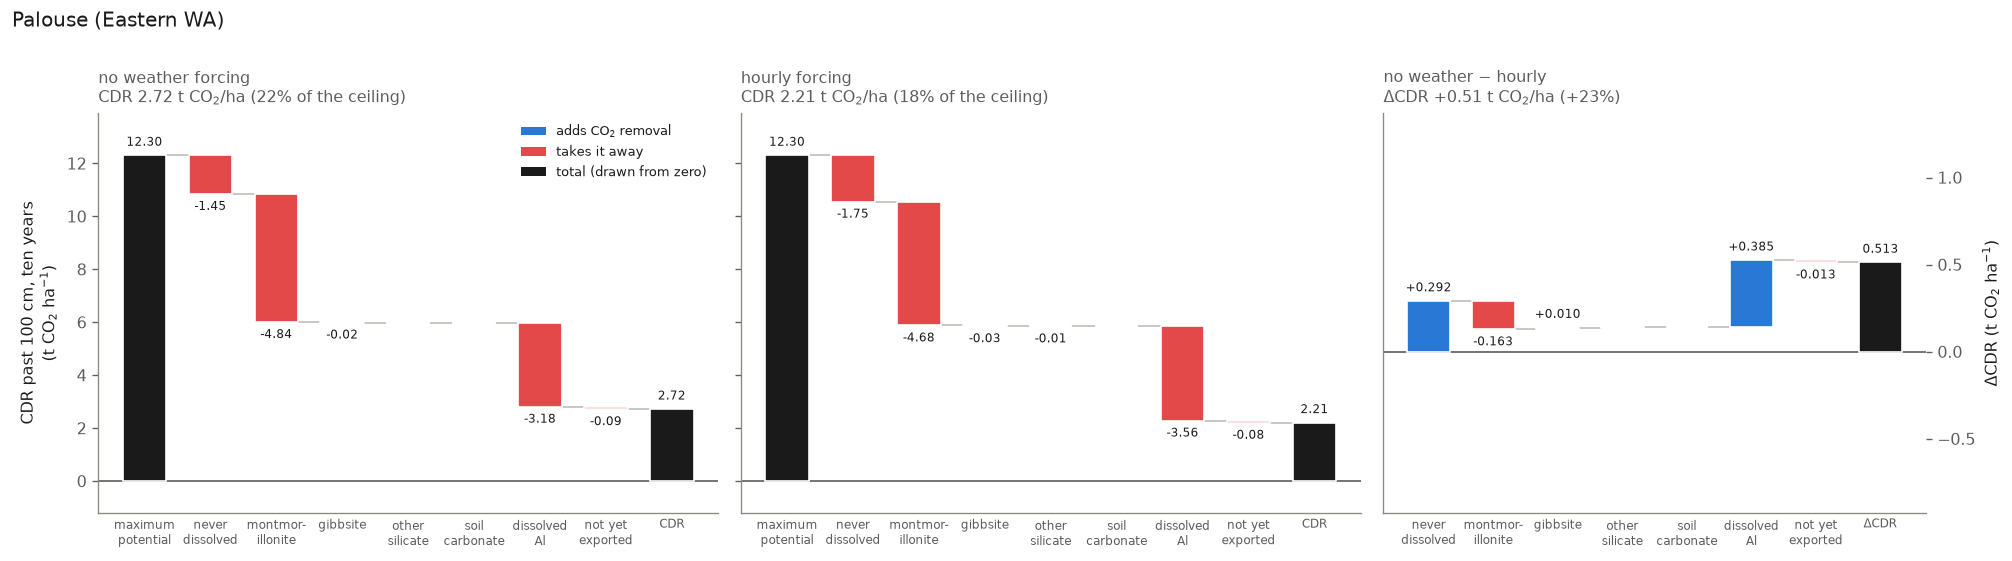

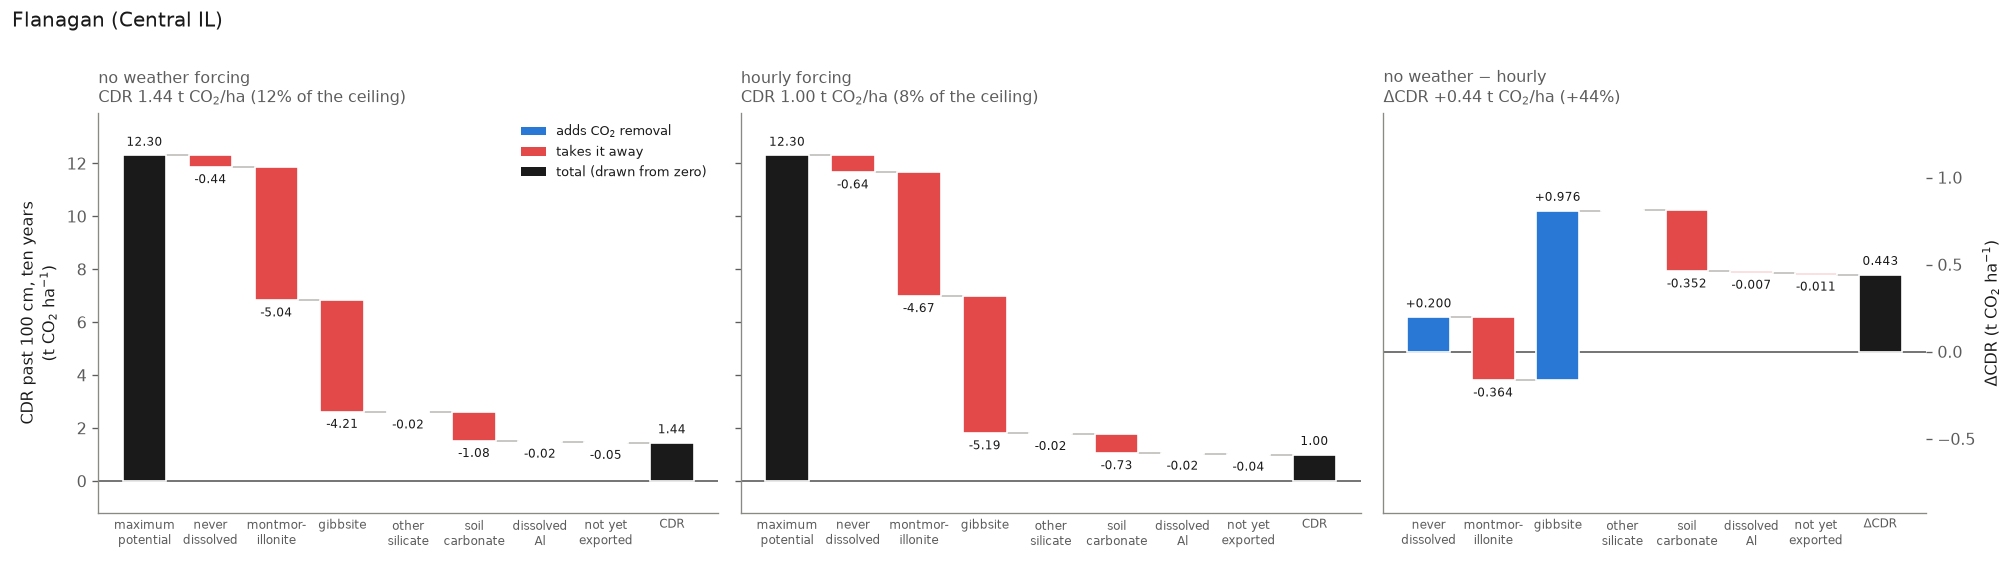

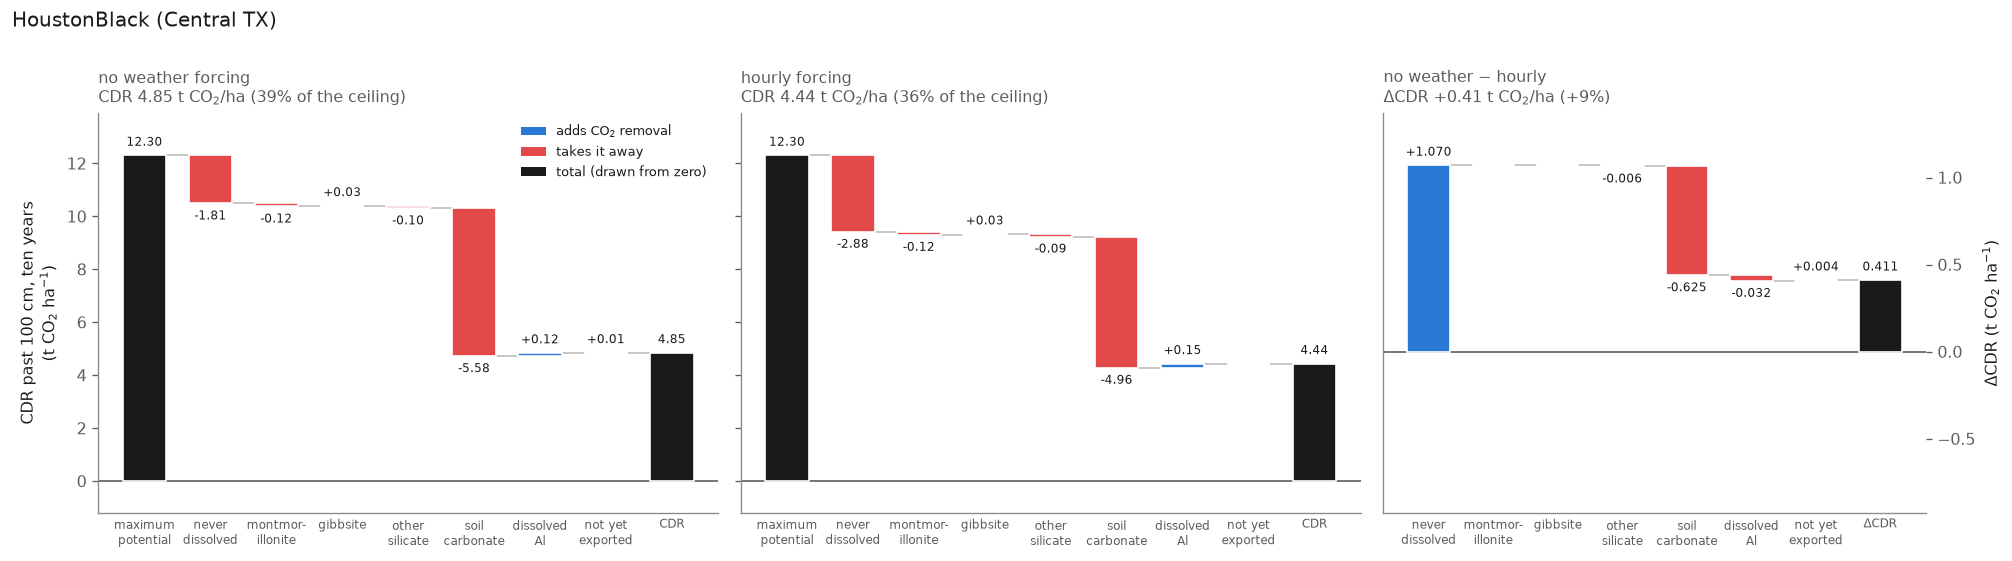

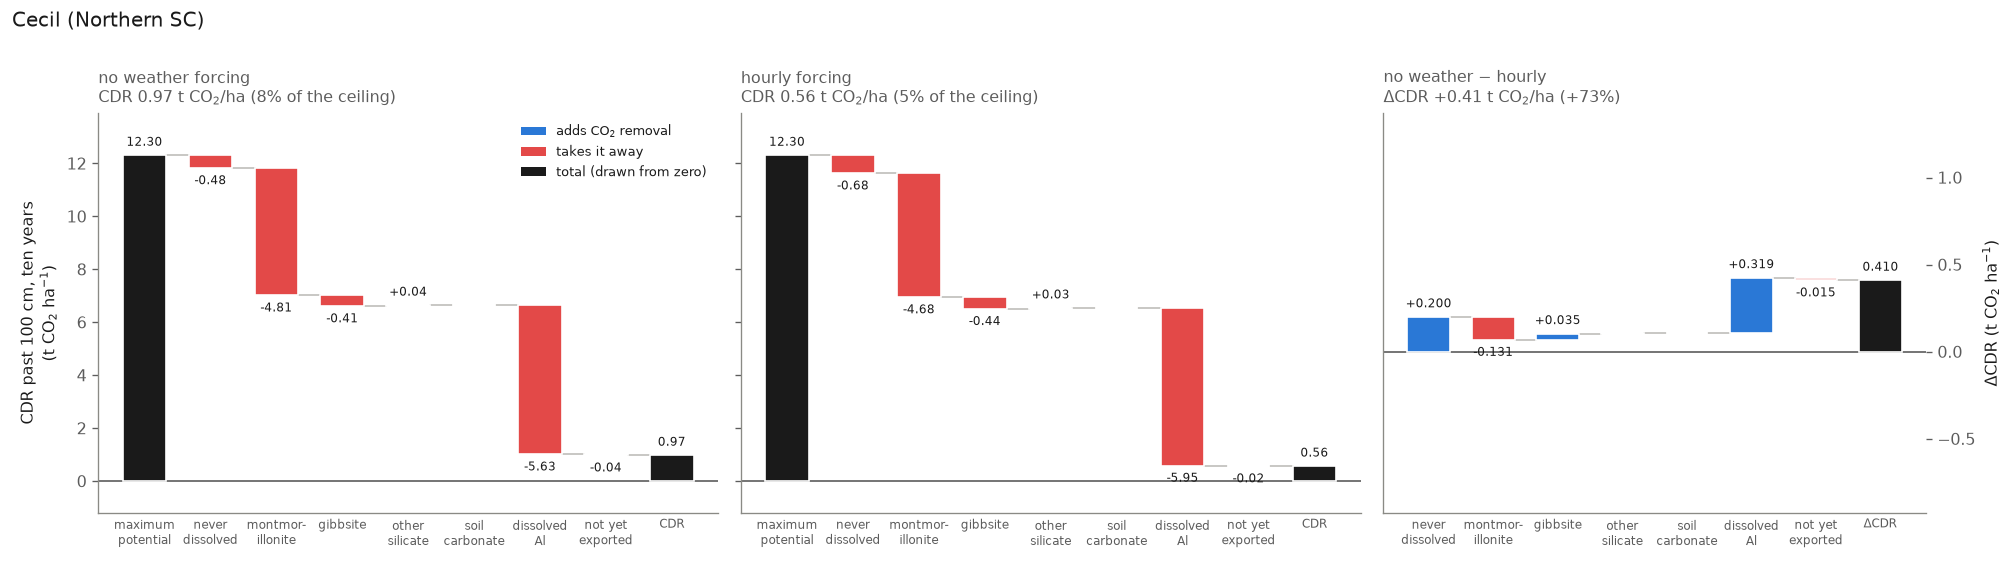

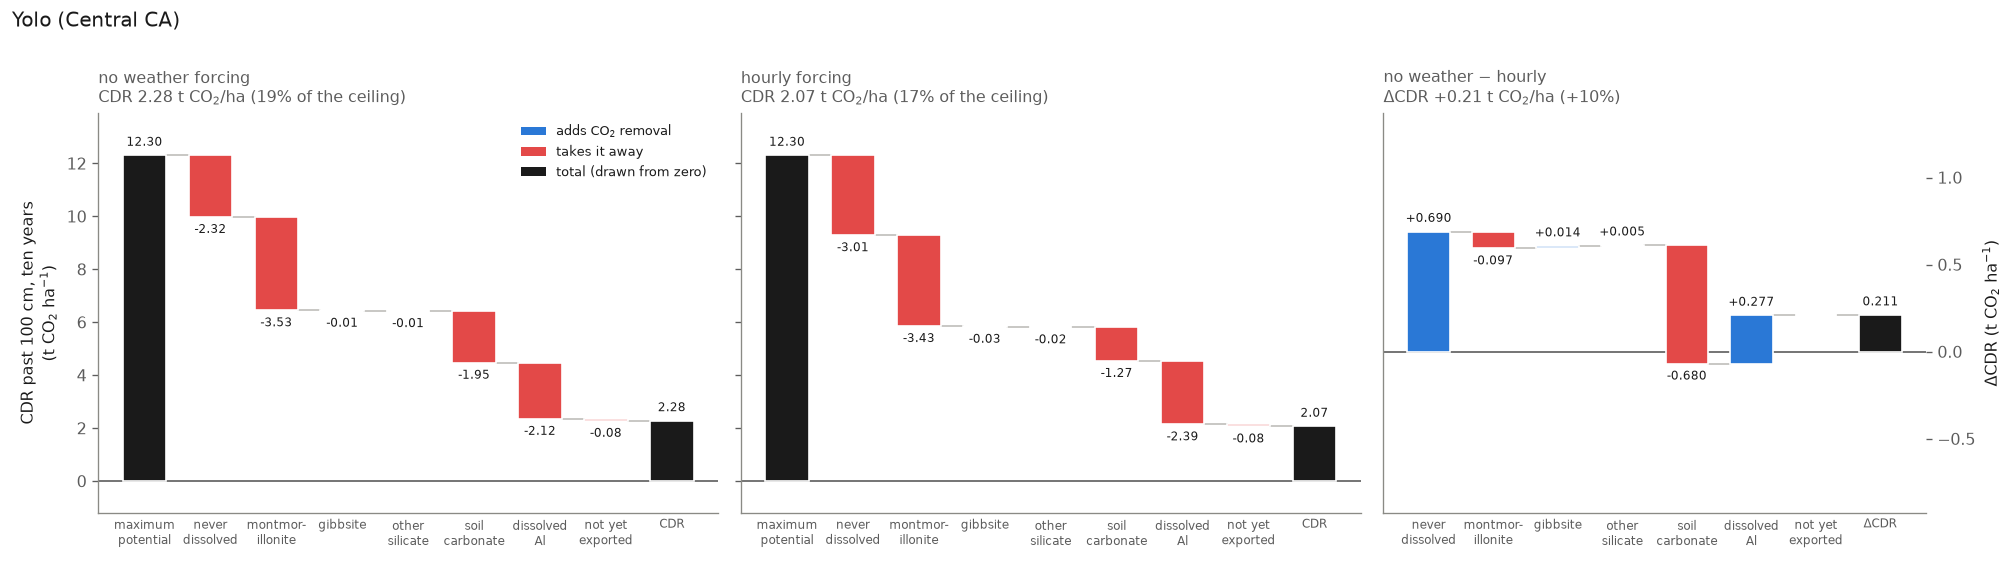

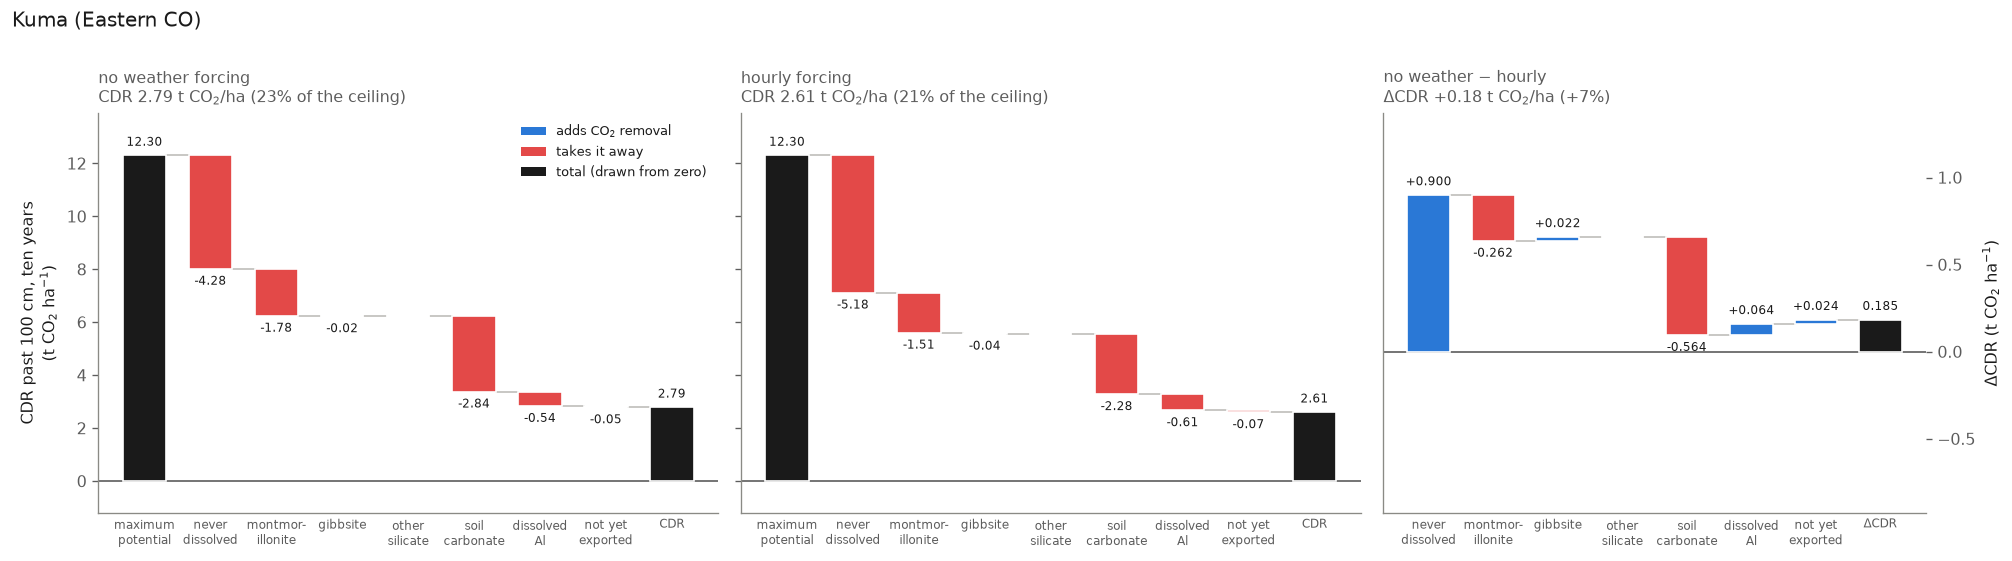

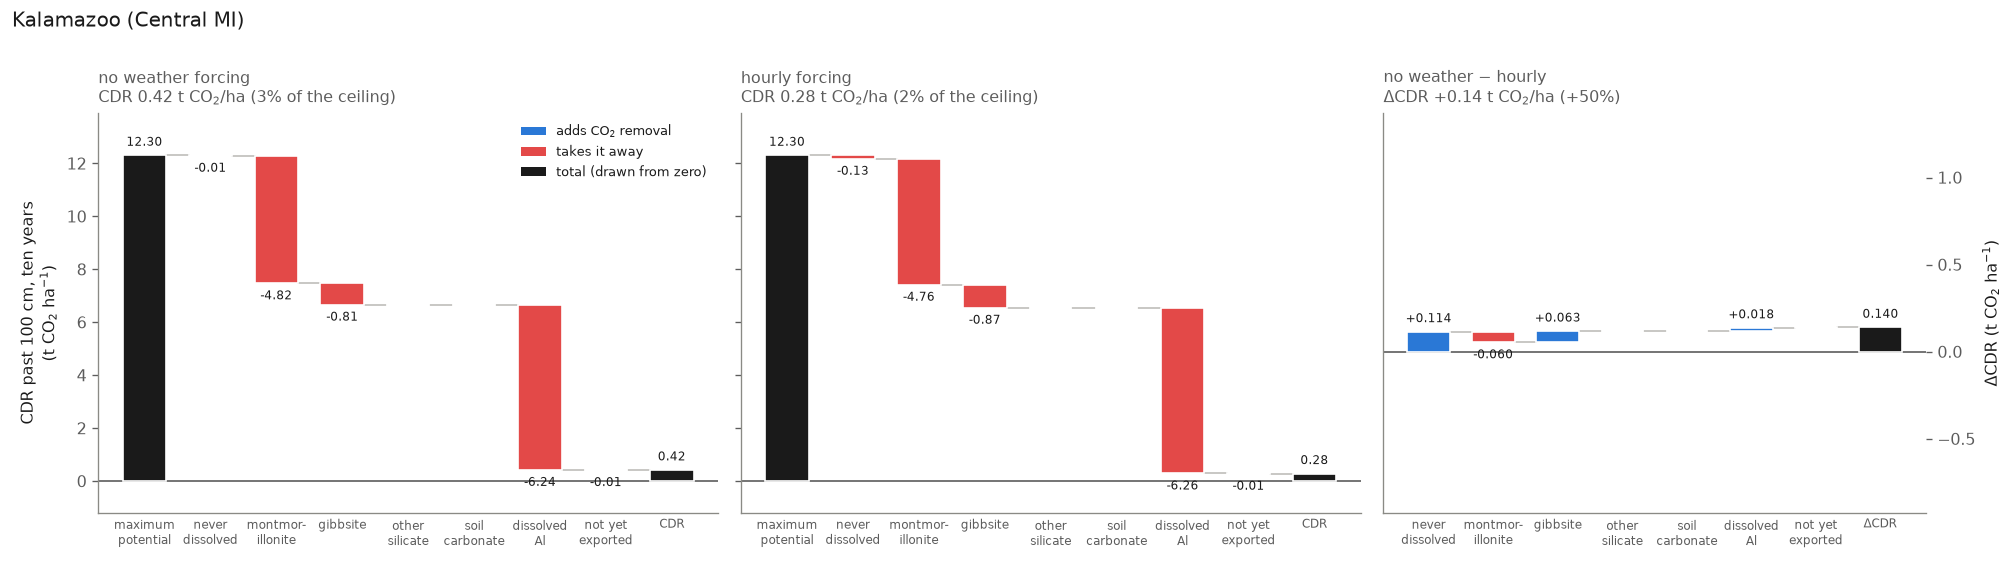

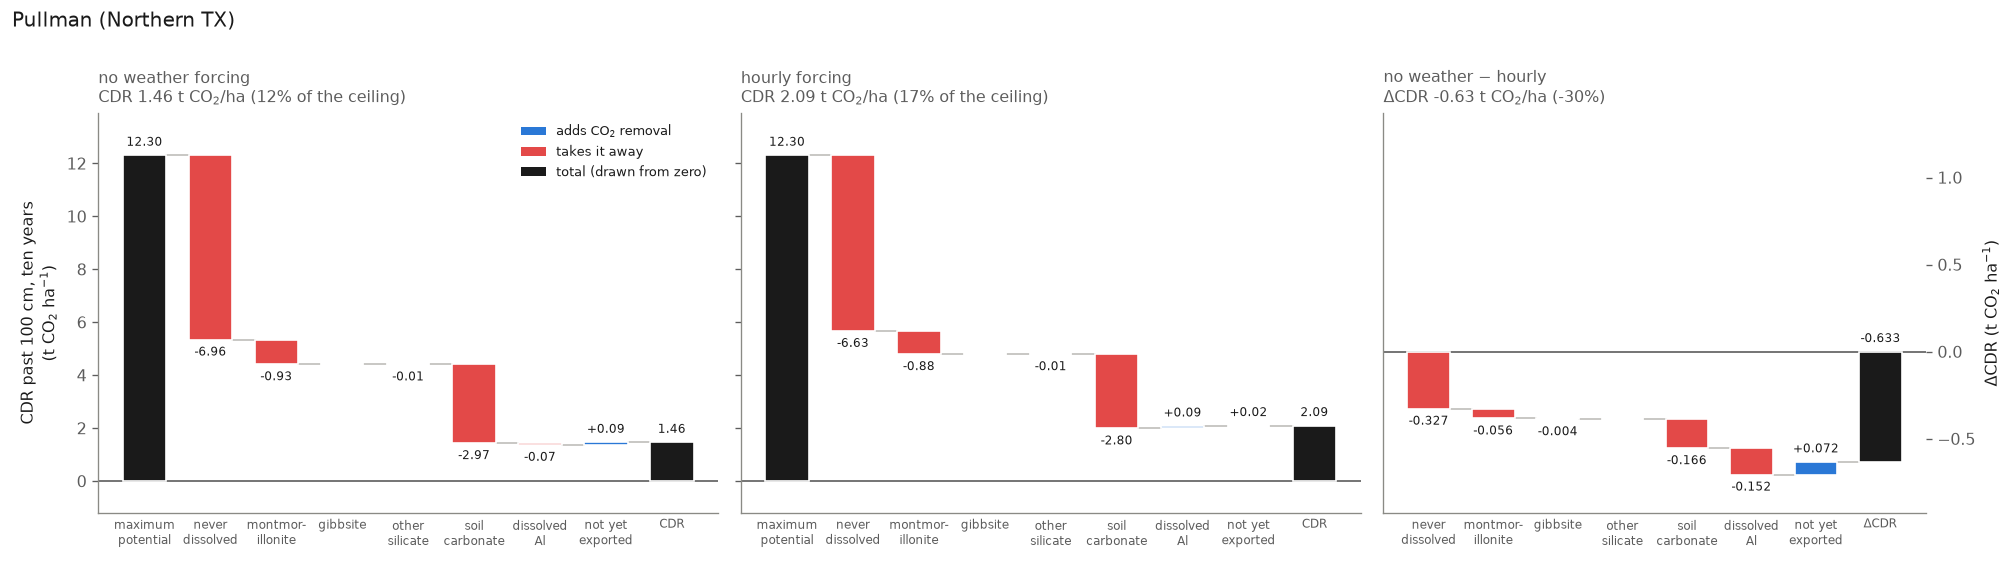

In [7]:
for site in ORDER:
    fig = site_figure(site, ylim=YLIM, dylim=DYLIM)
    if SAVE:
        fig.savefig(Path("figures") / f"cdr_metforcing_{site}_{PLANE}.png",
                    dpi=300, bbox_inches="tight")
    plt.show()

The rows separate into three kinds of answer, and two of them are invisible in the CDR totals.

**Dissolution-driven — HoustonBlack, Kuma, Yolo, Kalamazoo.** The `never dissolved` bar is the tall
one, and the carbonate bar takes some of it back. HoustonBlack gains +1.07 from dissolution and
returns −0.63 to its control's carbonate, netting +0.41. Yolo gains +0.69 and returns −0.68 — almost
exactly cancelling — and ends at +0.21 only because its aluminium term adds +0.28.

**Aluminium-driven — Palouse, Cecil.** These two dissolve nearly all their feedstock under either
forcing, so `never dissolved` can only offer +0.29 and +0.20. The larger term is `dissolved Al`:
+0.39 and +0.32. Wetter soil keeps more of the displaced aluminium in the profile instead of
flushing it past the plane, and aluminium that stays is aluminium whose latent acidity never
subtracted from the export.

**Gibbsite-driven — Flanagan.** Its ΔCDR of +0.44 is within 0.03 of HoustonBlack's, and has nothing
in common with it. Flanagan's gibbsite bar alone is **+0.98**: under coarse forcing it precipitates
0.75 mol/m² less gibbsite than under hourly, and every mole not precipitated is three equivalents of
alkalinity not consumed. Against that it loses −0.36 to clay and −0.35 to its control's carbonate.

**And Pullman, the only loser.** Every other site's `never dissolved` bar points up; Pullman's points
down, −0.33. Its amended zone is CO₂-limited rather than water-limited, so removing the weather
starves it further. Its carbonate (−0.17) and aluminium (−0.15) terms then push the same way, and it
lands at −0.63.

## 4. All eight together

One row per site, sorted by ΔCDR. Terms that add removal stack to the right of zero and terms that
take it away to the left, so the net — marked at the end of the row — is the difference between the
two wings.

What moves CDR when the forcing coarsens, t CO2/ha (no weather - hourly)


,feedstock undissolved,montmorillonite,gibbsite,soil carbonate,dissolved Al,other,$\Delta$CDR,largest driver
Palouse,0.292,-0.163,0.010,0.000,0.385,-0.011,0.513,dissolved Al
Flanagan,0.200,-0.364,0.976,-0.352,-0.007,-0.009,0.443,gibbsite
HoustonBlack,1.070,0.000,-0.001,-0.625,-0.032,-0.002,0.411,feedstock undissolved
Cecil,0.200,-0.131,0.035,0.000,0.319,-0.012,0.410,dissolved Al
Yolo,0.690,-0.097,0.014,-0.680,0.277,0.007,0.211,feedstock undissolved
Kuma,0.900,-0.262,0.022,-0.564,0.064,0.024,0.185,feedstock undissolved
Kalamazoo,0.114,-0.060,0.063,0.000,0.018,0.004,0.140,feedstock undissolved
Pullman,-0.327,-0.056,-0.004,-0.166,-0.152,0.072,-0.633,feedstock undissolved


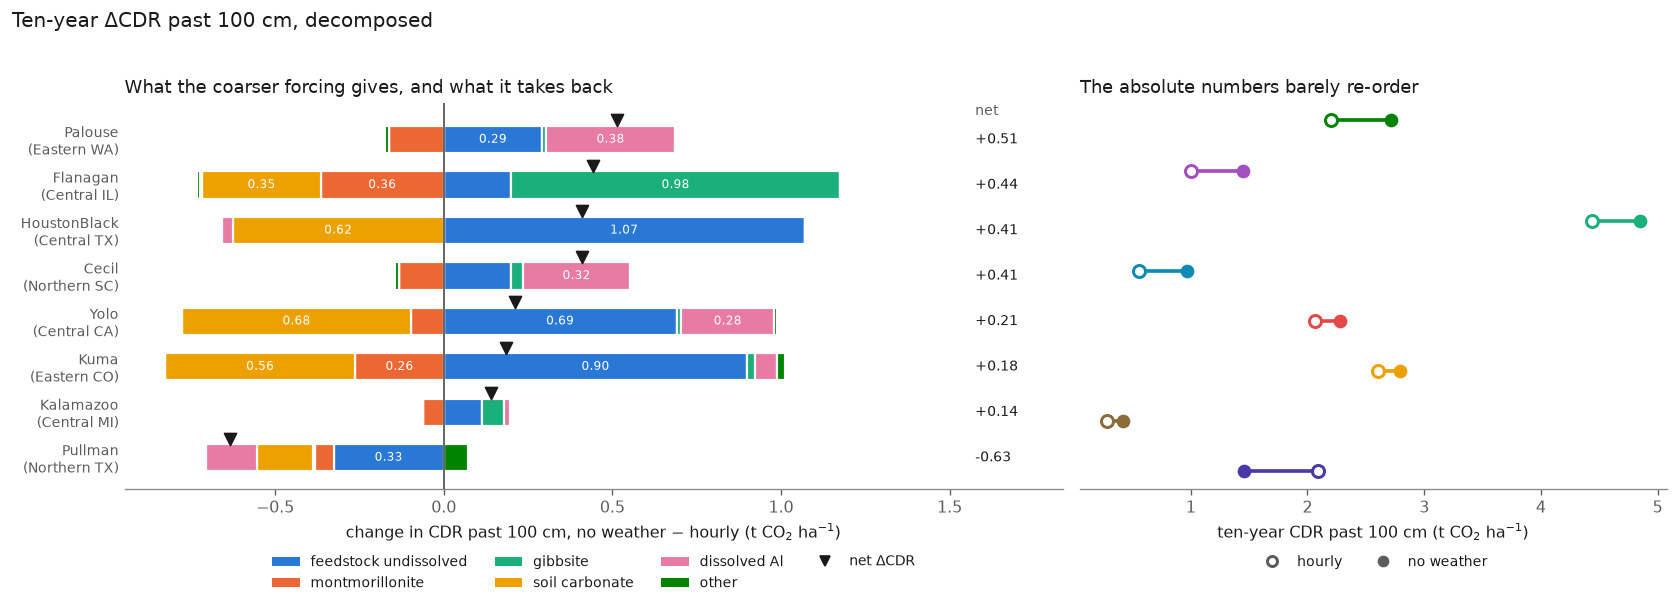

In [8]:
DRIVERS = [("feedstock undissolved", ["never dissolved"]),
           ("montmorillonite",       ["montmorillonite"]),
           ("gibbsite",              ["gibbsite"]),
           ("soil carbonate",        ["soil carbonate"]),
           ("dissolved Al",          ["dissolved Al"]),
           ("other",                 ["other silicate", "not yet exported"])]
DRIVE = pd.DataFrame({name: DIFF[cols].sum(axis=1) for name, cols in DRIVERS})
assert np.allclose(DRIVE.sum(axis=1), DIFF["CDR"]), "the drivers do not sum to dCDR"

show = DRIVE.copy()
show["$\\Delta$CDR"] = DIFF["CDR"]
show["largest driver"] = DRIVE.abs().idxmax(axis=1)
print(f"What moves CDR when the forcing coarsens, t CO2/ha ({LABEL[COARSE]} - {LABEL[REFERENCE]})")
display(show.loc[ORDER].round(3))

fig, axes = plt.subplots(1, 2, figsize=(14.0, 5.0), gridspec_kw={"width_ratios": [1.6, 1]})
y = np.arange(len(ORDER), dtype=float)

# --- left: the drivers, split by sign ----------------------------------------
ax = axes[0]
labelled = set()
for sign in (+1, -1):
    left = np.zeros(len(ORDER))
    for name, _ in DRIVERS:
        w = np.where(np.sign(DRIVE.loc[ORDER, name].to_numpy()) == sign,
                     DRIVE.loc[ORDER, name].to_numpy(), 0.0)
        if not np.any(w):
            continue
        ax.barh(y, w, left=left, height=0.6, color=SINK_COLOR[name], edgecolor="white",
                linewidth=1.3, zorder=3, label=None if name in labelled else name)
        labelled.add(name)
        for yi, wi, li in zip(y, w, left):
            if abs(wi) > 0.22:          # relief rule: these hues need visible labels
                ax.annotate(f"{abs(wi):.2f}", (li + wi / 2, yi), ha="center", va="center",
                            fontsize=7.4, color="white", zorder=5)
        left = left + w
# The net rides just above its row as a pointer rather than sitting on the bar, where it would
# land on top of whichever segment label happens to be at that x.
net = DIFF.loc[ORDER, "CDR"].to_numpy()
ax.scatter(net, y - 0.42, s=52, marker="v", color=INK, zorder=6, clip_on=False)
ax.axvline(0, color=MUTED, lw=1.1, zorder=4)
# The net goes in its own column at the right edge -- printed beside its diamond it lands on top
# of whichever segment label happens to be there.
lo = DRIVE.clip(upper=0).sum(axis=1).min()
hi = DRIVE.clip(lower=0).sum(axis=1).max()
COL = hi + 0.20 * (hi - lo)
ax.set_xlim(lo - 0.06 * (hi - lo), COL + 0.13 * (hi - lo))
for yi, v in zip(y, net):
    ax.annotate(f"{v:+.2f}", (COL, yi), va="center", ha="left", fontsize=8.6, color=INK, zorder=6)
ax.annotate("net", (COL, -0.62), va="center", ha="left", fontsize=8.2, color=MUTED)
ax.set_yticks(y)
ax.set_yticklabels([f"{s}\n({states_per_site[s]})" for s in ORDER], fontsize=8.6)
ax.invert_yaxis()
ax.set_xlabel(f"change in CDR past {PLANE} cm, {LABEL[COARSE]} $-$ {LABEL[REFERENCE]} "
              f"(t CO$_2$ ha$^{{-1}}$)")
ax.set_title("What the coarser forcing gives, and what it takes back", loc="left")
ax.legend(handles=[Patch(facecolor=SINK_COLOR[n], label=n) for n, _ in DRIVERS]
                  + [Line2D([], [], ls="", marker="v", color=INK, label="net $\\Delta$CDR")],
          loc="upper center", bbox_to_anchor=(0.5, -0.14), ncols=4, fontsize=8.2)
ax.spines["left"].set_visible(False)
ax.tick_params(axis="y", length=0)

# --- right: where each site started, and where it ended ----------------------
ax = axes[1]
for yi, s in zip(y, ORDER):
    a, b = LAD[REFERENCE].loc[s, "CDR"], LAD[COARSE].loc[s, "CDR"]
    ax.plot([a, b], [yi, yi], color=SITE_COLOR[s], lw=2.2, zorder=3,
            solid_capstyle="round")
    ax.scatter([a], [yi], s=52, facecolor="white", edgecolor=SITE_COLOR[s], linewidth=1.8,
               zorder=4)
    ax.scatter([b], [yi], s=52, color=SITE_COLOR[s], zorder=4)
ax.set_yticks(y)
ax.set_yticklabels([])
ax.invert_yaxis()
ax.set_xlabel(f"ten-year CDR past {PLANE} cm (t CO$_2$ ha$^{{-1}}$)")
ax.set_title("The absolute numbers barely re-order", loc="left")
ax.legend(handles=[Line2D([], [], ls="", marker="o", mfc="white", mec=MUTED, mew=1.8,
                          label=LABEL[REFERENCE]),
                   Line2D([], [], ls="", marker="o", color=MUTED, label=LABEL[COARSE])],
          loc="upper center", bbox_to_anchor=(0.5, -0.14), ncols=2, fontsize=8.2)
ax.spines["left"].set_visible(False)
ax.tick_params(axis="y", length=0)

fig.suptitle(f"Ten-year $\\Delta$CDR past {PLANE} cm, decomposed",
             y=1.02, x=0.005, ha="left", fontsize=12)
plt.tight_layout()
if SAVE:
    fig.savefig(Path("figures") / f"cdr_metforcing_synthesis_{PLANE}.png",
                dpi=300, bbox_inches="tight")

The right-hand panel is the sanity check on how much any of this matters. Coarsening the forcing
moves every site by 0.14–0.63 t CO₂/ha against absolute CDRs of 0.28–4.85 — between 7% (Kuma) and
73% (Cecil) of a site's own hourly value — and it changes the ranking of the eight sites hardly at
all. **The met-forcing error is a magnitude error, not a re-ordering of which soils work.** The only
places that change hands are fourth and fifth, where Yolo passes Pullman.

What the left panel adds to the sibling notebook is that **the same net change is reached by
different routes**, and the routes matter more than the net if you are trying to decide which
process a model has to get right. HoustonBlack (+0.41) and Flanagan (+0.44) are within 0.03 of each
other and share not one driver. Yolo's +0.21 is a near-cancellation of two terms ten times its size.
A model that got feedstock dissolution exactly right and secondary-mineral kinetics wrong would
reproduce HoustonBlack and miss Flanagan entirely.

## 5. The exchange ledger, under both forcings

The exchange complex has a **fixed** capacity — the deck sets a CEC per zone and MIN3P holds it —
so nothing lands on it without something else coming off. That makes it a strict zero-sum ledger,
and it is worth reading as one, because **which ion comes off is what decides which bar of the
ladder the site loses to**.

Two quantities, both taken from MIN3P's own domain-integrated sorbed inventory (`_o.mss`) and both
differenced against the control, so the rainfall input — identical in the two legs, since drainage
matches to within 0.003 m — cancels exactly:

* **feedstock-derived cations lost from solution**: the Mg²⁺ that leaves the pore water and parks
  on an exchange site. Forsterite is the only Mg source the amendment adds, so in the ERW − CTRL
  difference this is feedstock magnesium by construction.
* **exchange-derived cations gained by solution**: the Al³⁺, Ca²⁺, K⁺, Na⁺ and H⁺ that were
  displaced to make room for it.

They balance to under 0.02 eq/m² at every site, which is the check that the ledger is being read
correctly rather than an assumption imposed on it.

Section 3 showed the Al³⁺ half of this. The ledger shows the other half, which section 3 missed:
at the **carbonate** sites the feedstock displaces **Ca²⁺**, not aluminium — and Ca²⁺ entering the
pore water is exactly what pushes it toward calcite saturation and shuts down the carbonate
weathering the control was doing. The `soil carbonate` bar and the `dissolved Al` bar are the two
exits from the same swap.


The question this section adds is whether the weather moves any of it. It does not.

In [9]:
# Al(3+) wears the `dissolved Al` bar's magenta and Ca(2+) the `soil carbonate` bar's yellow: the
# whole point of this section is that the ion and the bar are the same fact. Na, K and H are
# grouped -- H never exceeds 0.02 eq/m2, and the group keeps the palette inside its validated
# adjacent pairs.
IONS = [("Mg$^{2+}$", ["mg"]), ("Ca$^{2+}$", ["ca"]), ("Al$^{3+}$", ["al"]),
        ("Na$^+$, K$^+$, H$^+$", ["na", "k", "h"])]


def exchange_ledger(TERMS, case):
    """Charge moved on to (+) and off (-) the exchange complex by the amendment. eq/m2, ERW-CTRL."""
    d = TERMS.xs(case, level="case").xs("erw", level="treat") - \
        TERMS.xs(case, level="case").xs("ctrl", level="treat")
    led = pd.DataFrame({name: sum(d[f"sorbeq_{i}"] for i in ions) for name, ions in IONS})
    led["net"] = led.sum(axis=1)
    return led


def magnesium_fate(TERMS, case):
    """Where the feedstock's magnesium is after ten years. mol/m2, ERW-CTRL."""
    d = TERMS.xs(case, level="case").xs("erw", level="treat") - \
        TERMS.xs(case, level="case").xs("ctrl", level="treat")
    released = 2.0 * d["forst-ph"]                       # Mg the forsterite let go
    fate = pd.DataFrame({
        "into secondary clay": -0.34 * d["na-montmor"],  # montmorillonite takes 0.34 Mg per mole
        "onto the exchanger": d["sorb_mg"],
        "exported past the plane": d["exp_mg+2"],
        "in solution above the plane": d["aq_mg+2"]})
    fate.insert(0, "released by the feedstock", released)
    fate["unaccounted"] = released - fate.iloc[:, 1:].sum(axis=1)
    return fate


LEDGER = {case: exchange_ledger(TERMS, case) for case in CASES}
FATE = {case: magnesium_fate(TERMS, case) for case in CASES}
for case in CASES:
    assert LEDGER[case]["net"].abs().max() < 0.05, f"the {case} ledger does not balance"
print(f"both ledgers balance to under "
      f"{max(LEDGER[c]['net'].abs().max() for c in CASES):.3f} eq/m2 -- the CEC is fixed\n")

ION_NAMES = [n for n, _ in IONS]
LED_DIFF = LEDGER[COARSE][ION_NAMES] - LEDGER[REFERENCE][ION_NAMES]
side = pd.concat({LABEL[COARSE]: LEDGER[COARSE][ION_NAMES],
                  LABEL[REFERENCE]: LEDGER[REFERENCE][ION_NAMES],
                  "change": LED_DIFF}, axis=1)
print(f"Charge the amendment moved across the exchange complex, eq/m2 (+ on to it, - off it)")
display(side.loc[ORDER].round(2))
print(f"\nthe largest shift the forcing produces is {LED_DIFF.abs().max().max():.2f} eq/m2, "
      f"against totals of {LEDGER[REFERENCE][ION_NAMES].abs().max().max():.0f}")

held = pd.DataFrame({LABEL[c]: 100 * FATE[c]["onto the exchanger"]
                     / FATE[c]["released by the feedstock"] for c in CASES})
print(f"\nPercentage of the feedstock's magnesium still on the exchanger at ten years")
display(held.loc[ORDER].round(1))

both ledgers balance to under 0.030 eq/m2 -- the CEC is fixed

Charge the amendment moved across the exchange complex, eq/m2 (+ on to it, - off it)


no weather                                             hourly                                             change                                         
              Mg$^{2+}$ Ca$^{2+}$ Al$^{3+}$ Na$^+$, K$^+$, H$^+$ Mg$^{2+}$ Ca$^{2+}$ Al$^{3+}$ Na$^+$, K$^+$, H$^+$ Mg$^{2+}$ Ca$^{2+}$ Al$^{3+}$ Na$^+$, K$^+$, H$^+$
site                                                                                                                                                                  
Palouse           22.16     -6.56    -14.59                -1.02     21.59     -5.66    -14.95                -0.99      0.57     -0.90      0.37                -0.03
Flanagan          25.26     -5.66    -19.01                -0.58     24.99     -3.84    -20.61                -0.54      0.27     -1.82      1.60                -0.04
HoustonBlack      23.82    -23.50     -0.29                -0.02     21.39    -21.26     -0.09                -0.05      2.43     -2.24     -0.20                 0.03
Cecil             24.78     -1.04    -22.63                -1.11     24.51     -0.86    -22.64                -1.01      0.27     -0.18      0.02                -0.11
Yolo              20.36     -9.46    -10.38                -0.55     18.26     -6.94    -10.69                -0.63      2.10     -2.52      0.31                 0.08
Kuma              17.66    -13.06     -4.32                -0.27     15.59    -11.26     -3.99                -0.36      2.07     -1.80     -0.34                 0.09
Kalamazoo          6.98     12.53    -22.93                 3.42      7.03     12.79    -23.14                 3.32     -0.04     -0.27      0.21                 0.10
Pullman           12.47    -10.98     -1.86                 0.38     12.91    -11.56     -1.47                 0.13     -0.43      0.58     -0.39                 0.24


the largest shift the forcing produces is 2.52 eq/m2, against totals of 25

Percentage of the feedstock's magnesium still on the exchanger at ten years


,no weather,hourly
site,,
Palouse,89.9,90.0
Flanagan,93.7,94.3
HoustonBlack,99.9,99.9
Cecil,92.3,92.8
Yolo,89.8,86.5
Kuma,96.9,96.3
Kalamazoo,25.0,25.4
Pullman,102.7,100.1


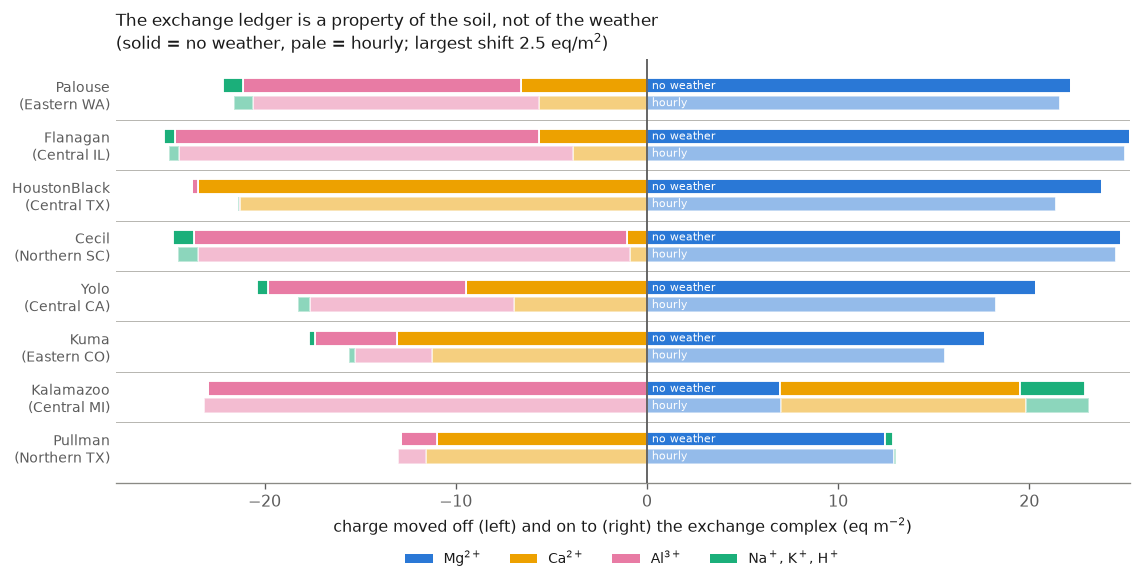

In [10]:
fig, ax = plt.subplots(figsize=(9.6, 5.0))
y = np.arange(len(ORDER), dtype=float)
H = 0.34            # one bar per forcing, stacked vertically within the site's row

for k, case in enumerate(CASES):
    off = (k - 0.5) * H
    led = LEDGER[case]
    labelled = set()
    for sign in (+1, -1):
        left = np.zeros(len(ORDER))
        for name, _ in IONS:
            w = np.where(np.sign(led.loc[ORDER, name].to_numpy()) == sign,
                         led.loc[ORDER, name].to_numpy(), 0.0)
            if not np.any(w):
                continue
            ax.barh(y + off, w, left=left, height=H * 0.86, color=ION_COLOR[name],
                    edgecolor="white", linewidth=1.1, zorder=3,
                    alpha=1.0 if case == COARSE else 0.5,
                    label=None if (name in labelled or case != COARSE) else name)
            labelled.add(name)
            left = left + w
    for yi in y:
        ax.annotate(LABEL[case], (0, yi + off), xytext=(3, 0), textcoords="offset points",
                    va="center", ha="left", fontsize=6.4, color="white", zorder=6)

ax.axvline(0, color=MUTED, lw=1.1, zorder=4)
for yi in y[:-1]:
    ax.axhline(yi + 0.5, color=RULE, lw=0.6, zorder=1)
ax.set_yticks(y)
ax.set_yticklabels([f"{s}\n({states_per_site[s]})" for s in ORDER], fontsize=8.6)
ax.invert_yaxis()
ax.set_xlabel("charge moved off (left) and on to (right) the exchange complex (eq m$^{-2}$)")
ax.set_title(f"The exchange ledger is a property of the soil, not of the weather\n"
             f"(solid = {LABEL[COARSE]}, pale = {LABEL[REFERENCE]}; "
             f"largest shift {LED_DIFF.abs().max().max():.1f} eq/m$^2$)", loc="left", fontsize=10)
# Legend in IONS order, not in the order the bars happened to be drawn.
ax.legend(handles=[Patch(facecolor=ION_COLOR[n], label=n) for n, _ in IONS],
          loc="upper center", bbox_to_anchor=(0.5, -0.13), ncols=4, fontsize=8.2)
ax.spines["left"].set_visible(False)
ax.tick_params(axis="y", length=0)
plt.tight_layout()
if SAVE:
    fig.savefig(Path("figures") / f"cdr_metforcing_exchange_{PLANE}.png",
                dpi=300, bbox_inches="tight")

The two bars in each row are nearly the same bar. Feedstock Mg²⁺ goes on to the exchanger; Al³⁺
comes off at the acid sites and Ca²⁺ at the carbonate sites; and coarsening the forcing shifts any
of it by at most 2.5 equivalents per square metre against totals of 7–25.

That is a useful negative result, and it sharpens what §3 found. **The forcing does not change which
sink a site has — it changes how full that sink is at ten years.** The soil's exchange chemistry sets
the *route* (aluminium at Cecil, Kalamazoo, Flanagan, Palouse and, narrowly, Yolo; calcium at
HoustonBlack, Kuma and Pullman), and the weather only modulates the *rate* along it. So a met-forcing
error is a magnitude error on a mechanism you have already committed to by choosing the soil, which
is why it barely re-orders the sites in §4's right-hand panel.

The small shifts that do occur are not uniformly harmless, and Flanagan is the case in point. Its
gibbsite bar swings +0.98 t CO₂/ha because **0.74 mol/m² less aluminium is displaced above the plane**
under the coarser forcing — and gibbsite precipitation falls by 0.745 mol/m², the same number. The
domain ledger shows the same sign at 0.53 mol/m². Flanagan is the one site where the displaced
aluminium *precipitates* rather than leaving, so each mole costs the full three equivalents and a
small change in the ledger has a large consequence. Everywhere else the same-sized shift disappears
into a term that was already small.

## 6. Why the aluminium term has the sign it does

Section 3 made `dissolved Al` the largest single driver at Palouse (+0.39) and Cecil (+0.32), and
section 5 showed that the exchange ledger itself barely moves. Neither says **why** less aluminium
escapes when the weather is removed, and the obvious story gets it backwards twice over.

The obvious story: coarser forcing dissolves more feedstock, more feedstock raises the pH, a higher
pH strips more aluminium off the exchanger, and the sink gets **stronger**. Only the first clause
survives.

**Inversion 1 — coarsening the forcing lowers the pH.** Alkalinity does rise, by 16% at the plane at
Palouse. But soil pCO$_2$ rises by 26%, and pH $\approx$ pK $+ \log(\mathrm{Alk}/p\mathrm{CO_2})$,
so the profile ends up *more* acid, not less. The extra CO$_2$ is a venting effect and not a
respiration one: `co2_resp` is a fixed-rate irreversible source in every deck, identical under both
forcings. What changes is the escape route. MIN3P's Millington correction makes the effective gas
diffusivity $D_{\rm eff} = D\,S_g^{10/3}\phi^{4/3}$ (`diffcoff.F90`), and $S_g^{10/3}$ is strongly
convex, so a profile that spends part of its time dry vents far better than one held at the same
*mean* wetness. Removing the weather removes the dry episodes and throttles the profile.

**Inversion 2 — at this pH, more alkaline means more dissolved aluminium, not less.** Aluminium is
amphoteric, and above pH 7 nearly all of it travels as the aluminate ion Al(OH)$_4^-$, which carries
four hydroxyls and therefore rises as roughly the fourth power of 1/[H$^+$]. The unamended controls
sit at pH 6.3–6.4, where a litre of water can hold about 3000 aluminium atoms per free Al$^{3+}$;
the amended profiles sit at 7.2–7.4, where it can hold ten million. **The amendment raises the
water's aluminium-carrying capacity by three and a half orders of magnitude** — and once it has,
the 0.05 pH units the trapped CO$_2$ takes back are worth a third of that capacity.

So the chain is

> no weather $\rightarrow$ no dry-down $\rightarrow$ convexly under-vented profile $\rightarrow$
> more trapped CO$_2$ $\rightarrow$ lower pH $\rightarrow$ less Al(OH)$_4^-$ $\rightarrow$ less
> aluminium in the drainage $\rightarrow$ weaker alkalinity sink

and section 5's "less aluminium comes off the exchanger" is the **last** link in it, not the first.
The exchanger is a large, fast aluminium reservoir; what rate-limits the ten-year loss is how much
aluminate the drainage water can carry. Slow the removal and the exchanger simply stays fuller.

In [11]:
# ------------------------------------------------------------------ aluminium speciation
# Exactly the five aluminium species this deck instantiates -- read off the run's own `*_o.gen`
# under "aqueous complexes", not assumed -- with `complex.dbs` log K, charge and Debye-Huckel size.
# Each log K is for  al+3 + n h2o -> Al(OH)n^(3-n) + n h+, so the n = 4 term rises as 10^(4 pH).
#
# The activity model is MIN3P's own (`acoff.F90`): the b-dot equation for a species carrying a size
# in the database, 10^(0.1 I) for a neutral one, with A and B from WATEQ2 at the decks' 20 C
# (`dhconst.F90`). Using Davies instead moves nothing below the third decimal at these ionic
# strengths; what matters is that both forcings are treated identically.
AL_SPECIES = [                      # name, n(h+ released), log K, charge, Debye-Huckel a0
    ("al+3",       0,   0.00,  3, 9.00),
    ("aloh+2",     1,  -5.00,  2, 4.50),
    ("al(oh)2+",   2, -10.34,  1, 4.00),
    ("al(oh)3aq",  3, -15.60,  0, 0.00),
    ("al(oh)4-",   4, -22.20, -1, 4.00),
]


def dh_constants(tempc):
    """MIN3P's A and B, WATEQ2 / Truesdell-Jones. Transcribed from `dhconst.F90`."""
    tempk = tempc + 273.15
    s1 = 374.11 - tempc
    s2 = s1 ** (1.0 / 3.0)
    num = 1.0 + 0.1342489 * s2 - 3.946263e-3 * s1
    den = 3.1975 - 0.3151548 * s2 - 1.203374e-3 * s1 + 7.48908e-13 * s1 ** 4.0
    s3 = np.sqrt(num / den)
    eps = 87.74 - tempc * (tempc * (1.41e-6 * tempc - 9.398e-4) + 0.4008)
    cc = np.sqrt(eps * tempk)
    return 18246e2 * s3 / cc ** 3.0, 50.29 * s3 / cc


A_DH, B_DH = dh_constants(20.0)     # the temperature every deck in this batch is run at


def gamma(I, z, a0):
    """Activity coefficient, MIN3P's `acoff.F90`: b-dot if the species has a size, else neutral."""
    if z == 0:
        return 10.0 ** (0.1 * I)
    s = np.sqrt(I)
    return 10.0 ** (-A_DH * z * z * s / (1.0 + B_DH * a0 * s))


def speciation_factor(pH, I):
    """Total dissolved Al per unit free Al(3+). At pH 7.4 this is ~2e7 and rises as ~10^(4 pH)."""
    aH = 10.0 ** (-np.asarray(pH, dtype=float))
    g3 = gamma(I, 3, 9.00)
    return sum(10.0 ** logK * (g3 / gamma(I, z, a0)) * aH ** (-n)
               for _, n, logK, z, a0 in AL_SPECIES)


def free_al(al_total, pH, I):
    """Split measured total dissolved Al into the free ion the exchanger sees, and everything the
    pH then makes of it. The product of the two is the concentration that actually drains."""
    D = speciation_factor(pH, I)
    return al_total / D, D


# ------------------------------------------------------------------ readers this section adds
def profile_mean(site, case, treat, ext, col):
    """Ten-year mean of one spatial variable, cell by cell, over every snapshot the run wrote."""
    folder = RAW / site / f"{case}_{treat}"
    files = sorted(folder.glob(f"{case}_*.{ext}"), key=lambda p: int(p.stem.split("_")[-1]))
    names, first = read_tecplot(files[0])
    depth, _ = depth_and_dz(first)
    j = names.index(col)
    return depth, np.array([read_tecplot(f)[1][:, j] for f in files]).mean(axis=0)


def venting(site, treat, depth):
    """Time-mean Millington gas-diffusivity factor S_g^(10/3) at one depth, per case.

    MIN3P uses D_eff = D * S^(10/3) * phi^(4/3) (`diffcoff.F90`). Returned alongside is the same
    factor evaluated at the mean saturation only -- the difference between the two is what the
    convexity of the exponent contributes on its own.
    """
    out = {}
    for case in CASES:
        cols, arr = monitor(RAW / site / f"{case}_{treat}", case, "gbp", depth)
        t, sw = arr[:, cols.index("time")], arr[:, cols.index("s_w")]
        w = np.diff(t, prepend=t[0])
        sg = np.clip(1.0 - sw, 1e-6, None)
        mean_sw = float((sw * w).sum() / w.sum())
        out[case] = (float((sg ** (10 / 3) * w).sum() / w.sum()), (1.0 - mean_sw) ** (10 / 3), mean_sw)
    return out


def plane_aluminium(site, case, treat, plane):
    """Drainage-weighted aluminium chemistry in the water that actually crosses the plane.

    The same upstream-weighted interface as `plane_export`: the specific discharge is rebuilt from
    the head difference across the straddling cell pair, and the upstream cell's chemistry is
    carried across. Weighting by downward discharge is the point -- an average over time would
    count water that never left.
    """
    folder = RAW / site / f"{case}_{treat}"
    pcols, p_up = monitor(folder, case, "gbp", plane)
    _, p_dn = monitor(folder, case, "gbp", plane + 1)
    tcols, t_up = monitor(folder, case, "gbt", plane)
    _, t_dn = monitor(folder, case, "gbt", plane + 1)
    mcols, m_up = monitor(folder, case, "gbm", plane)
    _, m_dn = monitor(folder, case, "gbm", plane + 1)
    gcols, g_up = monitor(folder, case, "gbg", plane)

    q = -calc_specific_discharge(np.stack([p_up.T, p_dn.T]), input_file=str(folder / f"{case}.dat"),
                                 ci_a=0, ci_b=1, elev_a=4.00 - plane / 100,
                                 elev_b=3.99 - plane / 100, gbp_cols=pcols)
    upstream = p_up[:, pcols.index("h_w")] > p_dn[:, pcols.index("h_w")]
    carried = lambda names, a, b, c: np.where(upstream, a[1:, names.index(c)], b[1:, names.index(c)])

    al = carried(tcols, t_up, t_dn, "al+3")
    pH = carried(mcols, m_up, m_dn, "pH")
    I = carried(mcols, m_up, m_dn, "ionic strength")
    alk = carried(mcols, m_up, m_dn, "Alk [eq/L]")
    al3, D = free_al(al, pH, I)

    w = np.clip(q, 0.0, None)                      # downward flow only: that is the export
    mean = lambda v: float(np.sum(w * v) / np.sum(w))
    gt = g_up[:, gcols.index("time")]
    return {"soil pCO2 (ppm)": 1e6 * float(np.average(g_up[1:, gcols.index("co2(g)")],
                                                      weights=np.diff(gt))),
            "pH": mean(pH),
            "alkalinity (eq/L)": mean(alk),
            "ionic strength (mol/L)": mean(I),
            "total dissolved Al (mol/L)": mean(al),
            "free Al(3+) (mol/L)": mean(al3),
            "speciation factor Al/Al(3+)": mean(D),
            "ten-year drainage (m)": float(cumtrap(*dedupe(p_up[:, pcols.index("time")], q))[-1])}


WORKED = "Palouse"                    # the site section 3 called the aluminium case
PLANE_AL = pd.DataFrame({(s, c): plane_aluminium(s, c, "erw", PLANE) for s in SITES for c in CASES}).T
PLANE_AL.index.names = ["site", "case"]
print(f"aluminium chemistry of the water crossing {PLANE} cm in the amended column, "
      f"drainage-weighted over ten years")
one = PLANE_AL.xs(WORKED, level="site").T[CASES]
one["change"] = one[COARSE] - one[REFERENCE]
print(f"\n{WORKED}, amended column. Alkalinity is up and the pH is still down: only pCO2 does that.")
display(one.rename(columns=LABEL).map(lambda v: f"{v:.4g}"))

# The venting side of the chain, from the high-resolution flow monitors rather than the snapshots.
vent = {}
for d in (0, 10, 20, 50, PLANE):
    v = venting(WORKED, "erw", d)
    vent[f"{d} cm"] = {
        f"mean s_w, {LABEL[COARSE]}": v[COARSE][2], f"mean s_w, {LABEL[REFERENCE]}": v[REFERENCE][2],
        "D ratio": v[COARSE][0] / v[REFERENCE][0],
        "D ratio at mean s_w": v[COARSE][1] / v[REFERENCE][1],
        f"convexity gain, {LABEL[REFERENCE]}": v[REFERENCE][0] / v[REFERENCE][1]}
print(f"\nEffective gas diffusivity at {WORKED}: the Millington factor S_g^(10/3), time-averaged")
display(pd.DataFrame(vent).T.round(3))
print(f"`D ratio` is what the model sees. `D ratio at mean s_w` is the same comparison made on the\n"
      f"mean saturation alone, and `convexity gain` is how much the {LABEL[REFERENCE]} run's own\n"
      f"wet-dry swing lifts its venting above what its mean wetness would give -- the part of the\n"
      f"difference that no constant forcing can reproduce, however well its mean is chosen.")

aluminium chemistry of the water crossing 100 cm in the amended column, drainage-weighted over ten years

Palouse, amended column. Alkalinity is up and the pH is still down: only pCO2 does that.


case,no weather,hourly,change
soil pCO2 (ppm),3551,2819,732.1
pH,7.342,7.39,-0.04785
alkalinity (eq/L),0.001163,0.001007,0.0001564
ionic strength (mol/L),0.00461,0.004418,0.0001923
total dissolved Al (mol/L),0.0002421,0.0002759,-3.382e-05
free Al(3+) (mol/L),1.647e-11,1.198e-11,4.49e-12
speciation factor Al/Al(3+),1.374e+07,2.152e+07,-7.783e+06
ten-year drainage (m),7.47,7.501,-0.03091



Effective gas diffusivity at Palouse: the Millington factor S_g^(10/3), time-averaged


,"mean s_w, no weather","mean s_w, hourly",D ratio,D ratio at mean s_w,"convexity gain, hourly"
0 cm,0.797,0.782,0.710,0.794,1.117
10 cm,0.799,0.787,0.741,0.820,1.107
20 cm,0.802,0.791,0.764,0.840,1.100
50 cm,0.811,0.804,0.807,0.880,1.090
100 cm,0.793,0.791,0.919,0.957,1.042


`D ratio` is what the model sees. `D ratio at mean s_w` is the same comparison made on the
mean saturation alone, and `convexity gain` is how much the hourly run's own
wet-dry swing lifts its venting above what its mean wetness would give -- the part of the
difference that no constant forcing can reproduce, however well its mean is chosen.


Read the first table downward and the chain is all there. The water leaving the amended column
carries **16% more alkalinity** under the coarser forcing — that is the extra forsterite of §2 — and
is nonetheless **0.048 pH units more acid**, because the pCO$_2$ it is equilibrated with is **26%
higher**. Alkalinity up and pH down at the same time is a signature: nothing but a change in
CO$_2$ can produce it.

The second table says where the CO$_2$ came from. Respiration is identical in the two runs, so the
difference is venting, and the Millington exponent is unforgiving: a profile that is a couple of
percent wetter in the mean is a **third less permeable to gas** in its top 10 cm. Roughly a tenth of
that is not the mean wetness at all but the *variance* — the `convexity gain` column is what the
hourly run's own dry-downs buy it over a steady profile of the same average wetness. **That part is
not recoverable by choosing a better mean**, which is the sharpest statement this notebook can make
about why a long-term average is not a substitute for weather.

The last three rows of the first table are the payoff. Total dissolved aluminium falls by 12%, and
it falls *even though the free aluminium ion rises by 37%*: the speciation factor collapses by 36%,
almost exactly $10^{4\Delta\mathrm{pH}}$. Ten-year aluminium export past the plane goes from
2.05 to 1.82 mol/m², and drainage is the same to 0.03 m, so this is chemistry and not water.

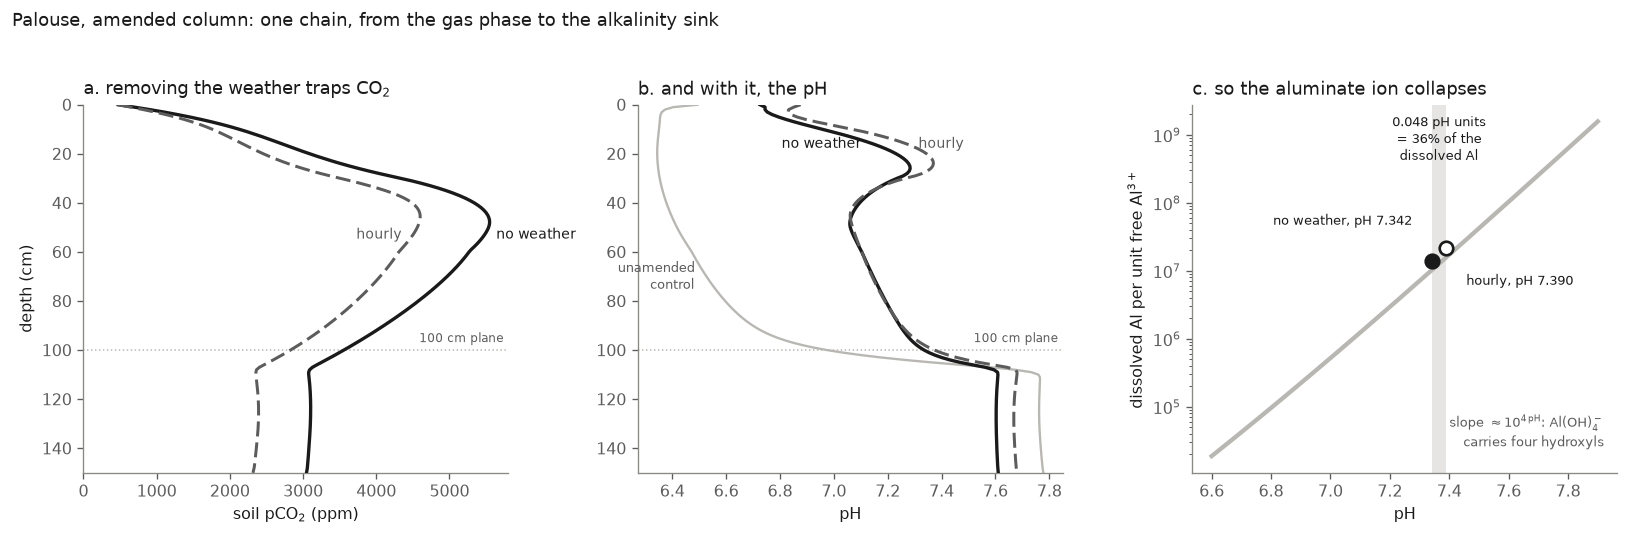

In [12]:
# Two forcings is a two-series contrast, and this notebook's three colour jobs -- polarity, sink
# identity, ion identity -- are all spoken for. Rather than mint a fourth palette that would collide
# with them (`#2a78d6` already means `feedstock undissolved` two sections up), the case is carried by
# line style and weight in neutral ink, with both lines directly labelled. Nothing here is encoded by
# hue, so nothing here can be confused with a bar.
STYLE = {COARSE:    dict(color=INK,   lw=2.0, ls="-"),
         REFERENCE: dict(color=MUTED, lw=1.8, ls=(0, (5, 2)))}
DEEP = PLANE + 50            # show a little below the plane, so the plane is not the edge


def profiles(treat, ext, col):
    """Both cases' ten-year mean profiles over the band this figure draws, shallowest first."""
    out = {}
    for case in CASES:
        d, v = profile_mean(WORKED, case, treat, ext, col)
        m = d <= DEEP
        out[case] = (d[m][::-1], v[m][::-1])
    return out


def label_pair(ax, prof):
    """Name both curves where they are furthest apart, each pushed off its own side."""
    (da, va), (db, vb) = prof[COARSE], prof[REFERENCE]
    top = da >= 15.0                       # keep the label clear of the title and the axis top
    k = int(np.flatnonzero(top)[np.argmax(np.abs(va - vb)[top])])
    for case, (d, v), other in ((COARSE, prof[COARSE], vb[k]), (REFERENCE, prof[REFERENCE], va[k])):
        right = v[k] >= other
        ax.annotate(LABEL[case], (v[k], d[k]), xytext=(7 if right else -7, 0),
                    textcoords="offset points", fontsize=8.2, va="center",
                    ha="left" if right else "right",
                    color=INK if case == COARSE else MUTED, zorder=6)


fig, axes = plt.subplots(1, 3, figsize=(13.6, 4.5))

# --- (a) the trapped CO2 -------------------------------------------------------------------
ax = axes[0]
gas = profiles("erw", "gsg", "co2(g)")
for case, (d, v) in gas.items():
    ax.plot(v * 1e6, d, **STYLE[case], zorder=3)
label_pair(ax, {c: (d, v * 1e6) for c, (d, v) in gas.items()})
ax.set_xlabel("soil pCO$_2$ (ppm)")
ax.set_ylabel("depth (cm)")
ax.set_xlim(0, None)
ax.set_title("a. removing the weather traps CO$_2$", loc="left")

# --- (b) the pH it costs -------------------------------------------------------------------
# The control is drawn once, thin: the two forcings' unamended profiles lie within 0.04 pH of each
# other everywhere, and the point it makes is where the amendment starts from, not how it differs.
ax = axes[1]
ctrl = profiles("ctrl", "gsm", "pH")
dc, vc = ctrl[COARSE][0], 0.5 * (ctrl[COARSE][1] + ctrl[REFERENCE][1])
ax.plot(vc, dc, color=RULE, lw=1.4, zorder=2)
j = int(np.argmin(np.abs(dc - 70.0)))      # where it is furthest from the amended profiles
ax.annotate("unamended\ncontrol", (vc[j], dc[j]), xytext=(-7, 0), textcoords="offset points",
            fontsize=8.0, color=MUTED, ha="right", va="center", zorder=6)
amd = profiles("erw", "gsm", "pH")
for case, (d, v) in amd.items():
    ax.plot(v, d, **STYLE[case], zorder=3)
label_pair(ax, amd)
ax.set_xlabel("pH")
ax.set_title("b. and with it, the pH", loc="left")

for ax in axes[:2]:
    ax.set_ylim(DEEP, 0)
    ax.axhline(PLANE, color=RULE, lw=0.9, ls=":", zorder=1)
    ax.annotate(f"{PLANE} cm plane", (ax.get_xlim()[1], PLANE), xytext=(-3, 3),
                textcoords="offset points", ha="right", va="bottom", fontsize=7.2, color=MUTED)

# --- (c) what a twentieth of a pH unit is worth, in aluminium ------------------------------
# Free Al(3+) here is set by the exchange complex, not by a mineral -- these profiles run about
# three orders of magnitude supersaturated with respect to gibbsite, whose precipitation is
# kinetically shut off. So the curve is monotonic: there is no solubility minimum in this regime,
# and more alkaline always means more dissolved aluminium.
ax = axes[2]
I_REF = float(PLANE_AL.loc[(WORKED, REFERENCE), "ionic strength (mol/L)"])
grid = np.linspace(6.6, 7.9, 400)
ax.semilogy(grid, speciation_factor(grid, I_REF), color=RULE, lw=2.6, zorder=2)

pts = {c: PLANE_AL.loc[(WORKED, c)] for c in CASES}
ax.axvspan(pts[COARSE]["pH"], pts[REFERENCE]["pH"], color=RULE, alpha=0.35, lw=0, zorder=1)
# The curve climbs left to right, so the empty quadrants are above-left of the lower point and
# below-right of the upper one. Both labels go there and neither lands on the ramp.
for case, off, ha in ((COARSE, (-12, 22), "right"), (REFERENCE, (12, -22), "left")):
    r = pts[case]
    ax.scatter([r["pH"]], [r["speciation factor Al/Al(3+)"]], s=66, zorder=5,
               color=INK if case == COARSE else "white", edgecolor=INK, linewidth=1.6)
    ax.annotate(f"{LABEL[case]}, pH {r['pH']:.3f}", (r["pH"], r["speciation factor Al/Al(3+)"]),
                xytext=off, textcoords="offset points", fontsize=8.0, color=INK, ha=ha, zorder=6)
drop = 1.0 - pts[COARSE]["speciation factor Al/Al(3+)"] / pts[REFERENCE]["speciation factor Al/Al(3+)"]
ax.annotate(f"{pts[REFERENCE]['pH'] - pts[COARSE]['pH']:.3f} pH units\n"
            f"= {100 * drop:.0f}% of the\ndissolved Al",
            (0.5 * (pts[COARSE]["pH"] + pts[REFERENCE]["pH"]), ax.get_ylim()[1]),
            xytext=(0, -6), textcoords="offset points", fontsize=8.0, color=INK,
            ha="center", va="top", zorder=6)
ax.annotate("slope $\\approx 10^{4\\,\\mathrm{pH}}$: Al(OH)$_4^-$\ncarries four hydroxyls",
            (0.97, 0.06), xycoords="axes fraction", fontsize=7.8, color=MUTED,
            va="bottom", ha="right")
ax.set_xlabel("pH")
ax.set_ylabel("dissolved Al per unit free Al$^{3+}$")
ax.set_title("c. so the aluminate ion collapses", loc="left")

fig.suptitle(f"{WORKED}, amended column: one chain, from the gas phase to the alkalinity sink",
             x=0.006, ha="left", fontsize=11)
plt.tight_layout(rect=(0, 0, 1, 0.95))
if SAVE:
    fig.savefig(Path("figures") / f"cdr_metforcing_aluminium_{WORKED}_{PLANE}.png",
                dpi=300, bbox_inches="tight")

The water crossing 100 cm, no weather relative to hourly


,$\Delta$pH,Al ratio,free Al(3+) ratio,speciation ratio,log10 speciation,4 $\Delta$pH
site,,,,,,
Palouse,-0.048,0.877,1.375,0.638,-0.195,-0.191
Flanagan,-0.129,0.772,2.867,0.286,-0.544,-0.517
HoustonBlack,-0.156,0.729,1.176,0.234,-0.631,-0.622
Cecil,-0.045,1.059,1.425,0.681,-0.167,-0.179
Yolo,-0.104,0.918,2.865,0.334,-0.476,-0.416
Kuma,-0.036,0.737,1.068,0.686,-0.163,-0.144
Kalamazoo,-0.026,1.071,1.173,0.799,-0.097,-0.103
Pullman,-0.019,0.894,2.570,0.454,-0.343,-0.076


The pH at the plane falls at all 8 sites, and the free aluminium ion rises at all
8 -- the exchanger holding on to what the water can no longer carry. The last two
columns are the mechanism's one falsifiable prediction and its measurement.


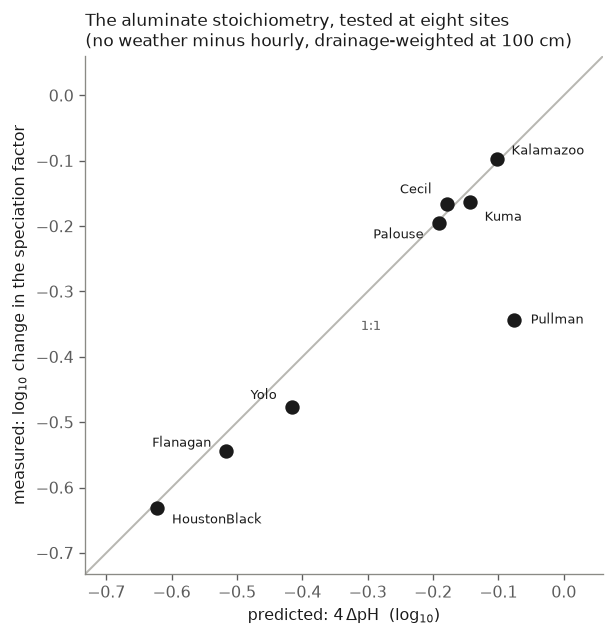

In [13]:
# Every measured aluminium concentration is the product of two factors -- the free ion the exchanger
# holds in equilibrium, and what the pH then makes of it -- so in logs the ratio between the two
# forcings splits cleanly into an exchange term and a speciation term. The test of the mechanism is
# whether the speciation term is the one the aluminate stoichiometry predicts, 10^(4 dpH).
lt, hr = PLANE_AL.xs(COARSE, level="case"), PLANE_AL.xs(REFERENCE, level="case")
CHECK = pd.DataFrame({
    "$\\Delta$pH": lt["pH"] - hr["pH"],
    "Al ratio": lt["total dissolved Al (mol/L)"] / hr["total dissolved Al (mol/L)"],
    "free Al(3+) ratio": lt["free Al(3+) (mol/L)"] / hr["free Al(3+) (mol/L)"],
    "speciation ratio": lt["speciation factor Al/Al(3+)"] / hr["speciation factor Al/Al(3+)"],
})
CHECK["log10 speciation"] = np.log10(CHECK["speciation ratio"])
CHECK["4 $\\Delta$pH"] = 4.0 * CHECK["$\\Delta$pH"]
CHECK = CHECK.loc[ORDER]

print(f"The water crossing {PLANE} cm, {LABEL[COARSE]} relative to {LABEL[REFERENCE]}")
display(CHECK.round(3))
print(f"The pH at the plane falls at all {len(SITES)} sites, and the free aluminium ion rises at all\n"
      f"{len(SITES)} -- the exchanger holding on to what the water can no longer carry. The last two\n"
      f"columns are the mechanism's one falsifiable prediction and its measurement.")

# Eight labelled points need eight placements: Cecil, Kuma and Palouse sit within 0.04 of each
# other and would otherwise print on top of one another. Identity is carried by the label alone --
# no hue is spent here, because the message is that the points lie on the line, not which is which.
NUDGE = {"Palouse": (-9, -7), "Cecil": (-9, 9), "Kuma": (9, -9), "Kalamazoo": (9, 5),
         "Pullman": (10, 0), "Yolo": (-9, 7), "Flanagan": (-9, 5), "HoustonBlack": (9, -7)}

fig, ax = plt.subplots(figsize=(6.6, 5.4))
x, y = CHECK["4 $\\Delta$pH"].to_numpy(), CHECK["log10 speciation"].to_numpy()
span = [min(x.min(), y.min()) * 1.16, 0.06]
ax.plot(span, span, color=RULE, lw=1.2, zorder=2)
ax.annotate("1:1", (0.5 * sum(span), 0.5 * sum(span)), xytext=(10, -3),
            textcoords="offset points", fontsize=7.8, color=MUTED, va="top")
ax.scatter(x, y, s=58, color=INK, zorder=4)
for site, xi, yi in zip(CHECK.index, x, y):
    dx, dy = NUDGE.get(site, (-9, 0))
    ax.annotate(site, (xi, yi), xytext=(dx, dy), textcoords="offset points", fontsize=8.0,
                color=INK, va="center", ha="right" if dx < 0 else "left", zorder=5)
ax.set_xlim(*span)
ax.set_ylim(*span)
ax.set_aspect("equal")
ax.set_xlabel("predicted: $4\\,\\Delta$pH  (log$_{10}$)")
ax.set_ylabel("measured: log$_{10}$ change in the speciation factor")
ax.set_title("The aluminate stoichiometry, tested at eight sites\n"
             f"({LABEL[COARSE]} minus {LABEL[REFERENCE]}, drainage-weighted at {PLANE} cm)",
             loc="left", fontsize=10)
plt.tight_layout()
if SAVE:
    fig.savefig(Path("figures") / f"cdr_metforcing_aluminate_{PLANE}.png", dpi=300,
                bbox_inches="tight")

Seven of the eight sit on the 1:1 line: the change in dissolved-aluminium solubility is the change
in pH, raised to the fourth power, and nothing else. Pullman is the one that does not, and it is the
site that fails to fit in every other section too — its aluminium is small, its amended zone is
CO$_2$-starved rather than CO$_2$-fed, and section 3 already flagged it as the only site where every
term points the wrong way.

Two things follow, and the second is the one that matters outside this notebook.

**The exchanger is not the cause.** Free Al$^{3+}$ rises under the coarser forcing at every site —
the exchange complex ends the run *holding more* aluminium, not less. That is not the exchanger
resisting the amendment; it is the exchanger equilibrating with water that can no longer carry
aluminium away. Section 5's negative result stands and is now explained: the ledger barely moves
because the ledger is not what changed.

**A met-forcing error becomes an aluminium error through two nonlinearities in series.** Gas
venting goes as $S_g^{10/3}$ and aluminate solubility as $10^{4\,\mathrm{pH}}$. Neither exponent is
adjustable — one is MIN3P's Millington correction, the other is the stoichiometry of
Al(OH)$_4^-$ — and between them they turn a few percent of air-filled porosity into the largest
single term in Palouse's $\Delta$CDR. Any model that averages its weather inherits both.

**What would flip the sign.** The curve in panel c is monotonic because free Al3+ here is held
by the exchange complex and not by a mineral: these profiles run some three orders of magnitude
supersaturated with respect to gibbsite, whose precipitation is kinetically shut off (SI $\approx$
+1.2 from the first time step, and 0.02 mol/m² of gibbsite is all that ever forms at Palouse). Put a
mineral in charge of Al$^{3+}$ instead, so that it falls as $10^{-3\,\mathrm{pH}}$, and total
dissolved aluminium acquires a minimum near pH 6 — below which a coarser forcing would mobilise
*more* aluminium, not less, and the `dissolved Al` bar would point the other way. Flanagan is the
site nearest that regime, and it is the one site where the displaced aluminium leaves as gibbsite
rather than in the drainage (§5).

**Caveat.** `dissolved Al` is the closing residual of the alkalinity balance and carries the budget's
numerical error with it (§7 below). The direct check at Palouse is the aluminium mass balance rather
than the residual: 1.82 against 2.05 mol/m² exported past the plane, ERW − CTRL, which at 3 eq per
mole is +0.30 t CO₂/ha of the ladder's +0.39. The sign and most of the magnitude are measured; the
last quarter is residual.

## 7. Why the carbonate term has the sign it does

`soil carbonate` is negative at all five carbonate sites and the second-largest term at three of
them. Section 2 named it — "the extra acid dissolves soil carbonate that the *control* was going to
weather anyway" — but that is only half of it, and the half it names is the one that is easy to get
backwards.

The intuition that fails here is the mirror of §6's. Coarsening the forcing dissolves more feedstock;
more feedstock means a more alkaline profile; a more alkaline profile should weather *less* carbonate,
so the control leg ought to shrink and the term ought to move the other way. It does not, and there
are two separate reasons.

**Inversion 1 — the coarser forcing makes the control more acid, not less.** This is §6's finding
again and it is not specific to aluminium: the same throttled venting that traps CO$_2$ at Palouse
traps it at Kuma, and harder — the surface Millington factor falls further here than it does at
Palouse, and the pCO$_2$ the draining water is equilibrated with is half again as high. The unamended
profile ends up *more* acid at every depth for it, by 0.10 pH units at the reporting plane, and it
dissolves more of its own carbonate.

**Inversion 2 — pH is not the lever at a carbonate front anyway.** The front sits at calcite
saturation in every run and under both forcings. When the mineral buffers the solution, what
dissolves is not set by how acid the water is; it is set by **how much calcium the water can hold at
saturation when it gets there**, which for an open system rises as $p\mathrm{CO_2}^{1/3}$. pH is a
*consequence* of the CO$_2$ that sets that ceiling, not an independent handle on it.

And there is a second leg the sibling notebook could not see. In the **amended** column at Kuma the
calcite is a net *sink*: feedstock Mg loads the exchanger, the displaced Ca$^{2+}$ pushes the pore
water past saturation, and the front precipitates. More trapped CO$_2$ dissolves more feedstock,
which displaces more calcium, which precipitates more calcite. **Both legs of the ERW − CTRL
difference therefore move the same way**, and the term is their sum.

Section 7c then asks the question the ten-year integral cannot answer on its own: whether any of this
survives once you stop averaging — because the hourly run delivers water in pulses, and a pulse
arrives at the front far more undersaturated than anything the steady run produces.

In [14]:
# ------------------------------------------------------------------ readers this section adds
CARB = "Kuma"                       # the carbonate case, as Palouse was the aluminium one
BANDS = [(0, 30), (30, 50), (50, 70), (70, 100), (100, 150), (150, 400)]


def snapshot_times(site, case, treat):
    """The times MIN3P wrote spatial output at, read out of the run's own `*_o.gen` header."""
    txt = (RAW / site / f"{case}_{treat}" / f"{case}_o.gen").read_text()
    blk = txt.split("specified output times for spatial data:")[1].split("output of transient data")[0]
    return np.array([0.0] + [float(x) for x in re.findall(r"T\s*=\s*([0-9.E+-]+)\s*days", blk)])


def mineral_snapshots(site, case, treat, mineral):
    """Per-cell inventory of one mineral at every spatial snapshot, mol/m2. Read once, band later."""
    folder = RAW / site / f"{case}_{treat}"
    files = sorted(folder.glob(f"{case}_*.gsv"), key=lambda p: int(p.stem.split("_")[-1]))
    names, first = read_tecplot(files[0])
    depth, dz = depth_and_dz(first)
    j = names.index(mineral)
    inv = np.array([read_tecplot(f)[1][:, j] * dz / MOLAR_VOLUME[mineral] for f in files])
    return depth, inv


def banded(depth, inv, bands=BANDS):
    """Ten-year change per depth band, mol/m2. Positive = dissolved."""
    return np.array([(inv[0] - inv[-1])[(depth >= lo) & (depth < hi)].sum() for lo, hi in bands])


def interface(site, case, treat, plane):
    """Everything crossing one interface, LEFT UNINTEGRATED.

    The same reconstruction as `plane_export` -- specific discharge from the head difference across
    the straddling cell pair, upstream cell's chemistry carried across. Returned as time series
    rather than as ten-year totals, because §7c's whole question is whether the total hides what the
    individual events are doing. `.gbt`/`.gbm`/`.gbg`/`.gbs` carry a t = 0 row that `.gbp` does not.
    """
    folder = RAW / site / f"{case}_{treat}"
    pcols, p_up = monitor(folder, case, "gbp", plane)
    _, p_dn = monitor(folder, case, "gbp", plane + 1)
    tcols, t_up = monitor(folder, case, "gbt", plane)
    _, t_dn = monitor(folder, case, "gbt", plane + 1)
    mcols, m_up = monitor(folder, case, "gbm", plane)
    _, m_dn = monitor(folder, case, "gbm", plane + 1)
    gcols, g_up = monitor(folder, case, "gbg", plane)

    q = -calc_specific_discharge(np.stack([p_up.T, p_dn.T]), input_file=str(folder / f"{case}.dat"),
                                 ci_a=0, ci_b=1, elev_a=4.00 - plane / 100,
                                 elev_b=3.99 - plane / 100, gbp_cols=pcols)
    t = p_up[:, pcols.index("time")]
    upstream = p_up[:, pcols.index("h_w")] > p_dn[:, pcols.index("h_w")]
    carried = lambda names, a, b, c: np.where(upstream, a[1:, names.index(c)], b[1:, names.index(c)])
    return dict(t=t, dt=np.diff(t, prepend=t[0]), q=q,
                ca=carried(tcols, t_up, t_dn, "ca+2"), pH=carried(mcols, m_up, m_dn, "pH"),
                alk=carried(mcols, m_up, m_dn, "Alk [eq/L]"),
                pco2=g_up[1:, gcols.index("co2(g)")])


def sat_index(site, case, treat, depth, mineral=CARBON_MINERAL):
    """One mineral's saturation index at a monitor depth, full time resolution."""
    cols, arr = monitor(RAW / site / f"{case}_{treat}", case, "gbs", depth)
    return arr[1:, cols.index(mineral)]


def weighted(v, w):
    return float(np.sum(v * w) / np.sum(w))


# ------------------------------------------------------------------ 7a. the two legs
CARB_IF = {(c, tr, pl): interface(CARB, c, tr, pl)
           for c in CASES for tr in ("ctrl", "erw") for pl in (0, 50, PLANE)}


def leg(case, treat):
    """The ten-year carbonate accounting of one column, from the mineral field and the interfaces."""
    r = TERMS.loc[(CARB, case, treat)]
    top, out = CARB_IF[(case, treat, 0)], CARB_IF[(case, treat, PLANE)]
    ca_flux = lambda d: float(np.sum(d["q"] * d["ca"] * 1000 * d["dt"]))
    water = lambda d: float(np.sum(d["q"] * d["dt"]))
    return {"calcite dissolved (mol/m2)": r[CARBON_MINERAL],
            "Ca in across 0.5 cm": ca_flux(top),
            f"Ca out past {PLANE} cm": ca_flux(out),
            "Ca on to the exchanger": r["sorb_ca"],
            f"net drainage past {PLANE} cm (m)": water(out),
            "flux-weighted Ca (mol/L)": weighted(out["ca"], np.clip(out["q"], 0, None) * out["dt"]),
            "flux-weighted pCO2 (ppm)": 1e6 * weighted(out["pco2"], np.clip(out["q"], 0, None) * out["dt"]),
            "flux-weighted pH": weighted(out["pH"], np.clip(out["q"], 0, None) * out["dt"])}


LEGS = pd.DataFrame({(tr, c): leg(c, tr) for tr in ("ctrl", "erw") for c in CASES})
print(f"{CARB}: the carbonate accounting of each column, ten years above {PLANE} cm")
display(LEGS.rename(columns=LABEL).map(lambda v: f"{v:.4g}"))

d_ctrl = LEGS[("ctrl", COARSE)] - LEGS[("ctrl", REFERENCE)]
d_erw = LEGS[("erw", COARSE)] - LEGS[("erw", REFERENCE)]
print(f"\nIn the unamended column the top row is essentially the rainfall input, and the two "
      f"forcings deliver\nthe same calcium: {LEGS[('ctrl', COARSE)]['Ca in across 0.5 cm']:.3f} against "
      f"{LEGS[('ctrl', REFERENCE)]['Ca in across 0.5 cm']:.3f} mol/m2, a difference of "
      f"{abs(d_ctrl['Ca in across 0.5 cm']):.3f}. The hourly run\ncycles far more water through the "
      f"surface -- it rains and then evaporates, where the coarse forcing drips --\nbut the net solute "
      f"it carries in is the same, so what follows is dissolution and not input.")
print(f"control: {d_ctrl['calcite dissolved (mol/m2)']:+.3f} mol/m2 of calcite, "
      f"= {d_ctrl['calcite dissolved (mol/m2)'] * EQ_TO_T_CO2_HA:+.3f} t CO2/ha of the ladder step")
print(f"amended: {d_erw['calcite dissolved (mol/m2)']:+.3f} mol/m2, "
      f"= {d_erw['calcite dissolved (mol/m2)'] * EQ_TO_T_CO2_HA:+.3f} t CO2/ha")
print(f"    sum  {(d_erw - d_ctrl)['calcite dissolved (mol/m2)'] * EQ_TO_T_CO2_HA:+.3f} t CO2/ha, "
      f"against the ladder's {DIFF.loc[CARB, 'soil carbonate']:+.3f}")

# The same venting arithmetic as §6, so the two sections' sites can be compared directly.
for site in (CARB, WORKED):
    v = venting(site, "ctrl", 0)
    print(f"\nSurface gas diffusivity at {site}: the Millington factor falls to "
          f"{v[COARSE][0] / v[REFERENCE][0]:.3f} of its {LABEL[REFERENCE]} value under "
          f"{LABEL[COARSE]} forcing", end="")
print(f" -- {CARB}'s profile is throttled the harder of the two, which is why its CO2 contrast "
      f"is the larger.\n")

# The ceiling test, for the unamended column only. Open-system calcite solubility rises as the cube
# root of pCO2, so if the front is at saturation the calcite it gives up per litre should follow the
# drainage-weighted pCO2 to that power. The amended column is excluded because it precipitates: what
# it does is set by the calcium the exchanger hands it, not by a dissolution ceiling.
per_m3 = LEGS.loc["calcite dissolved (mol/m2)"] / LEGS.loc[f"net drainage past {PLANE} cm (m)"]
a, b = per_m3[("ctrl", COARSE)], per_m3[("ctrl", REFERENCE)]
p, q = LEGS.loc["flux-weighted pCO2 (ppm)", ("ctrl", COARSE)], LEGS.loc["flux-weighted pCO2 (ppm)", ("ctrl", REFERENCE)]
print(f"\nThe ceiling test, unamended column. Calcite given up per m3 of drainage: {a:.4f} against "
      f"{b:.4f} mol/m3,\na ratio of {a / b:.3f}. Drainage-weighted pCO2 rises by {p / q:.3f}, so the "
      f"open-system ceiling predicts {(p / q) ** (1 / 3):.3f}\n-- the measurement and the "
      f"stoichiometry agree to {100 * abs((a / b) / (p / q) ** (1 / 3) - 1):.1f}%.")

Kuma: the carbonate accounting of each column, ten years above 100 cm


ctrl                  erw          
                             no weather    hourly no weather    hourly
calcite dissolved (mol/m2)         4.54       3.8     -1.919    -1.378
Ca in across 0.5 cm               2.434     2.432      2.335     1.954
Ca out past 100 cm                6.507     5.887      6.596     6.306
Ca on to the exchanger             1.22      1.07      -5.31     -4.56
net drainage past 100 cm (m)      4.894     4.731      4.894     4.734
flux-weighted Ca (mol/L)       0.001329  0.001245   0.001348  0.001332
flux-weighted pCO2 (ppm)           2947      1993       2910      2519
flux-weighted pH                  7.643     7.743      7.643      7.68


In the unamended column the top row is essentially the rainfall input, and the two forcings deliver
the same calcium: 2.434 against 2.432 mol/m2, a difference of 0.002. The hourly run
cycles far more water through the surface -- it rains and then evaporates, where the coarse forcing drips --
but the net solute it carries in is the same, so what follows is dissolution and not input.
control: +0.740 mol/m2 of calcite, = +0.326 t CO2/ha of the ladder step
amended: -0.542 mol/m2, = -0.238 t CO2/ha
    sum  -0.564 t CO2/ha, against the ladder's -0.564

Surface gas diffusivity at Kuma: the Millington factor falls to 0.543 of its hourly value under no weather forcing
Surface gas diffusivity at Palouse: the Millington factor falls to 0.711 of its hourly value under no weather forcing -- Kuma's profile is throttled the harder of the two, which is why its CO2 contrast is the larger.


The ceiling test, unamended column. Calcite given up per m3 of drainage: 0.9276 against 0.8031 mol/m3,
a ratio 

Three things in that table.

**The calcium input is not the story.** The hourly run cycles far more water through the surface than
the steady one does — it rains hard and then evaporates, where the coarse forcing simply drips — but
the *net* calcium the rain delivers is the same to a tenth of a percent. Whatever separates the two
runs happens inside the profile.

**The control leg is a ceiling effect, and it is quantitative.** Calcite supplied per cubic metre of
drainage tracks the drainage-weighted pCO$_2$ to the one-third power, which is the open-system
calcite solubility, to better than 2%. That is the tightest statement in this notebook: the front is
at saturation, so what dissolves is what the water can carry, and what the water can carry is set by
the CO$_2$ that the coarser forcing failed to vent.

**The amended leg is an exchange effect**, and it runs through the same extra CO$_2$ by a different
route — more feedstock dissolved, more magnesium on the exchanger, more calcium off it, and a front
that precipitates rather than dissolves. The next cell follows that chain mole for mole.

Kuma: ten-year calcite change by depth band, mol/m2 (positive = dissolved). The feedstock is in the top 30 cm; the calcite starts at 30.


ctrl               erw          ctrl    erw
        calcite present (mol/m2) no weather hourly no weather hourly change change
0–30                       0.000      0.000  0.000     -0.000 -0.000  0.000  0.000
30–50                     70.925      4.361  3.278     -2.065 -1.724  1.083 -0.341
50–70                     80.327      0.078  0.288      0.048  0.192 -0.211 -0.143
70–100                   121.448      0.097  0.228      0.093  0.151 -0.131 -0.058
100–150                  203.504      0.151  0.198      0.152  0.092 -0.047  0.061
150–400                 1949.573     -0.010 -0.057     -0.020 -0.117  0.047  0.097


The amended leg, no weather minus hourly (mol/m2). Each row is the consequence of the one above it.


,change
forsterite dissolved,0.511
Mg released (x2),1.023
Mg on to the exchanger,0.931
Ca off the exchanger,0.750
Ca exported past the plane,0.277
calcite precipitated,0.542


Calcium off the exchanger, less what left in the drainage, is 0.473 mol/m2 -- against 0.542 precipitated.


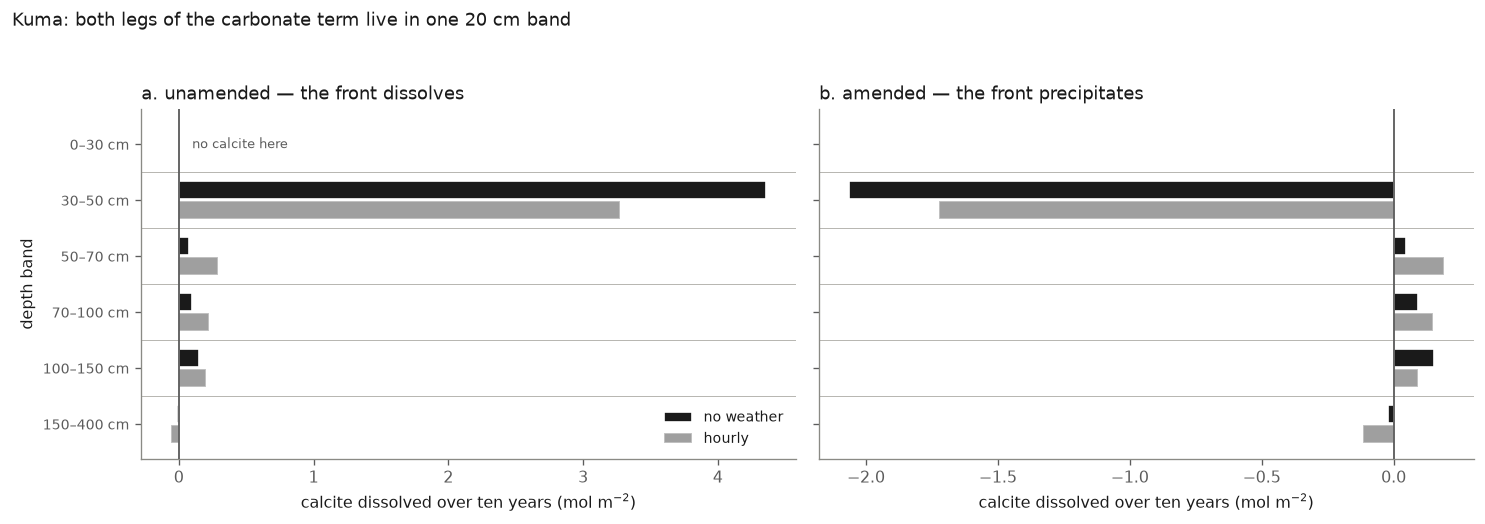

In [15]:
# ------------------------------------------------------------------ 7b. where in the profile
SNAP = {(c, tr): mineral_snapshots(CARB, c, tr, CARBON_MINERAL)
        for c in CASES for tr in ("ctrl", "erw")}
BAND_NAMES = [f"{lo}–{hi}" for lo, hi in BANDS]

band_tbl = pd.DataFrame({(tr, c): banded(*SNAP[(c, tr)]) for tr in ("ctrl", "erw") for c in CASES},
                        index=BAND_NAMES)
for tr in ("ctrl", "erw"):
    band_tbl[(tr, "change")] = band_tbl[(tr, COARSE)] - band_tbl[(tr, REFERENCE)]
depth0, inv0 = SNAP[(REFERENCE, "ctrl")]
band_tbl.insert(0, ("", "calcite present (mol/m2)"),
                [inv0[0][(depth0 >= lo) & (depth0 < hi)].sum() for lo, hi in BANDS])
print(f"{CARB}: ten-year calcite change by depth band, mol/m2 (positive = dissolved). "
      f"The feedstock is in the top 30 cm; the calcite starts at 30.")
display(band_tbl.rename(columns=LABEL).round(3))

# The amended leg's chain, mole for mole. Sorbed inventories are domain-integrated, and at this site
# the exchanger lives in the top 21 cm (`.dat`, sorption zone 3.79-4.00 m), so they are comparable
# with the above-plane mineral terms without further correction.
e_lt, e_hr = TERMS.loc[(CARB, COARSE, "erw")], TERMS.loc[(CARB, REFERENCE, "erw")]
chain = pd.Series({
    "forsterite dissolved": e_lt["forst-ph"] - e_hr["forst-ph"],
    "Mg released (x2)": 2.0 * (e_lt["forst-ph"] - e_hr["forst-ph"]),
    "Mg on to the exchanger": e_lt["sorb_mg"] - e_hr["sorb_mg"],
    "Ca off the exchanger": -(e_lt["sorb_ca"] - e_hr["sorb_ca"]),
    "Ca exported past the plane": e_lt["exp_ca+2"] - e_hr["exp_ca+2"],
    "calcite precipitated": -(e_lt[CARBON_MINERAL] - e_hr[CARBON_MINERAL])})
print(f"\nThe amended leg, {LABEL[COARSE]} minus {LABEL[REFERENCE]} (mol/m2). Each row is the "
      f"consequence of the one above it.")
display(chain.round(3).to_frame("change"))
print(f"Calcium off the exchanger, less what left in the drainage, is "
      f"{chain['Ca off the exchanger'] - chain['Ca exported past the plane']:.3f} mol/m2 -- against "
      f"{chain['calcite precipitated']:.3f} precipitated.")

# ------------------------------------------------------------------ the figure
# Solid for the coarsened forcing and pale for the reference, exactly as the exchange ledger of §5
# draws them, and in neutral ink for the same reason as §6: hue in this notebook means polarity,
# sink or ion, and a fourth meaning would collide with all three.
fig, axes = plt.subplots(1, 2, figsize=(12.4, 4.4), sharey=True)
y = np.arange(len(BANDS), dtype=float)
H = 0.36
for ax, tr, title in zip(axes, ("ctrl", "erw"),
                         ("a. unamended — the front dissolves",
                          "b. amended — the front precipitates")):
    for k, case in enumerate(CASES):
        ax.barh(y + (k - 0.5) * H, band_tbl[(tr, case)], height=H * 0.88, color=INK,
                alpha=1.0 if case == COARSE else 0.42, edgecolor="white", linewidth=1.0,
                zorder=3, label=LABEL[case] if tr == "ctrl" else None)
    ax.axvline(0, color=MUTED, lw=1.1, zorder=4)
    for yi in y[:-1]:
        ax.axhline(yi + 0.5, color=RULE, lw=0.6, zorder=1)
    ax.set_title(title, loc="left")
    ax.set_xlabel("calcite dissolved over ten years (mol m$^{-2}$)")
axes[0].set_yticks(y)
axes[0].set_yticklabels([f"{n} cm" for n in BAND_NAMES], fontsize=8.6)
axes[0].invert_yaxis()
axes[0].set_ylabel("depth band")
axes[0].legend(loc="lower right", fontsize=8.4)
axes[0].annotate("no calcite here", (0, 0), xytext=(8, 0), textcoords="offset points",
                 va="center", ha="left", fontsize=7.6, color=MUTED)
fig.suptitle(f"{CARB}: both legs of the carbonate term live in one 20 cm band", x=0.006,
             ha="left", fontsize=11)
plt.tight_layout(rect=(0, 0, 1, 0.94))
if SAVE:
    fig.savefig(Path("figures") / f"cdr_metforcing_carbonate_{CARB}_{PLANE}.png",
                dpi=300, bbox_inches="tight")

### 7c. Does the averaging hide the events?

Everything above is a ten-year integral, and there is an obvious objection to reading a ten-year
integral as a mechanism. The hourly run does not deliver its water evenly. It delivers it in storms,
and a storm sends a slug of dilute rainwater at the carbonate that is far further from saturation
than anything the steady run ever produces. Undersaturated water dissolves carbonate. So the hourly
run could in principle be doing its weathering in bursts that a mean-based comparison would miss —
and if it were, the ceiling argument above would be the wrong explanation even though the total is
right.

The objection is worth taking seriously, because **the first half of it is true**. The cell below
shows that water arriving at the top of the calcite under hourly forcing ranges from four fifths of
saturation down to three percent of it, where the steady run never leaves a band a quarter that wide.
Every one of those storm litres genuinely carries more dissolution capacity than anything the steady
run produces.

It does not survive contact with the second half. Three tests, at two different time scales:

1. **Nothing leaves the front with capacity to spare.** At full model resolution — tens of thousands
   of records — the water crossing 40 and 50 cm is at calcite saturation essentially always, under
   both forcings. Capacity that is never realised cannot dissolve anything.
2. **Flux-weighting makes the hourly case worse, not better.** Weighting the chemistry by the water
   that actually leaves, rather than by time, lowers the hourly run's calcium *and* its CO$_2$. The
   storm water is the dilute, CO$_2$-poor water: fresh rain displaces the CO$_2$-rich pore gas on its
   way through, so a storm arrives with more capacity and a **lower ceiling**, and the ceiling binds.
3. **The wet periods are less efficient, measured directly.** Reconstructing the calcite inventory
   at all 42 spatial snapshots rather than just the endpoints gives dissolution interval by interval.
   The hourly run's dissolution is genuinely episodic — but its wettest intervals carry about half
   the drainage and well under half the dissolution.

Between them, test 1 covers the storm scale and test 3 the seasonal scale, so the two together close
the gap the integral leaves open.

In [16]:
# ---------------------------------------------- test 1: how far from saturation, and where
FRONT = [20, 30, 40, 50]            # the `.gbs` monitors that bracket the top of the calcite
SI = {(c, d): sat_index(CARB, c, "ctrl", d) for c in CASES for d in FRONT}
# Reported as SI and as Omega = 10^SI, the fraction of saturation, because the objection is about
# how much room the arriving water has left and Omega is that quantity directly.
sat = pd.DataFrame({(f"{d} cm", LABEL[c]): pd.Series({
        "SI median": np.median(SI[(c, d)]), "SI p5": np.percentile(SI[(c, d)], 5),
        "SI min": SI[(c, d)].min(),
        "Omega median": 10.0 ** np.median(SI[(c, d)]),
        "Omega p5": 10.0 ** np.percentile(SI[(c, d)], 5),
        "Omega min": 10.0 ** SI[(c, d)].min(),
        "frac below SI -0.01": np.mean(SI[(c, d)] < -0.01)})
    for d in FRONT for c in CASES}).T
print(f"{CARB} control: calcite saturation index through the front, at full model resolution "
      f"({len(SI[(REFERENCE, 50)]):,} records against {len(SI[(COARSE, 50)]):,})")
display(sat.round(4))
print("At 30 cm -- where the water ARRIVES at the carbonate -- the steady run sits in a narrow band\n"
      "while the hourly run swings from four fifths of saturation down to a few percent of it. At 40\n"
      "and 50 cm, where it LEAVES, both runs are pinned to saturation and stay there: fewer than one\n"
      "record in two thousand falls even 2% short. Capacity that is never realised dissolves nothing.")

# ---------------------------------------------- test 2: weight by water, not by time
print(f"\nChemistry at the interfaces, weighted by time and by the water that actually crosses")
wt = {}
for pl in (50, PLANE):
    for c in CASES:
        d = CARB_IF[(c, "ctrl", pl)]
        f = np.clip(d["q"], 0, None) * d["dt"]
        wt[(f"{pl} cm", LABEL[c])] = {
            "Ca, time-mean": weighted(d["ca"], d["dt"]), "Ca, flux-weighted": weighted(d["ca"], f),
            "pCO2 time-mean (ppm)": 1e6 * weighted(d["pco2"], d["dt"]),
            "pCO2 flux-weighted (ppm)": 1e6 * weighted(d["pco2"], f)}
wt = pd.DataFrame(wt).T
wt["Ca flux/time"] = wt["Ca, flux-weighted"] / wt["Ca, time-mean"]
wt["pCO2 flux/time"] = wt["pCO2 flux-weighted (ppm)"] / wt["pCO2 time-mean (ppm)"]
display(wt.map(lambda v: f"{v:.4g}"))
print(f"The {LABEL[COARSE]} run is steady, so its two weightings agree exactly and its ratios are 1.\n"
      f"Every ratio below 1 in the {LABEL[REFERENCE]} rows is water leaving during an event carrying\n"
      f"LESS than the profile's average -- which is the opposite of the objection.")

# ---------------------------------------------- test 3: interval by interval
TIMES = snapshot_times(CARB, REFERENCE, "ctrl")
EPISODE = {}
for case in CASES:
    depth, inv = SNAP[(case, "ctrl")]
    diss = -np.diff(inv[:, depth <= PLANE].sum(axis=1))          # mol/m2 dissolved per interval
    d = CARB_IF[(case, "ctrl", PLANE)]
    flux = d["q"] * d["dt"]
    drain = np.array([flux[(d["t"] > lo) & (d["t"] <= hi)].sum()
                      for lo, hi in zip(TIMES[:-1], TIMES[1:])])   # m per interval
    EPISODE[case] = (drain, diss)

k = max(1, len(TIMES[:-1]) // 5)
epi = {}
for case, (drain, diss) in EPISODE.items():
    wet = np.argsort(drain)[-k:]
    epi[LABEL[case]] = {
        "CV of dissolution across intervals": diss.std() / diss.mean(),
        "wettest fifth: share of drainage": drain[wet].sum() / drain.sum(),
        "wettest fifth: share of dissolution": diss[wet].sum() / diss.sum(),
        "mol calcite per m3, overall": diss.sum() / drain.sum(),
        "mol calcite per m3, wettest fifth": diss[wet].sum() / drain[wet].sum()}
print(f"\nDissolution and drainage over the {len(TIMES) - 1} intervals between spatial snapshots "
      f"({np.diff(TIMES)[0]:.0f} days each), control leg")
display(pd.DataFrame(epi).round(3))

Kuma control: calcite saturation index through the front, at full model resolution (44,867 records against 3,674)


SI median   SI p5  SI min  Omega median  Omega p5  Omega min  frac below SI -0.01
20 cm no weather    -2.6042 -2.6317 -2.6344        0.0025    0.0023     0.0023               1.0000
      hourly        -2.1134 -2.7098 -2.9897        0.0077    0.0020     0.0010               1.0000
30 cm no weather    -0.6099 -0.6269 -0.6317        0.2455    0.2361     0.2335               1.0000
      hourly        -0.2746 -0.9400 -1.5026        0.5314    0.1148     0.0314               1.0000
40 cm no weather    -0.0000 -0.0000 -0.0000        0.9999    0.9999     0.9999               0.0000
      hourly        -0.0001 -0.0007 -0.0318        0.9999    0.9984     0.9294               0.0003
50 cm no weather    -0.0000 -0.0000 -0.0000        1.0000    1.0000     0.9999               0.0000
      hourly        -0.0000 -0.0003 -0.0197        0.9999    0.9994     0.9557               0.0004

At 30 cm -- where the water ARRIVES at the carbonate -- the steady run sits in a narrow band
while the hourly run swings from four fifths of saturation down to a few percent of it. At 40
and 50 cm, where it LEAVES, both runs are pinned to saturation and stay there: fewer than one
record in two thousand falls even 2% short. Capacity that is never realised dissolves nothing.

Chemistry at the interfaces, weighted by time and by the water that actually crosses


Ca, time-mean Ca, flux-weighted pCO2 time-mean (ppm) pCO2 flux-weighted (ppm) Ca flux/time pCO2 flux/time
50 cm  no weather      0.001332          0.001332                 2425                     2425            1              1
       hourly          0.001234          0.001176                 1585                     1283       0.9532         0.8094
100 cm no weather      0.001329          0.001329                 2947                     2947            1              1
       hourly          0.001277          0.001245                 2016                     1993       0.9746         0.9883

The no weather run is steady, so its two weightings agree exactly and its ratios are 1.
Every ratio below 1 in the hourly rows is water leaving during an event carrying
LESS than the profile's average -- which is the opposite of the objection.

Dissolution and drainage over the 41 intervals between spatial snapshots (90 days each), control leg


,no weather,hourly
CV of dissolution across intervals,0.070,0.625
wettest fifth: share of drainage,0.197,0.457
wettest fifth: share of dissolution,0.197,0.365
"mol calcite per m3, overall",0.928,0.803
"mol calcite per m3, wettest fifth",0.925,0.641


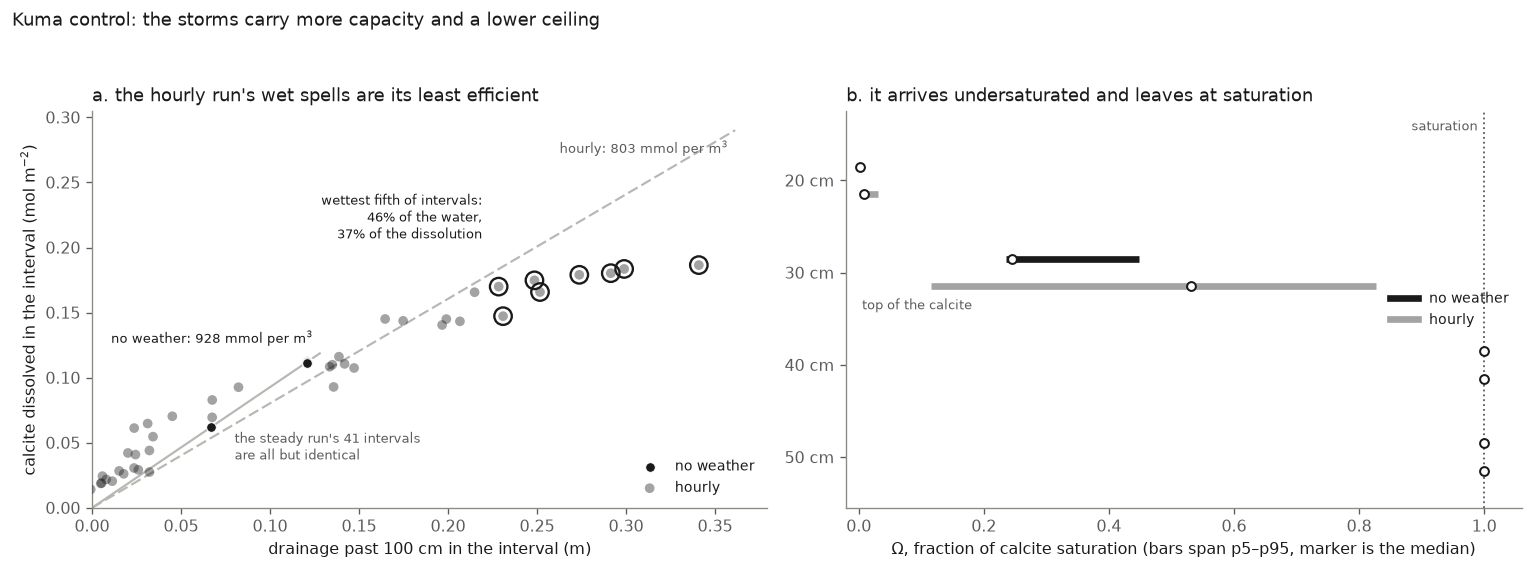

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12.8, 4.8))

# --- (a) a wet interval is a less efficient interval -----------------------------------------
# One point per interval between spatial snapshots. The ray through the origin is the run's own
# ten-year average, so a point below its ray is an interval that dissolved less per litre than the
# run managed on average. If storms did extra work, the hourly cloud would bend UP at the right.
ax = axes[0]
for case in CASES:
    drain, diss = EPISODE[case]
    solid = case == COARSE
    ax.scatter(drain, diss, s=34, color=INK, alpha=1.0 if solid else 0.40,
               edgecolor="white" if solid else "none", linewidth=0.6, zorder=4,
               label=LABEL[case])
    x = np.array([0.0, drain.max() * 1.06])
    ax.plot(x, x * diss.sum() / drain.sum(), color=RULE, lw=1.3, ls="-" if solid else (0, (5, 2)),
            zorder=2)
    ax.annotate(f"{LABEL[case]}: {1000 * diss.sum() / drain.sum():.0f} mmol per m$^3$",
                (x[1], x[1] * diss.sum() / drain.sum()), xytext=(-4, 6 if solid else -14),
                textcoords="offset points", ha="right", fontsize=8.0,
                color=INK if solid else MUTED, zorder=6)
drain, diss = EPISODE[REFERENCE]
wet = np.argsort(drain)[-k:]
ax.scatter(drain[wet], diss[wet], s=110, facecolor="none", edgecolor=INK, linewidth=1.4, zorder=5)
ax.annotate(f"wettest fifth of intervals:\n{100 * drain[wet].sum() / drain.sum():.0f}% of the water,"
            f"\n{100 * diss[wet].sum() / diss.sum():.0f}% of the dissolution",
            (drain[wet].min(), diss[wet].max()), xytext=(-10, 16), textcoords="offset points",
            ha="right", fontsize=8.0, color=INK, zorder=6)
ax.set_xlim(0, None)
ax.set_ylim(0, None)
ax.set_xlabel(f"drainage past {PLANE} cm in the interval (m)")
ax.set_ylabel("calcite dissolved in the interval (mol m$^{-2}$)")
ax.annotate("the steady run's 41 intervals\nare all but identical", (0.067, 0.062),
            xytext=(14, -2), textcoords="offset points", fontsize=7.8, color=MUTED,
            ha="left", va="top")
ax.set_title("a. the hourly run's wet spells are its least efficient", loc="left")
ax.legend(loc="lower right", fontsize=8.4)

# --- (b) arriving undersaturated, leaving saturated ------------------------------------------
# Plotted as Omega = 10^SI, the fraction of saturation, because that is the quantity the objection is
# actually about -- how much room the arriving water has left -- and because SI spans three decades
# through this front while Omega spans nought to one and can be read off a linear axis.
ax = axes[1]
yy = np.arange(len(FRONT), dtype=float)
for j, case in enumerate(CASES):
    off = (j - 0.5) * 0.30
    for i, d in enumerate(FRONT):
        om = 10.0 ** SI[(case, d)]
        lo, hi = np.percentile(om, 5), np.percentile(om, 95)
        ax.plot([lo, hi], [yy[i] + off] * 2, color=INK, lw=4.0,
                alpha=1.0 if case == COARSE else 0.40, solid_capstyle="butt", zorder=3)
        ax.scatter([np.median(om)], [yy[i] + off], s=28, color="white", edgecolor=INK,
                   linewidth=1.2, zorder=5)
    ax.plot([], [], color=INK, lw=4.0, alpha=1.0 if case == COARSE else 0.40, label=LABEL[case])
ax.axvline(1.0, color=MUTED, lw=1.1, ls=":", zorder=2)
ax.annotate("saturation", (1.0, -0.58), xytext=(-4, 0), textcoords="offset points",
            ha="right", va="center", fontsize=7.8, color=MUTED)
ax.set_xlim(-0.02, 1.06)
ax.set_yticks(yy)
ax.set_yticklabels([f"{d} cm" for d in FRONT])
ax.invert_yaxis()
ax.set_xlabel("$\\Omega$, fraction of calcite saturation (bars span p5–p95, marker is the median)")
ax.set_title("b. it arrives undersaturated and leaves at saturation", loc="left")
ax.legend(loc="center right", fontsize=8.4)
ax.annotate("top of the calcite", (0.0, 1.0), xytext=(2, -22), textcoords="offset points",
            fontsize=7.8, color=MUTED, ha="left")
ax.set_ylim(len(FRONT) - 0.45, -0.75)

fig.suptitle(f"{CARB} control: the storms carry more capacity and a lower ceiling", x=0.006,
             ha="left", fontsize=11)
plt.tight_layout(rect=(0, 0, 1, 0.94))
if SAVE:
    fig.savefig(Path("figures") / f"cdr_metforcing_episodicity_{CARB}_{PLANE}.png",
                dpi=300, bbox_inches="tight")

The objection is answered, and answering it sharpens the mechanism rather than just defending it.

**What the storms do.** They arrive with real dissolution capacity — at the extreme, a slug at three
percent of saturation where the steady run's water never falls below about a quarter. And they spend
it: the hourly run's dissolution is genuinely episodic, with a coefficient of variation across
intervals an order of magnitude above the steady run's.

**What they cannot do.** They cannot dissolve past the ceiling, and their own ceiling is the lowest
in the profile. Fresh rain displaces the CO$_2$-rich soil gas on the way down, so the drainage-weighted
pCO$_2$ at the front is well below even the hourly run's own time-mean — a storm arrives with more
capacity *and* less CO$_2$ to convert it with. Water leaves the front at saturation regardless, so the
capacity that arrived unused departs unused. Per cubic metre, the wettest fifth of intervals is the
hourly run's least productive.

**What they do instead is move the front.** The one place the episodic runs come out ahead is
**depth**: between 50 and 150 cm the hourly control dissolves two to three times more calcite than the
steady one, because pulses push undersaturated water past the top of the front before it can
equilibrate. Above the reporting plane the front-band deficit outweighs that deep gain and the sign
of the term is unchanged — but this is a ten-year run with one application, and a front-position
difference is exactly the kind of thing that compounds. **A coarsened forcing does not just get the
magnitude of carbonate weathering wrong; it puts it in the wrong place**, and nothing in the ten-year
CDR total shows that.

**Caveats.** Two, both about what the output can and cannot resolve.

1. There is no `.gbd` rate monitor inside the calcite at this site — the only one sits at 20 cm,
   above the carbonate — so there is no direct dissolution-*rate* time series at the front. Test 3
   reconstructs it from the mineral field at the snapshot cadence, which resolves seasons rather than
   storms; test 1 covers the storm scale instead, at full model resolution. A rate monitor in the
   30–50 cm band would settle the timing outright and is worth adding to any re-run.
2. The interval drainage of test 3 is measured at the reporting plane and the dissolution above it,
   so the two are separated by a transit time the test does not correct for. At these fluxes that
   lag is short against a snapshot interval, but it is the reason the test is quoted as quintiles
   rather than interval by interval.

## 8. Pullman, the site that goes the other way

Pullman is the only site in the batch that **loses** CDR when the weather is removed, and it has been
the exception in every section: the only negative `never dissolved` bar in §2, the only site off the
1:1 line in §6, and the only carbonate site whose amended column does not behave like Kuma's in §7.
It is worth one section, because the explanation turns out not to need anything new.

**All three of Pullman's terms are §6 and §7's mechanism.** What is different is a sign, and the sign
belongs to the soil rather than to the weather. Everywhere else the amended column is still a net
CO$_2$ **source** — respiration makes more CO$_2$ than the feedstock consumes — so throttling the
venting bottles CO$_2$ up and the feedstock gets more of it. At Pullman the amended column is a net
CO$_2$ **sink**. It draws its carbon down out of the atmosphere, and throttling the venting cuts off
the supply.

That single inversion carries the site:

* **`never dissolved`, −0.33.** The amended zone runs at a tenth to a third of atmospheric CO$_2$ and
  imports the difference. Removing the weather throttles the import, and 0.19 mol/m² less feedstock
  dissolves.
* **`soil carbonate`, −0.17.** Almost all of this is the *control* leg, which is an ordinary
  CO$_2$-emitting soil and behaves exactly like Kuma's in §7 — more trapped CO$_2$, a higher
  saturation ceiling, more of its own carbonate gone.
* **`dissolved Al`, −0.15.** Also the control leg, and it is §6's aluminate mechanism. Testing it on
  the *amended* leg is what made Pullman the outlier in §6's figure.

So the same profile hosts both signs at once: an unamended column that behaves like every other site
and an amended column that behaves like no other. The three terms are the two columns pulling apart,
and the ladder subtracts them, so all three losses add.

In [18]:
# ------------------------------------------------------------------ readers this section adds
PULL = "Pullman"
D_GAS = 1.8e-5 * 86400.0            # m2/d, the decks' 'gaseous phase diffusion coefficient'
MOL_PER_M3_PER_ATM = 101325.0 / (8.314 * 293.15)          # ideal gas at the decks' 20 C
RESP_MOLAR_VOLUME = 1.000 / 1000.000 * 1e-6               # `co2_resp` gfw and rho, from mineral.dbs
ATM_PCO2 = 4.22e-4                  # the influent boundary's pCO2 -- the atmosphere these decks see


def gas_mean(site, case, treat, depth):
    """Time-weighted mean pCO2 at a monitor depth, atm. From `.gbg`, not from the snapshots."""
    cols, arr = monitor(RAW / site / f"{case}_{treat}", case, "gbg", depth)
    t = arr[:, cols.index("time")]
    return weighted(arr[:, cols.index("co2(g)")], np.diff(t, prepend=t[0]))


def surface_co2(site, case, treat, za=0, zb=5):
    """Ten-year diffusive CO2 exchange across the topsoil, mol/m2. POSITIVE = INTO the soil.

    Fick with MIN3P's own Millington coefficient, D_eff = D_g S_g^(10/3) phi^(4/3)
    (`diffcoff.F90`), evaluated on the pCO2 difference between two monitor depths. It is a
    reconstruction and not MIN3P's own number -- no gas flux is written to output -- so it is used
    here for its sign and its ratio between two runs, both of which are robust to the gradient's
    coarseness.
    """
    folder = RAW / site / f"{case}_{treat}"
    ga, a = monitor(folder, case, "gbg", za)
    gb, b = monitor(folder, case, "gbg", zb)
    pa, p = monitor(folder, case, "gbp", za)
    pb, q = monitor(folder, case, "gbp", zb)
    names, first = snapshots(site, case, treat, "gsv")[0:2]
    depth, _ = depth_and_dz(first)
    por = float(np.mean([first[int(np.argmin(np.abs(depth - z))), names.index("porosity")]
                         for z in (za, zb)]))
    t = a[:, ga.index("time")]
    n = len(t)
    pad = lambda arr, cols: np.concatenate([[arr[0, cols.index("s_w")]], arr[:, cols.index("s_w")]])[:n]
    sw = 0.5 * (pad(p, pa) + pad(q, pb))
    d_eff = D_GAS * np.clip(1.0 - sw, 1e-6, None) ** (10 / 3) * por ** (4 / 3)
    grad = (a[:, ga.index("co2(g)")] - b[:, gb.index("co2(g)")]) * MOL_PER_M3_PER_ATM / ((zb - za) / 100)
    return float(np.sum(d_eff * grad * np.diff(t, prepend=t[0])))


def respired(site, case, treat, plane=None):
    """Ten-year CO2 released by `co2_resp` above the plane, mol/m2. A fixed rate in every deck."""
    names, first, last = snapshots(site, case, treat, "gsv")
    depth, dz = depth_and_dz(first)
    j = names.index("co2_resp")
    band = depth <= (plane if plane is not None else PLANE)
    return float((((first[:, j] - last[:, j]) * dz)[band]).sum() / RESP_MOLAR_VOLUME)


# ------------------------------------------------------------------ 8a. source or sink?
print(f"{PULL}'s ladder, and the three terms that carry it")
display(pd.DataFrame({LABEL[COARSE]: LAD[COARSE].loc[PULL, LADDER + ["CDR"]],
                      LABEL[REFERENCE]: LAD[REFERENCE].loc[PULL, LADDER + ["CDR"]],
                      "change": DIFF.loc[PULL, LADDER + ["CDR"]]}).round(3))

# The CO2 the amended column actually withdraws from the gas phase is not 4 x forsterite -- most of
# that alkalinity is destroyed again in situ at some sites, which hands the CO2 straight back. What
# leaves the profile is the alkalinity that survived to be exported, plus the carbon locked into the
# solid as calcite. That is the number to compare against respiration.
led = {}
for site in SITES:
    e = TERMS.loc[(site, REFERENCE, "erw")]
    led[site] = {
        "CO2 respired": respired(site, REFERENCE, "erw"),
        "CO2 withdrawn": e["alk_exported"] + max(-e[CARBON_MINERAL], 0.0),
        f"surface CO2, {LABEL[COARSE]}": surface_co2(site, COARSE, "erw"),
        f"surface CO2, {LABEL[REFERENCE]}": surface_co2(site, REFERENCE, "erw"),
        "amended pCO2 ratio": gas_mean(site, COARSE, "erw", 20) / gas_mean(site, REFERENCE, "erw", 20),
        "control pCO2 ratio": gas_mean(site, COARSE, "ctrl", 20) / gas_mean(site, REFERENCE, "ctrl", 20),
        "change in forsterite": (TERMS.loc[(site, COARSE, "erw"), "forst-ph"]
                                 - TERMS.loc[(site, REFERENCE, "erw"), "forst-ph"])}
LEDGER8 = pd.DataFrame(led).T
LEDGER8.insert(2, "withdrawn / respired", LEDGER8["CO2 withdrawn"] / LEDGER8["CO2 respired"])
LEDGER8 = LEDGER8.sort_values("withdrawn / respired", ascending=False)
print(f"\nThe amended column's CO2 ledger above {PLANE} cm, mol/m2. `surface CO2` is POSITIVE when the "
      f"soil\nDRAWS CO2 IN from the atmosphere; the pCO2 ratios are at 20 cm, {LABEL[COARSE]} over "
      f"{LABEL[REFERENCE]}.")
display(LEDGER8.round(3))

Pullman's ladder, and the three terms that carry it


,no weather,hourly,change
maximum potential,12.304,12.304,0.000
never dissolved,-6.957,-6.630,-0.327
montmorillonite,-0.932,-0.876,-0.056
gibbsite,-0.000,0.004,-0.004
other silicate,-0.006,-0.006,0.000
soil carbonate,-2.971,-2.805,-0.166
dissolved Al,-0.066,0.086,-0.152
not yet exported,0.088,0.016,0.072
CDR,1.459,2.093,-0.633



The amended column's CO2 ledger above 100 cm, mol/m2. `surface CO2` is POSITIVE when the soil
DRAWS CO2 IN from the atmosphere; the pCO2 ratios are at 20 cm, no weather over hourly.


,CO2 respired,CO2 withdrawn,withdrawn / respired,"surface CO2, no weather","surface CO2, hourly",amended pCO2 ratio,control pCO2 ratio,change in forsterite
Pullman,5.95,7.901,1.328,2.068,3.096,0.291,1.159,-0.186
Kuma,15.33,9.957,0.650,-3.647,-6.231,1.204,1.348,0.511
Yolo,23.35,14.124,0.605,-12.276,-15.026,1.608,1.560,0.392
Flanagan,35.05,19.519,0.557,-20.439,-25.163,1.652,1.579,0.113
HoustonBlack,64.60,25.913,0.401,-28.653,-36.081,2.436,2.471,0.608
Palouse,21.27,7.520,0.354,-12.208,-14.227,1.281,1.277,0.166
Cecil,6.84,1.804,0.264,-4.919,-8.271,1.952,2.230,0.113
Kalamazoo,18.38,0.859,0.047,-17.887,-22.963,1.722,1.752,0.065


The last three columns are the whole section.

At **every site but one**, the amended column withdraws less CO$_2$ than its own respiration makes,
its surface exchange is negative — it vents to the atmosphere — and removing the weather raises its
pCO$_2$ and dissolves more feedstock. At **Pullman** the withdrawal exceeds respiration, the surface
exchange reverses sign, and both of the other two columns reverse with it.

The margin is not subtle. Pullman's amended zone sits at **a third of atmospheric CO$_2$ under hourly
forcing and a tenth of it without the weather**, and the gap is filled by diffusion inward from the
air above and the respiring soil below. Coarsening the
forcing wets the profile, and the same Millington exponent that bottles CO$_2$ up in a source throttles
the delivery into a sink: the inward flux falls by a third, the zone's pCO$_2$ falls to below a third
of its hourly value, and the feedstock dissolves more slowly for want of acid.

Note also what the second-to-last column does at Pullman and what the last one does. Its *control*
pCO$_2$ ratio is well above one — the unamended profile behaves exactly like Kuma's — while its
*amended* ratio is well below. One soil, one change in forcing, two opposite responses, and the CDR
ladder is built from the difference between them.

**Why Pullman and not Cecil.** Cecil demands more CO$_2$ per mole of rock than any site here, but
almost none of that demand reaches the gas phase: its feedstock's alkalinity is destroyed again in
place by secondary clay and by aluminium (§6), which hands the CO$_2$ back. Only the alkalinity that
survives to leave the profile, and the carbon that ends up in calcite, is a real withdrawal — which
is what the `CO2 withdrawn` column counts, and why Cecil sits at a quarter of its respiration while
Pullman sits above it.

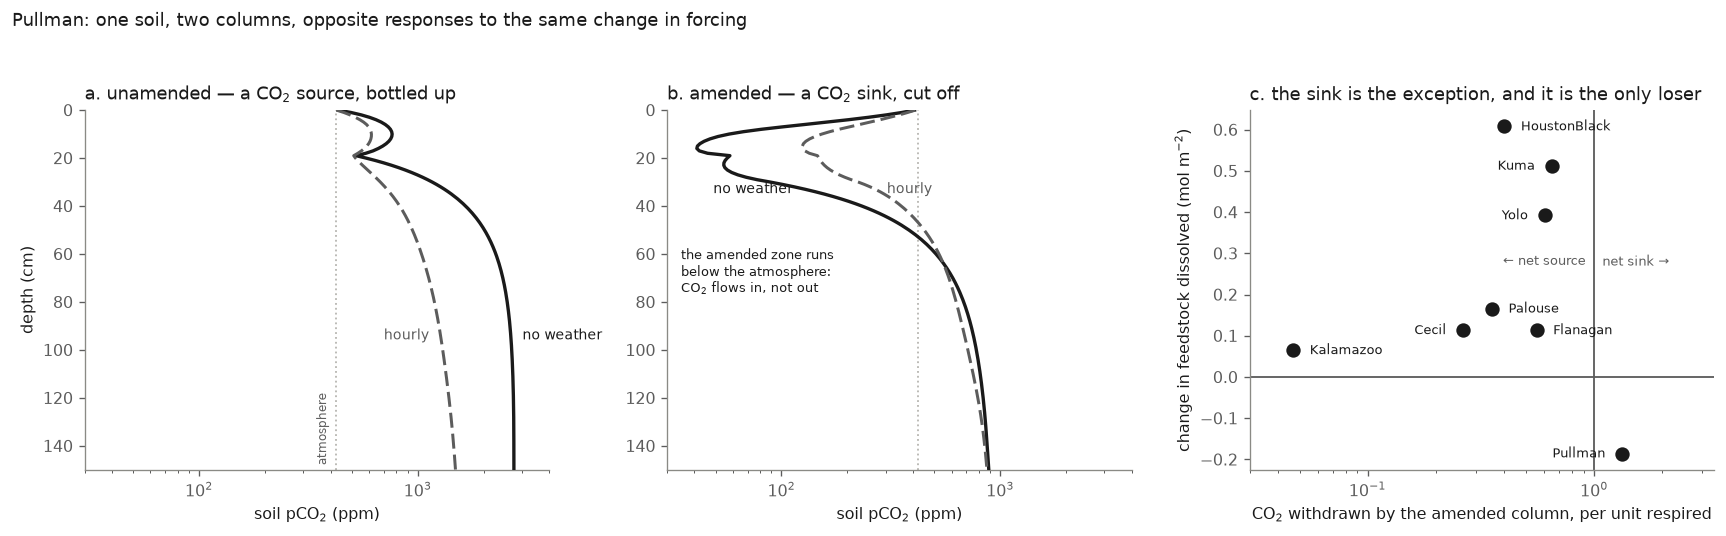

In [19]:
# The profiles come from the spatial snapshots, which resolve depth; the ratios quoted in the tables
# come from the `.gbg` monitors, which resolve time. They agree on every sign and to within a few
# percent on magnitude -- the monitors are simply the sharper instrument for a ten-year mean.
fig, axes = plt.subplots(1, 3, figsize=(14.4, 4.5))

for ax, treat, title in zip(axes[:2], ("ctrl", "erw"),
                            ("a. unamended — a CO$_2$ source, bottled up",
                             "b. amended — a CO$_2$ sink, cut off")):
    for case in CASES:
        d, v = profile_mean(PULL, case, treat, "gsg", "co2(g)")
        m = d <= 150
        ax.plot(v[m][::-1] * 1e6, d[m][::-1], **STYLE[case], zorder=3)
    label_pair(ax, {c: (lambda dv: (dv[0][dv[0] <= 150][::-1], dv[1][dv[0] <= 150][::-1] * 1e6))(
        profile_mean(PULL, c, treat, "gsg", "co2(g)")) for c in CASES})
    ax.axvline(ATM_PCO2 * 1e6, color=RULE, lw=1.1, ls=":", zorder=2)
    ax.set_xscale("log")
    ax.set_xlim(30, 4000)
    ax.set_ylim(150, 0)
    ax.set_xlabel("soil pCO$_2$ (ppm)")
    ax.set_title(title, loc="left")
axes[0].set_ylabel("depth (cm)")
axes[0].annotate("atmosphere", (ATM_PCO2 * 1e6, 148), xytext=(-4, 0), textcoords="offset points",
                 rotation=90, ha="right", va="bottom", fontsize=7.4, color=MUTED)
axes[1].annotate("the amended zone runs\nbelow the atmosphere:\nCO$_2$ flows in, not out",
                 (0.03, 0.62), xycoords="axes fraction", fontsize=8.0, color=INK, va="top")

# --- (c) the threshold, across all eight sites -----------------------------------------------
# Two rules, not a regression: the mechanism predicts that a column withdrawing more CO2 than it
# respires reverses the sign of its response, and that is a partition of the plane rather than a
# slope through it. Identity is carried by the labels, so no hue is spent.
ax = axes[2]
x = LEDGER8["withdrawn / respired"].to_numpy()
y = LEDGER8["change in forsterite"].to_numpy()
ax.axhline(0, color=MUTED, lw=1.1, zorder=2)
ax.axvline(1.0, color=MUTED, lw=1.1, zorder=2)
ax.scatter(x, y, s=58, color=INK, zorder=4)
NUDGE8 = {"Pullman": (-10, 0), "Kuma": (-10, 0), "Yolo": (-10, 0), "Flanagan": (10, 0),
          "HoustonBlack": (10, 0), "Palouse": (10, 0), "Cecil": (-10, 0), "Kalamazoo": (10, 0)}
for site, xi, yi in zip(LEDGER8.index, x, y):
    dx, dy = NUDGE8.get(site, (10, 0))
    ax.annotate(site, (xi, yi), xytext=(dx, dy), textcoords="offset points", fontsize=8.0,
                color=INK, va="center", ha="right" if dx < 0 else "left", zorder=5)
ax.set_xscale("log")
ax.set_xlim(0.03, 3.4)
ax.set_xlabel("CO$_2$ withdrawn by the amended column, per unit respired")
ax.set_ylabel(f"change in feedstock dissolved (mol m$^{{-2}}$)")
ax.set_title("c. the sink is the exception, and it is the only loser", loc="left")
MID = 0.28          # an empty band between the Yolo and Palouse rows
ax.annotate("net sink →", (1.0, MID), xytext=(5, 0), textcoords="offset points",
            fontsize=7.6, color=MUTED, ha="left", va="center")
ax.annotate("← net source", (1.0, MID), xytext=(-5, 0), textcoords="offset points",
            fontsize=7.6, color=MUTED, ha="right", va="center")

fig.suptitle(f"{PULL}: one soil, two columns, opposite responses to the same change in forcing",
             x=0.005, ha="left", fontsize=11)
plt.tight_layout(rect=(0, 0, 1, 0.94))
if SAVE:
    fig.savefig(Path("figures") / f"cdr_metforcing_pullman_{PLANE}.png", dpi=300, bbox_inches="tight")

### 8b. A slow start, or an exhausted one?

There is a competing story for the same result, and it is a natural one. Removing the weather leaves
the *unamended* profile more acid, as §7 showed — so perhaps the coarse forcing lets the feedstock
dissolve **faster** at first, and simply runs the zone's CO$_2$ down sooner, ending behind after ten
years having started ahead. That would be an exhaustion effect, and it would mean the ten-year total
is hiding a crossover.

It is testable, because §7's snapshot reconstruction gives the dissolution rate interval by interval.
The two runs also start from a shared spun-up initial condition, so any difference is made during the
run and not inherited.

The two runs start from the same spun-up profile, so nothing below is inherited:
  no weather  t=0, 0-30 cm: pH 7.3387, pCO2 736.9 ppm
  hourly      t=0, 0-30 cm: pH 7.3387, pCO2 736.9 ppm

Forsterite dissolved above 100 cm, mol/m2/d, and the ratio of the two runs


,"rate, no weather","rate, hourly",rate ratio,cumulative ratio
year 1,0.00137,0.00144,0.94650,0.94650
year 2,0.00099,0.00104,0.95323,0.94932
year 3,0.00085,0.00091,0.93781,0.94625
year 4,0.00079,0.00082,0.95933,0.94879
year 5,0.00076,0.00083,0.91490,0.94319
year 6,0.00075,0.00080,0.94425,0.94333
year 7,0.00074,0.00080,0.92725,0.94140
year 8,0.00072,0.00077,0.93403,0.94063
year 9,0.00070,0.00073,0.95938,0.94268
year 10,0.00067,0.00071,0.94933,0.94242


The no weather run never leads: the largest value of (coarse - hourly) over the whole run is
+0.0000 mol/m2, and the deficit is already -0.0077 at the first snapshot. There is no crossover to hide.


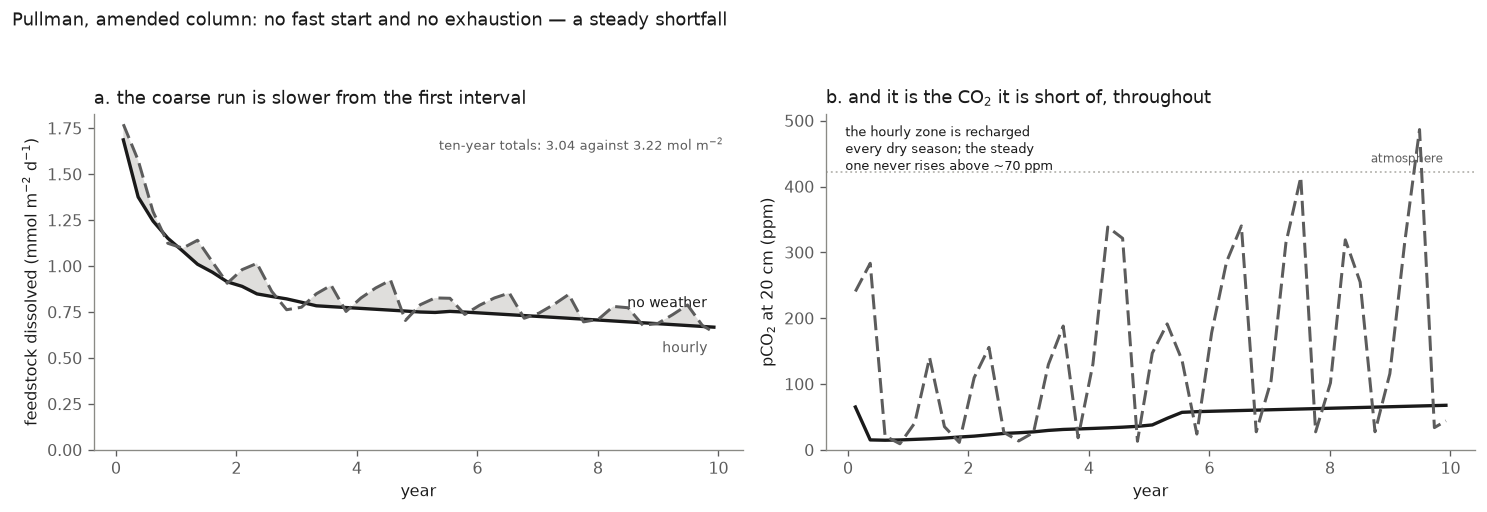

In [20]:
T8 = snapshot_times(PULL, REFERENCE, "erw")
YRS = 0.5 * (T8[:-1] + T8[1:]) / 365.25

FEED, PCO2 = {}, {}
for case in CASES:
    depth, inv = mineral_snapshots(PULL, case, "erw", "forst-ph")
    above = inv[:, depth <= PLANE].sum(axis=1)
    FEED[case] = (above[0] - above, -np.diff(above) / np.diff(T8))     # cumulative, and rate
    cols, arr = monitor(RAW / PULL / f"{case}_erw", case, "gbg", 20)   # the driver, at full resolution
    t, c = arr[:, cols.index("time")], arr[:, cols.index("co2(g)")]
    w = np.diff(t, prepend=t[0])
    PCO2[case] = np.array([weighted(c[(t > lo) & (t <= hi)], w[(t > lo) & (t <= hi)])
                           for lo, hi in zip(T8[:-1], T8[1:])])

start = {c: (profile_mean(PULL, c, "erw", "gsm", "pH"), profile_mean(PULL, c, "erw", "gsg", "co2(g)"))
         for c in CASES}
print("The two runs start from the same spun-up profile, so nothing below is inherited:")
for case in CASES:
    names, first, _ = snapshots(PULL, case, "erw", "gsm")
    d, _ = depth_and_dz(first)
    gnames, gfirst, _ = snapshots(PULL, case, "erw", "gsg")
    b = d < 30
    print(f"  {LABEL[case]:11s} t=0, 0-30 cm: pH {first[b, names.index('pH')].mean():.4f}, "
          f"pCO2 {1e6 * gfirst[b, gnames.index('co2(g)')].mean():.1f} ppm")

yr = np.clip((YRS).astype(int), 0, 9)
rate = pd.DataFrame({
    f"rate, {LABEL[COARSE]}": [FEED[COARSE][1][yr == y].mean() for y in range(10)],
    f"rate, {LABEL[REFERENCE]}": [FEED[REFERENCE][1][yr == y].mean() for y in range(10)]},
    index=[f"year {y + 1}" for y in range(10)])
rate["rate ratio"] = rate.iloc[:, 0] / rate.iloc[:, 1]
rate["cumulative ratio"] = [FEED[COARSE][0][YRS.searchsorted(y + 1)] /
                            FEED[REFERENCE][0][YRS.searchsorted(y + 1)] for y in range(10)]
print(f"\nForsterite dissolved above {PLANE} cm, mol/m2/d, and the ratio of the two runs")
display(rate.round(5))
lead = FEED[COARSE][0] - FEED[REFERENCE][0]
print(f"The {LABEL[COARSE]} run never leads: the largest value of (coarse - hourly) over the whole "
      f"run is\n{lead.max():+.4f} mol/m2, and the deficit is already {lead[1]:+.4f} at the first "
      f"snapshot. There is no crossover to hide.")

fig, axes = plt.subplots(1, 2, figsize=(12.4, 4.3), sharex=True)
ax = axes[0]
# The two rates track each other closely, so the persistent gap is easier to see filled than read
# off two lines. It is shaded wherever the hourly run is ahead, which is almost everywhere.
ax.fill_between(YRS, FEED[COARSE][1] * 1000, FEED[REFERENCE][1] * 1000,
                where=FEED[REFERENCE][1] > FEED[COARSE][1], color=RULE, alpha=0.45,
                interpolate=True, lw=0, zorder=2)
for case in CASES:
    ax.plot(YRS, FEED[case][1] * 1000, **STYLE[case], zorder=3)
    ax.annotate(LABEL[case], (YRS[-1], FEED[case][1][-1] * 1000), xytext=(-4, 12 if case == COARSE else -12),
                textcoords="offset points", ha="right", fontsize=8.2,
                color=INK if case == COARSE else MUTED)
ax.set_ylim(0, None)
ax.set_ylabel("feedstock dissolved (mmol m$^{-2}$ d$^{-1}$)")
ax.set_xlabel("year")
ax.set_title("a. the coarse run is slower from the first interval", loc="left")
ax.annotate(f"ten-year totals: {FEED[COARSE][0][-1]:.2f} against "
            f"{FEED[REFERENCE][0][-1]:.2f} mol m$^{{-2}}$",
            (0.97, 0.93), xycoords="axes fraction", ha="right", va="top", fontsize=8.0, color=MUTED)

ax = axes[1]
for case in CASES:
    ax.plot(YRS, PCO2[case] * 1e6, **STYLE[case], zorder=3)
ax.axhline(ATM_PCO2 * 1e6, color=RULE, lw=1.1, ls=":", zorder=2)
ax.annotate("atmosphere", (YRS[-1], ATM_PCO2 * 1e6), xytext=(-2, 4), textcoords="offset points",
            ha="right", va="bottom", fontsize=7.4, color=MUTED)
ax.set_ylim(0, None)
ax.set_ylabel("pCO$_2$ at 20 cm (ppm)")
ax.set_xlabel("year")
ax.set_title("b. and it is the CO$_2$ it is short of, throughout", loc="left")
ax.annotate("the hourly zone is recharged\nevery dry season; the steady\none never rises above ~70 ppm",
            (0.03, 0.97), xycoords="axes fraction", fontsize=8.0, color=INK, va="top")

fig.suptitle(f"{PULL}, amended column: no fast start and no exhaustion — a steady shortfall",
             x=0.005, ha="left", fontsize=11)
plt.tight_layout(rect=(0, 0, 1, 0.93))
if SAVE:
    fig.savefig(Path("figures") / f"cdr_metforcing_pullman_rate_{PLANE}.png", dpi=300,
                bbox_inches="tight")

The competing story does not survive. The coarse run is slower in the very first ninety-day interval
and slower in every year after it, by four to eight percent, with no trend in the gap and no year in
which it leads. The cumulative ratio is pinned between 0.941 and 0.949 for the whole run. **There is
no fast start and no exhaustion: there is a steady shortfall of acid, visible from the beginning.**

Both runs *do* exhaust in the ordinary sense — the rate falls by about 60% over ten years in each, and
the amended zone's pCO$_2$ collapses from 737 ppm to under 150 within the first year in both. That
collapse is the amendment doing its job, and it is common to the two forcings. What the forcing
changes is how deep the collapse goes, and it goes deeper without the weather.

### 8c. The other two terms

Neither needs a new mechanism. The carbonate term is §7's ceiling test and the aluminium term is §6's
aluminate test, both applied to the **control** leg, which at Pullman is where they live.

In [21]:
PULL_IF = {(c, tr): interface(PULL, c, tr, PLANE) for c in CASES for tr in ("ctrl", "erw")}


def carried_at_plane(case, treat, ext, col):
    """One more upstream-weighted quantity at the plane, for the two `interface` does not return."""
    folder = RAW / PULL / f"{case}_{treat}"
    pcols, p_up = monitor(folder, case, "gbp", PLANE)
    _, p_dn = monitor(folder, case, "gbp", PLANE + 1)
    cols, up_ = monitor(folder, case, ext, PLANE)
    _, dn_ = monitor(folder, case, ext, PLANE + 1)
    upstream = p_up[:, pcols.index("h_w")] > p_dn[:, pcols.index("h_w")]
    return np.where(upstream, up_[1:, cols.index(col)], dn_[1:, cols.index(col)])


def drain_weight(case, treat):
    d = PULL_IF[(case, treat)]
    return np.clip(d["q"], 0, None) * d["dt"]


# --- the carbonate term: which leg, and does the ceiling explain it? -------------------------
carb = {}
for treat in ("ctrl", "erw"):
    row = {}
    for case in CASES:
        d = PULL_IF[(case, treat)]
        row[LABEL[case]] = {
            "calcite dissolved (mol/m2)": TERMS.loc[(PULL, case, treat), CARBON_MINERAL],
            "drainage (m)": float(np.sum(d["q"] * d["dt"])),
            "flux-weighted pCO2 (ppm)": 1e6 * weighted(d["pco2"], drain_weight(case, treat))}
    carb[treat] = pd.DataFrame(row)
    carb[treat].loc["per m3 of drainage"] = (carb[treat].loc["calcite dissolved (mol/m2)"]
                                             / carb[treat].loc["drainage (m)"])
print(f"{PULL}: the carbonate term, leg by leg (negative calcite = precipitated)")
display(pd.concat({"unamended": carb["ctrl"], "amended": carb["erw"]}, axis=1).round(4))

d_ctrl = (TERMS.loc[(PULL, COARSE, "ctrl"), CARBON_MINERAL]
          - TERMS.loc[(PULL, REFERENCE, "ctrl"), CARBON_MINERAL])
d_erw = (TERMS.loc[(PULL, COARSE, "erw"), CARBON_MINERAL]
         - TERMS.loc[(PULL, REFERENCE, "erw"), CARBON_MINERAL])
print(f"control leg {d_ctrl:+.3f} mol/m2, amended leg {d_erw:+.3f}, so the ladder step is "
      f"({d_erw:+.3f} - {d_ctrl:+.3f}) x {EQ_TO_T_CO2_HA:.4f} = {(d_erw - d_ctrl) * EQ_TO_T_CO2_HA:+.3f} "
      f"t CO2/ha,\nagainst the ladder's {DIFF.loc[PULL, 'soil carbonate']:+.3f}. The control leg "
      f"carries {abs(d_ctrl) / (abs(d_ctrl) + abs(d_erw)):.0%} of it.")

a = carb["ctrl"].loc["per m3 of drainage", LABEL[COARSE]]
b = carb["ctrl"].loc["per m3 of drainage", LABEL[REFERENCE]]
p = carb["ctrl"].loc["flux-weighted pCO2 (ppm)", LABEL[COARSE]]
q = carb["ctrl"].loc["flux-weighted pCO2 (ppm)", LABEL[REFERENCE]]
print(f"\nSection 7's ceiling test on the control: {a:.4f} against {b:.4f} mol/m3, a ratio of "
      f"{a / b:.3f},\nwhere pCO2 rises by {p / q:.3f} and the open-system ceiling predicts "
      f"{(p / q) ** (1 / 3):.3f} -- agreement to "
      f"{100 * abs((a / b) / (p / q) ** (1 / 3) - 1):.1f}%.")

# --- the aluminium term: section 6's test, on each leg ---------------------------------------
alu = {}
for treat in ("erw", "ctrl"):
    row = {}
    for case in CASES:
        f = drain_weight(case, treat)
        al = carried_at_plane(case, treat, "gbt", "al+3")
        I = carried_at_plane(case, treat, "gbm", "ionic strength")
        a3, D = free_al(al, PULL_IF[(case, treat)]["pH"], I)
        row[LABEL[case]] = {"pH": weighted(PULL_IF[(case, treat)]["pH"], f),
                            "total dissolved Al": weighted(al, f),
                            "free Al(3+)": weighted(a3, f),
                            "speciation factor": weighted(D, f)}
    alu[treat] = pd.DataFrame(row)
    alu[treat]["ratio"] = alu[treat][LABEL[COARSE]] / alu[treat][LABEL[REFERENCE]]
print(f"\n{PULL}: section 6's aluminate test, run on each leg separately")
display(pd.concat({"amended": alu["erw"], "unamended": alu["ctrl"]}, axis=1).map(lambda v: f"{v:.4g}"))
for treat, name in (("erw", "amended"), ("ctrl", "unamended")):
    dpH = alu[treat].loc["pH", LABEL[COARSE]] - alu[treat].loc["pH", LABEL[REFERENCE]]
    print(f"  {name:10s}: dpH {dpH:+.4f}, so 4 dpH = {4 * dpH:+.3f} in log10, against a measured "
          f"{np.log10(alu[treat].loc['speciation factor', 'ratio']):+.3f}")

Pullman: the carbonate term, leg by leg (negative calcite = precipitated)


unamended               amended          
                           no weather     hourly no weather    hourly
calcite dissolved (mol/m2)     3.8264     3.2324    -2.9248   -3.1407
drainage (m)                   4.3441     4.6134     4.3441    4.6155
flux-weighted pCO2 (ppm)    2690.9579  1422.2268   753.3647  767.0248
per m3 of drainage             0.8808     0.7007    -0.6733   -0.6805

control leg +0.594 mol/m2, amended leg +0.216, so the ladder step is (+0.216 - +0.594) x 0.4401 = -0.166 t CO2/ha,
against the ladder's -0.166. The control leg carries 73% of it.

Section 7's ceiling test on the control: 0.8808 against 0.7007 mol/m3, a ratio of 1.257,
where pCO2 rises by 1.892 and the open-system ceiling predicts 1.237 -- agreement to 1.6%.



Pullman: section 6's aluminate test, run on each leg separately


amended                     unamended                   
                   no weather     hourly   ratio no weather     hourly   ratio
pH                      7.973      7.992  0.9976      7.641      7.815  0.9777
total dissolved Al  2.003e-05  2.163e-05  0.9261  1.066e-05  3.222e-05  0.3309
free Al(3+)         1.437e-14  5.716e-15   2.513  7.796e-14  5.618e-14   1.388
speciation factor   3.643e+09  8.278e+09  0.4401  1.367e+08  8.534e+08  0.1602

  amended   : dpH -0.0194, so 4 dpH = -0.077 in log10, against a measured -0.356
  unamended : dpH -0.1743, so 4 dpH = -0.697 in log10, against a measured -0.795


The carbonate term is a **control-leg** effect: the unamended profile gives up 0.59 mol/m² more
calcite under the coarser forcing while the amended one precipitates 0.22 mol/m² less, and the ladder
subtracts them. The larger half is §7's ceiling test, unchanged — the control's drainage-weighted
pCO$_2$ nearly doubles, calcite per cubic metre of drainage follows it to the one-third power, and the
prediction lands within a couple of percent. The smaller half is §7's exchange chain running backwards:
less feedstock dissolved means less magnesium on the exchanger, less calcium displaced off it, and
less calcium to precipitate.

The aluminium term is a **control-leg** effect too, and running §6's test on each leg separately is
what shows it. On the amended leg the aluminate scaling misses badly — which is exactly how Pullman
appeared as the one point off the 1:1 line in §6's figure, because that figure was built on the
amended leg. On the unamended leg it works: the control's pH falls by 0.17 under the coarser forcing,
and the speciation factor falls by very nearly $10^{4\Delta\mathrm{pH}}$. **Pullman was never an
exception to §6; §6 was reading the wrong column.**

### What Pullman is for

It is the one site in this batch where the amendment is large enough, relative to what the soil
respires, to reverse the sign of the profile's CO$_2$ exchange — and once that sign flips, every
consequence of a coarsened forcing flips with it. That makes it a useful boundary case rather than an
awkward outlier:

* **The direction of the met-forcing bias is not a property of the forcing.** Coarsening the weather
  always wets the profile and always throttles the gas phase. Whether that helps or hurts depends on
  which way the CO$_2$ is moving, which depends on application rate against soil respiration — a
  design variable, not a climate one.
* **The ratio in §8a's third column is the thing to watch.** Every site here sits below one except
  Pullman, and Pullman is the only site that loses. A field trial at a high application rate on a
  low-respiration soil is a trial in Pullman's regime, and a model averaging its weather would
  overestimate its removal, not underestimate it — the opposite of the error it makes everywhere else.
* **Two of Pullman's three terms are its control column behaving normally.** Only `never dissolved` is
  genuinely anomalous. That is worth remembering before treating a site like this as evidence that the
  mechanism is different: most of the difference is the reference doing what references do.

**Caveats.** The surface CO$_2$ flux is a reconstruction, not a MIN3P output — Fick's law with the
model's own Millington coefficient across a 5 cm gradient — so its absolute value is soft even though
its sign and its ratio between two runs are not. And the `dissolved Al` term at Pullman is a small
number built from small numbers: the aluminium fluxes here are twenty times smaller than at Palouse,
and the term is the closing residual of the alkalinity balance, so §9's caveat applies to it with
particular force.

## 9. Summary

**The question.** `MetForcingResolution100cmFront.ipynb` showed that coarsening the met forcing
raises ten-year CDR at seven of eight sites and lowers it at Pullman, and traced the mechanism to
soil pCO₂ and the carbonate front. It could not say how much each process contributed.

**The answer, as an exact attribution.** ΔCDR decomposes into the same eight named terms as the CDR
ladder, minus the ceiling, which cancels. Three terms carry it:

| driver | sign | where it dominates | size |
|---|---|---|---|
| more feedstock dissolves | **+** at 7 of 8 | HoustonBlack, Kuma, Yolo | up to +1.07 |
| more control carbonate dissolves | **−** at all 5 carbonate sites | Yolo, HoustonBlack | up to −0.68 |
| less aluminium escapes | **+** at the acid sites | Palouse, Cecil | up to +0.39 |

with a fourth that matters at exactly one site: **gibbsite, +0.98 at Flanagan**, which is that
site's whole story.

**Where the two big terms come from.** §6 and §7 take the aluminium and carbonate terms apart, and
they turn out to be one physical cause with two chemical exits. Coarsening the forcing leaves the
profile wetter, less able to vent, and richer in respired CO₂; that extra CO₂ either holds the pH
down and strands aluminium on the exchanger (§6), or raises the calcium a saturated carbonate front
can carry and, through the feedstock's own magnesium, decides whether that front dissolves or
precipitates (§7). §7c also disposes of the episodic objection: storms arrive with more dissolution
capacity and a lower CO₂ ceiling, and the ceiling binds.

**Two things this adds.** First, the aluminium term — nothing in the sibling notebook's ERW/CTRL
split could see it, it is the largest driver at two sites, and §6 traces it to its cause: the coarser
forcing leaves the profile *more* acid, not less, and dissolved aluminium at this pH is aluminate,
which goes as the fourth power of 1/[H⁺]. Second, the routes: HoustonBlack and
Flanagan end within 0.03 t CO₂/ha of each other and share no mechanism, and Yolo's small net gain is
a near-cancellation of two terms three times its size. **Reporting only ΔCDR hides which process a
model has to get right.**

**Scale.** ΔCDR spans −0.63 to +0.51 t CO₂/ha against absolute CDRs of 0.28–4.85 — between 7% and
73% of a site's own hourly value, and almost no change in the ranking of soils (only Yolo and Pullman
swap).

**Caveats.** All of `CdrDecomposition.ipynb` §7 applies unchanged, since this is the same ladder run
twice. Two are worth repeating here:

1. **The aluminium term is the closing residual** of the alkalinity balance, so it also carries the
   budget's numerical error — bounded by the unamended controls at 0.32 t CO₂/ha at this plane. The
   `dissolved Al` differences quoted above (+0.39, +0.32, +0.28) are of that order, so they are the
   least certain entries in the table. They are supported by the direct aluminium mass balance in
   `CdrDecomposition.ipynb` §3, not by the residual alone, but a reader should treat their third
   decimal as decorative.
2. **One plane, one pair of forcings, ten years, one application.** `PLANE`, `REFERENCE` and
   `COARSE` at the top of §0 move all of it; the identity closes to machine precision at all four
   planes and all four forcings.